In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

##  Primeiramente foi necessario fazer a converção dos dados que emtava. em formato xlsx para o formato csv para que fosse possivel trabalhar com os dados

In [ ]:

df = pd.read_excel("taxas_rend/tx_rend_brasil_regioes_ufs_2023.xlsx", sheet_name=0, engine='openpyxl',skiprows=3)
df.columns = df.iloc[0]
df.columns = df.columns.astype(str)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df[1:].reset_index(drop=True)  
df.fillna(method="ffill", inplace=True)
df.to_csv("tx_rend_2023.csv", index=False, encoding="utf-8")


C:\Users\valderez\AppData\Local\Temp\ipykernel_41628\285695147.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


## apos os arquivos serem convertidos foi realizada a filtragem do valores desejados

In [ ]:

df = pd.read_csv('tx_rend_2008.csv')


df_filtrado = df[(df['Localização'] == 'Total') & (df['Dependência Administrativa'] == 'Total')]


df_resultado = df_filtrado[['Unidade Geográfica', 'Total_Abandono_EF2008', 'Total_Abandono_EM2008']]


df_resultado.columns = ['Estado', 'Taxa_Abandono_EF2008', 'Taxa_Abandono_EM2008']
df_resultado.to_csv('taxas_abandono_por_estado2008.csv', index=False, encoding='utf-8-sig')

df_municipios = pd.read_csv('alunos_matriculados/matriculas_fundamental_medio_2008.csv') 

df_estados = df_municipios.groupby('NO_UF', as_index=False).agg({
    'Total_Fundamental': 'sum',
    'Total_Medio': 'sum'
})

df_estados['Total_Geral'] = df_estados['Total_Fundamental'] + df_estados['Total_Medio']

df_estados.to_csv('matriculas_por_estado2008.csv', index=False, encoding='utf-8-sig')

print("Arquivo 'matriculas_por_estado.csv' criado com sucesso!")
print("\nExemplo das primeiras linhas:")
print(df_estados.head())

#--------------------
# Carregar os arquivos
df_matriculas = pd.read_csv('matriculas_por_estado2008.csv')  #
df_taxas = pd.read_csv('taxas_abandono_por_estado2008.csv')   

df_taxas = df_taxas.rename(columns={'Estado': 'NO_UF'})

df_final = pd.merge(df_matriculas, df_taxas, on='NO_UF', how='left')

df_final['Abandono_EF'] = (df_final['Total_Fundamental'] * df_final['Taxa_Abandono_EF2008']) / 100
df_final['Abandono_EM'] = (df_final['Total_Medio'] * df_final['Taxa_Abandono_EM2008']) / 100

# Arredondar para números inteiros e tratar valores faltantes
df_final['Abandono_EF'] = df_final['Abandono_EF'].round().fillna(0).astype(int)
df_final['Abandono_EM'] = df_final['Abandono_EM'].round().fillna(0).astype(int)

df_final['Total_Abandonos'] = df_final['Abandono_EF'] + df_final['Abandono_EM']

df_final = df_final.rename(columns={'NO_UF': 'Estado'})

df_final.to_csv('abandono_escolar_por_estado2008.csv', index=False, encoding='utf-8-sig')

print("\nArquivo 'abandono_escolar_por_estado.csv' gerado com sucesso!")
print("\nResumo estatístico:")
print(df_final[['Abandono_EF', 'Abandono_EM', 'Total_Abandonos']].describe())
print("\n5 primeiros registros:")
print(df_final.head())

Arquivo 'matriculas_por_estado.csv' criado com sucesso!

Exemplo das primeiras linhas:
      NO_UF  Total_Fundamental  Total_Medio  Total_Geral
0      Acre           164364.0      33113.0     197477.0
1   Alagoas           660805.0     128937.0     789742.0
2     Amapá           142182.0      35733.0     177915.0
3  Amazonas           796224.0     159656.0     955880.0
4     Bahia          2622197.0     650127.0    3272324.0

Arquivo 'abandono_escolar_por_estado.csv' gerado com sucesso!

Resumo estatístico:
       Abandono_EF  Abandono_EM  Total_Abandonos
count         27.0         27.0             27.0
mean           0.0          0.0              0.0
std            0.0          0.0              0.0
min            0.0          0.0              0.0
25%            0.0          0.0              0.0
50%            0.0          0.0              0.0
75%            0.0          0.0              0.0
max            0.0          0.0              0.0

5 primeiros registros:
     Estado  Total_Fun

 ### Nesse etapa fio feito o calculo do valor total dos abandonos com base nas taxas de abandono e da quantodade total de alunos

In [ ]:
df_matriculas = pd.read_csv('matriculas_por_estado2010.csv')  
df_taxas = pd.read_csv('taxas_abandono_por_estado2010.csv')   


df_taxas = df_taxas.rename(columns={'Estado': 'NO_UF'})


df_final = pd.merge(df_matriculas, df_taxas, on='NO_UF', how='left')


df_final['Abandono_EF'] = (df_final['Total_Fundamental'] * df_final['Taxa_Abandono_EF2010']) / 100
df_final['Abandono_EM'] = (df_final['Total_Medio'] * df_final['Taxa_Abandono_EM2010']) / 100


df_final['Abandono_EF'] = df_final['Abandono_EF'].round().fillna(0).astype(int)
df_final['Abandono_EM'] = df_final['Abandono_EM'].round().fillna(0).astype(int)

df_final['Total_Abandonos'] = df_final['Abandono_EF'] + df_final['Abandono_EM']

df_final = df_final.rename(columns={'NO_UF': 'Estado'})

df_final.to_csv('abandono_escolar_por_estado2010.csv', index=False, encoding='utf-8-sig')

print("\nArquivo 'abandono_escolar_por_estado.csv' gerado com sucesso!")
print("\nResumo estatístico:")
print(df_final[['Abandono_EF', 'Abandono_EM', 'Total_Abandonos']].describe())
print("\n5 primeiros registros:")
print(df_final.head())


Arquivo 'abandono_escolar_por_estado.csv' gerado com sucesso!

Resumo estatístico:
        Abandono_EF    Abandono_EM  Total_Abandonos
count     27.000000      27.000000        27.000000
mean   19874.851852   38765.333333     58640.185185
std    21529.108240   32203.625603     50129.249166
min     1099.000000    1514.000000      2613.000000
25%     4485.500000   12649.500000     17669.000000
50%    13949.000000   32148.000000     50595.000000
75%    27131.500000   55263.000000     83467.000000
max    80850.000000  114268.000000    195118.000000

5 primeiros registros:
     Estado  Total_Fundamental  Total_Medio  Total_Geral  \
0      Acre           166200.0      36295.0     202495.0   
1   Alagoas           630889.0     130247.0     761136.0   
2     Amapá           144597.0      37871.0     182468.0   
3  Amazonas           771963.0     162113.0     934076.0   
4     Bahia          2450008.0     589012.0    3039020.0   

   Taxa_Abandono_EF2010  Taxa_Abandono_EM2010  Abandono_EF  Aba

tratamento dos alores das variaveis para que tenham apenas 2 casas decimais

In [ ]:
#"https://aplicacoes.mds.gov.br/sagi/servicos/misocial?fq=anomes_s:2015*&fq=tipo_s:mes_mu&indent=on&q=*:*&wt=json&rows=10000000&sort=codigo_ibge%20asc,%20anomes_s%20asc&fl=ibge:codigo_ibge,siglauf:sigla_uf,anomes:anomes_s,qtd_ben_bas:tot_ben_bas_i,qtd_ben_var:tot_ben_bas_var_i,qtd_ben_bvj:tot_ben_bvj_i,qtd_ben_bvn:tot_ben_bvn_i,qtd_ben_bvg:tot_ben_bvg_i,qtd_ben_bsp:tot_ben_bsp_i"
bfml = pd.read_csv("matriculas_por_municipio_2015.csv")
bfml

In [ ]:
# Configurações iniciais
caminho_entrada = 'microdados_ed_basica_2023.csv'
caminho_saida = 'matriculas_detalhadas_2023.csv'
colunas_selecionadas = [
    'CO_MUNICIPIO', 
    'NO_UF', 
    'NO_MUNICIPIO',
    'TP_LOCALIZACAO',
    'TP_DEPENDENCIA', 
    'QT_MAT_FUND',  
    'QT_MAT_MED',  
    'QT_MAT_EJA'     
]

chunks = []
for chunk in pd.read_csv(
    caminho_entrada, 
    sep=';', 
    encoding='latin-1', 
    chunksize=100000,
    usecols=colunas_selecionadas
):

    chunk = chunk.dropna(subset=['QT_MAT_FUND', 'QT_MAT_MED'])  
    chunk['Tipo_Rede'] = chunk['TP_DEPENDENCIA'].apply(lambda x: 'Pública' if x in [1, 2, 3] else 'Privada')
    chunk['Localizacao'] = chunk['TP_LOCALIZACAO'].map({1: 'Urbana', 2: 'Rural'})
    chunks.append(chunk)

df_final = pd.concat(chunks, axis=0)
resultado = df_final.groupby(
    ['CO_MUNICIPIO', 'NO_UF', 'NO_MUNICIPIO', 'Tipo_Rede', 'Localizacao']
).agg({
    'QT_MAT_FUND': 'sum',
    'QT_MAT_MED': 'sum',
    'QT_MAT_EJA': 'sum'  
}).unstack(['Tipo_Rede', 'Localizacao']).fillna(0)

resultado.columns = ['_'.join(col).strip() for col in resultado.columns.values]
resultado = resultado.reset_index()


for loc in ['Urbana', 'Rural']:
    resultado[f'Total_{loc}'] = resultado[
        [f'QT_MAT_FUND_Pública_{loc}', f'QT_MAT_FUND_Privada_{loc}',
         f'QT_MAT_MED_Pública_{loc}', f'QT_MAT_MED_Privada_{loc}']
    ].sum(axis=1)

# Calcular totais por etapa de ensino
resultado['Total_Fundamental'] = resultado.filter(like='QT_MAT_FUND').sum(axis=1)
resultado['Total_Medio'] = resultado.filter(like='QT_MAT_MED').sum(axis=1)

# Salvar
resultado.to_csv(caminho_saida, index=False, encoding='utf-8-sig')

In [ ]:
df = pd.read_csv('matriculas_por_municipio_2015.csv')

df['Tipo_Rede'] = df['TP_DEPENDENCIA'].apply(lambda x: 'Pública' if x in [1, 2, 3] else 'Privada')
df['Localizacao'] = df['TP_LOCALIZACAO'].map({1: 'Urbana', 2: 'Rural'})

resultado = df.groupby(
    ['CO_MUNICIPIO', 'NO_UF', 'NO_MUNICIPIO', 'Tipo_Rede', 'Localizacao']
).agg({
    'QT_MAT_BAS': 'sum',
    'QT_MAT_INF': 'sum',
    'QT_MAT_MED': 'sum',
    'QT_MAT_EJA': 'sum'
}).unstack(['Tipo_Rede', 'Localizacao']).fillna(0)

resultado.columns = ['_'.join(col).strip() for col in resultado.columns.values]
resultado = resultado.reset_index()

for loc in ['Urbana', 'Rural']:
    resultado[f'Total_{loc}'] = resultado.filter(like=loc).sum(axis=1)

# Salvar
resultado.to_csv('matriculas_detalhadas_2015.csv', index=False, encoding='utf-8-sig')

In [ ]:
caminho_entrada = "dados_limpos2015.csv"  
caminho_saida = 'dados_limpor2015B.csv'
colunas_selecionadas = [
    'Ano',
    'Região',
    'UF',
    'Código do Município',
    'Nome do Município',
    'Localização',
    'Rede',
    'Total Abandono Ens. Fundamental',
    'Total Abandono no Ens. Médio'
]

# Tamanho do chunk (ajuste conforme sua RAM)
# Exemplo: 100.000 linhas por chunk (reduza se ainda houver lentidão)
chunksize = 100000  

# Lista para armazenar os chunks processados
chunks_processados = []

# Ler o arquivo em chunks
for chunk in pd.read_csv(
    caminho_entrada, 
    sep=';', 
    encoding='latin-1', 
    chunksize=chunksize,
    usecols=colunas_selecionadas  # Lê apenas as colunas necessárias
):
    # Filtre ou processe o chunk aqui (se necessário)
    chunks_processados.append(chunk)

# Concatenar todos os chunks em um único DataFrame
df_final = pd.concat(chunks_processados, axis=0)

# Salvar o resultado em um novo CSV
df_final.to_csv(caminho_saida, index=False, encoding='utf-8-sig')

print(f"Arquivo '{caminho_saida}' gerado com sucesso!")

### Convertendo dados do bolsa família em csv

### baixando os dados do bolsa familias e convertendo para o formato CSV

In [ ]:


url = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/?fq=anomes_s:2023*&fl=codigo_ibge%2Canomes_s%2Cqtd_familias_beneficiarias_bolsa_familia_s%2Cvalor_repassado_bolsa_familia_s%2Cpbf_vlr_medio_benef_f&fq=valor_repassado_bolsa_familia_s%3A*&q=*%3A*&rows=100000&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"

dados_bf = pd.read_csv(url, encoding='latin1', sep=';')

dados_bf.to_csv('valorRepassado_familia_2023.csv', index=False, encoding='utf-8-sig')

print("Arquivo salvo com sucesso!")

dados = pd.read_csv('valorRepassado_familia_2023.csv', sep=';', encoding='latin1')

dados = dados.replace({'"': ''}, regex=True)

dados.to_csv('valorRepassado_familia_2023.csv', index=False, sep=';', encoding='utf-8-sig')

print("Arquivo corrigido salvo sem aspas!")


Arquivo salvo com sucesso!
Arquivo corrigido salvo sem aspas!


In [ ]:
uf_map = {
    11: {'sigla': 'RO', 'nome': 'Rondônia'},
    12: {'sigla': 'AC', 'nome': 'Acre'},
    13: {'sigla': 'AM', 'nome': 'Amazonas'},
    14: {'sigla': 'RR', 'nome': 'Roraima'},
    15: {'sigla': 'PA', 'nome': 'Pará'},
    16: {'sigla': 'AP', 'nome': 'Amapá'},
    17: {'sigla': 'TO', 'nome': 'Tocantins'},
    21: {'sigla': 'MA', 'nome': 'Maranhão'},
    22: {'sigla': 'PI', 'nome': 'Piauí'},
    23: {'sigla': 'CE', 'nome': 'Ceará'},
    24: {'sigla': 'RN', 'nome': 'Rio Grande do Norte'},
    25: {'sigla': 'PB', 'nome': 'Paraíba'},
    26: {'sigla': 'PE', 'nome': 'Pernambuco'},
    27: {'sigla': 'AL', 'nome': 'Alagoas'},
    28: {'sigla': 'SE', 'nome': 'Sergipe'},
    29: {'sigla': 'BA', 'nome': 'Bahia'},
    31: {'sigla': 'MG', 'nome': 'Minas Gerais'},
    32: {'sigla': 'ES', 'nome': 'Espírito Santo'},
    33: {'sigla': 'RJ', 'nome': 'Rio de Janeiro'},
    35: {'sigla': 'SP', 'nome': 'São Paulo'},
    41: {'sigla': 'PR', 'nome': 'Paraná'},
    42: {'sigla': 'SC', 'nome': 'Santa Catarina'},
    43: {'sigla': 'RS', 'nome': 'Rio Grande do Sul'},
    50: {'sigla': 'MS', 'nome': 'Mato Grosso do Sul'},
    51: {'sigla': 'MT', 'nome': 'Mato Grosso'},
    52: {'sigla': 'GO', 'nome': 'Goiás'},
    53: {'sigla': 'DF', 'nome': 'Distrito Federal'}
}

ano = 2021 

df = pd.read_csv("valorRepassado_familia_2021.csv")  

df['cod_uf'] = df['ibge'].astype(str).str[:2].astype(int)

df['uf_sigla'] = df['cod_uf'].map(lambda x: uf_map[x]['sigla'])
df['uf_nome'] = df['cod_uf'].map(lambda x: uf_map[x]['nome'])

df_estado = df.groupby(['uf_sigla', 'uf_nome']).agg({
    'valor_repassado_bolsa_familia': 'sum',
    'qtd_familias_beneficiarias_bolsa_familia': 'sum'
}).reset_index()

df_estado['valor_medio_bf'] = df_estado['valor_repassado_bolsa_familia'] / df_estado['qtd_familias_beneficiarias_bolsa_familia']
df_estado['ano'] = ano  

df_estado = df_estado.sort_values('uf_sigla')

resultado = df_estado[['ano', 'uf_sigla', 'uf_nome', 'qtd_familias_beneficiarias_bolsa_familia', 'valor_repassado_bolsa_familia', 'valor_medio_bf']]

nome_arquivo_saida = f'bolsa_familia_por_estado_{ano}.csv'
resultado.to_csv(nome_arquivo_saida, index=False, float_format='%.2f')

print(f"Arquivo salvo: {nome_arquivo_saida}")
print(resultado.head())

Arquivo salvo: bolsa_familia_por_estado_2021.csv
    ano uf_sigla   uf_nome  qtd_familias_beneficiarias_bolsa_familia  \
0  2021       AC      Acre                                  907936.0   
1  2021       AL   Alagoas                                 4132720.0   
2  2021       AM  Amazonas                                 4059479.0   
3  2021       AP     Amapá                                  758406.0   
4  2021       BA     Bahia                                18580643.0   

   valor_repassado_bolsa_familia  valor_medio_bf  
0                   1.844038e+08      203.102209  
1                   4.780583e+08      115.676420  
2                   6.279694e+08      154.692105  
3                   1.102775e+08      145.407009  
4                   2.060550e+09      110.897653  


### adicionar a coluna contendo a sigla de cada estado para facilitar a manipulação posterior dos dados, converte os dados para que os valores de quantidade de familias e o valor medio da bolsa familia sejam agrupados por estados

In [ ]:
df = pd.read_csv('bolsa_familia_por_estado_2021.csv')  


if 'valor_medio_bf' in df.columns:

    df['valor_medio_bf_ajustado'] = (df['valor_medio_bf'] * 1.02985750).round(2)
    

    df.to_csv('bolsa_familia_por_estado_2021.csv', index=False, float_format='%.2f')
    
    print("Ajuste realizado com sucesso! Resultado com 2 casas decimais:")
    print(df[['uf_sigla', 'valor_medio_bf', 'valor_medio_bf_ajustado']].head())
else:
    print("Erro: Coluna 'valor_medio_bf' não encontrada.")
    print("Colunas disponíveis:", list(df.columns))

Ajuste realizado com sucesso! Resultado com 2 casas decimais:
  uf_sigla  valor_medio_bf  valor_medio_bf_ajustado
0       AC          203.10                   209.16
1       AL          115.68                   119.13
2       AM          154.69                   159.31
3       AP          145.41                   149.75
4       BA          110.90                   114.21


raliza o tratamento de dados dos dados relacionados ao desemprenho escolar 

In [ ]:
df2016 = pd.read_csv("rendimento_escolar/Dados Tratados/dadosTratados2020.csv")
print(df2016.columns.tolist())

#### filtragem as colunas do total Rural E Urbano

In [ ]:
df2023 = pd.read_csv("rendimento_escolar/Dados Tratados/dadosTratados2023.csv")
matriculas_df = pd.read_csv("alunos_matriculados/matriculas_fundamental_medio_2023.csv")

colunas_selecionadas = [
    'Ano', 'Região', 'UF', 'Código do Município', 'Nome do Município',
    'Localização', 'Rede', 'Total_Abandono_EF2023', 'Total_Abandono_EM2023'
]

dados_tratados_df = df2023[
    (df2023['Localização'] == 'Total') & 
    (df2023['Rede'] == 'Total')
][colunas_selecionadas].copy()

matriculas_df['CO_MUNICIPIO'] = matriculas_df['CO_MUNICIPIO'].astype(str).str.zfill(6)
dados_tratados_df['Código do Município'] = dados_tratados_df['Código do Município'].astype(str).str.zfill(6)

merged_df = pd.merge(
    matriculas_df,
    dados_tratados_df,
    left_on='CO_MUNICIPIO',
    right_on='Código do Município',
    how='left'
)

cols_numericas = ['Total_Fundamental', 'Total_Medio', 'Total_Abandono_EF2023', 'Total_Abandono_EM2023']
merged_df[cols_numericas] = merged_df[cols_numericas].apply(pd.to_numeric, errors='coerce')

merged_df['Abandono_Abs_EF'] = (merged_df['Total_Fundamental'] * merged_df['Total_Abandono_EF2023'] / 100).fillna(0)
merged_df['Abandono_Abs_EM'] = (merged_df['Total_Medio'] * merged_df['Total_Abandono_EM2023'] / 100).fillna(0)

agrupado_por_uf = merged_df.groupby('UF').agg({
    'Total_Fundamental': 'sum',
    'Total_Medio': 'sum',
    'Abandono_Abs_EF': 'sum',
    'Abandono_Abs_EM': 'sum',
    'Total_Abandono_EF2023': 'mean',
    'Total_Abandono_EM2023': 'mean'
}).reset_index()

agrupado_por_uf.to_csv("Estados2023_robusto.csv", sep=",", index=False)


#### Mescla os dois dataframes para incluir as colunas Total_Rural e Total_Urbano da planilha matriculas_detalhadas

In [ ]:

matriculas_df.columns = matriculas_df.columns.str.strip()
dados_tratados_df.columns = dados_tratados_df.columns.str.strip()

matriculas_df['CO_MUNICIPIO'] = matriculas_df['CO_MUNICIPIO'].astype(str)
dados_tratados_df['Código do Município'] = dados_tratados_df['Código do Município'].astype(str)


merged_df = pd.merge(matriculas_df, dados_tratados_df, left_on='CO_MUNICIPIO', right_on='Código do Município', how='outer')
merged_df[['Ano','CO_MUNICIPIO','Nome do Município','Localização','Total_Fundamental','Total_Medio', 'Total_Abandono_EF2008', 'Total_Abandono_EM2008']]


## Realiza a a tratamento de dados por meio da miltiplicalçao de alunos matriculados pela taxa de abandono para obter o numero total de abandono tanto no encino fundamental quanto no encino medio e depois inclui esses valores no dataframe orifinal

In [ ]:

print(merged_df[['Total_Fundamental','Total_Medio', 'Total_Abandono_EF2008', 'Total_Abandono_EM2008']].dtypes)

merged_df['Total_Fundamental'] = pd.to_numeric(merged_df['Total_Fundamental'], errors='coerce')
merged_df['Total_Medio'] = pd.to_numeric(merged_df['Total_Medio'], errors='coerce')
merged_df['Total_Abandono_EF2008'] = pd.to_numeric(merged_df['Total_Abandono_EF2008'], errors='coerce')
merged_df['Total_Abandono_EM2008'] = pd.to_numeric(merged_df['Total_Abandono_EM2008'], errors='coerce')

merged_df['Total_Abandono_EM2008'] = merged_df['Total_Abandono_EM2008'].fillna(0)
merged_df['Total_Abandono_EF2008'] = merged_df['Total_Abandono_EF2008'].fillna(0)

merged_df['Resultado_Multiplicacao_EF2008'] = ((merged_df['Total_Fundamental'] * merged_df['Total_Abandono_EF2008'])/100).astype(int)

merged_df['Resultado_Multiplicacao_EM2008'] = ((merged_df['Total_Medio'] * merged_df['Total_Abandono_EM2008'])/100).astype(int)

print(merged_df[['CO_MUNICIPIO', 'Nome do Município','Total_Fundamental','Total_Medio', 'Total_Abandono_EF2008', 'Total_Abandono_EM2008', 'Resultado_Multiplicacao_EF2008','Resultado_Multiplicacao_EM2008']].head())


In [ ]:
merged_df[['CO_MUNICIPIO','UF', 'Nome do Município','Localização', 'Total_Fundamental','Total_Medio', 'Total_Abandono_EF2008', 'Total_Abandono_EM2008', 'Resultado_Multiplicacao_EF2008','Resultado_Multiplicacao_EM2008']]

#### Filtra os dados importantes, esse processo é repetido por cada ano 

In [ ]:
acress_df = merged_df[['UF', 'Resultado_Multiplicacao_EF2008', 'Resultado_Multiplicacao_EM2008']]
agrupado_por_uf = acress_df.groupby('UF', as_index=False).sum()
agrupado_por_uf

#### salva em um novo arquivo

In [ ]:
agrupado_por_uf.to_csv("Estados2008.csv", sep=",", index=False)

### Mesclar todos os dados do abandono escolar em apenas um dataframe 

In [ ]:
ano2023 = pd.read_csv("total_abandono_alunos_estados/abandono_escolar_por_estado2023.csv")

### recorta as colunas que são importantes

In [ ]:
novo2023= ano2023[['Estado','Abandono_EF','Abandono_EM']]

### mescla os dados em um dataframe unico

In [ ]:
merged_df = pd.merge(dados, novo2023, left_on='Estado', right_on='Estado', how='outer')

### salva esse dataframe que contem os dados de todos os anos como um novo arquivo

In [ ]:
totalTotal.to_csv("totais por ano.csv", sep=",", index=False)

### filtra as colunas que são importantes e as renomeia

In [ ]:
novobolsa2023= bolsa2023[['uf_nome','valor_medio_estadual','qtd_familias_beneficiarias_bolsa_familia_ajustado']]
novobolsa2023.rename(columns={'uf_nome':'Estado'}, inplace=True)

### salva em um dataframe os dados de todos os anos

In [ ]:
merged_df1 = pd.merge(dados1, novobolsa2023, left_on='Estado', right_on='Estado', how='outer')

In [ ]:
totalTotal= merged_df1

### salva esse dataframe como sendo um arquivo

In [ ]:
totalTotal.to_csv("totais por ano.csv", sep=",", index=False)

### para tornar a analise mais Robusta foram uncluidas novas variaveis que vieram de dados como o IDHM de educação, IDHM de renda, Indice de Atkison de renda e de educação, e o indice de gini, os valores iniciais passaram pelo processo de calculo da media e os resultados foram salvos em novos arquivis

In [ ]:

df = pd.read_csv('idhm_consolidado.csv')

soma_educ = df.filter(like='IDHM Renda').sum(axis=1).round(2)
df['Media_IDHM_Renda'] = soma_educ / 10 
df_resultado = df[['Estado', 'UF', 'Media_IDHM_Renda']].sort_values('Media_IDHM_Renda', ascending=False)

df_resultado.to_csv('idhm_consolidado.csv', index=False, encoding='utf-8-sig', float_format='%.3f')

In [ ]:

df = pd.read_csv('idhm_consolidado.csv')

soma_educ = df.filter(like='IDHM Educação ').sum(axis=1).round(2)
df['Media_IDHM_Educacao'] = soma_educ / 10 
df_resultado = df[['Estado', 'UF', 'Media_IDHM_Educacao']].sort_values('Media_IDHM_Educacao', ascending=False)

df_resultado.to_csv('idhm_consolidado.csv', index=False, encoding='utf-8-sig', float_format='%.3f')



In [ ]:

df = pd.read_csv('idhm_consolidado.csv')

soma_educ = df.filter(like='Indici de Atkison - Educação').sum(axis=1).round(2)
df['Media_Indice_Atkison_Educacao'] = soma_educ / 10  
df_resultado = df[['Estado', 'UF', 'Media_Indice_Atkison_Educacao']].sort_values('Media_Indice_Atkison_Educacao', ascending=False)

df_resultado.to_csv('idhm_consolidadoAtkinson.csv', index=False, encoding='utf-8-sig', float_format='%.3f')

In [ ]:

df = pd.read_csv('idhm_consolidado.csv')

soma_educ = df.filter(like='Indici de Atkison - Renda').sum(axis=1).round(2)
df['Media_Indice_Atkison_Renda'] = soma_educ / 10 
df_resultado = df[['Estado', 'UF', 'Media_Indice_Atkison_Renda']].sort_values('Media_Indice_Atkison_Renda', ascending=False)

df_resultado.to_csv('idhm_consolidadoAtkinson', index=False, encoding='utf-8-sig', float_format='%.3f')

In [ ]:

df = pd.read_csv('idhm_Indice_de_gini.csv')

soma_educ = df.filter(like='Media_Indice_Gini').sum(axis=1).round(2)
df['Media_Indice_Gini'] = soma_educ / 10 
df_resultado = df[['Estado', 'UF', 'Media_Indice_Gini']].sort_values('Media_Indice_Gini', ascending=False)

df_resultado.to_csv('idhm_gini_estado.csv', index=False, encoding='utf-8-sig', float_format='%.3f')

In [ ]:
f = pd.read_csv('idhm_Renda Percapta.csv')

soma_educ = df.filter(like='Media_Renda_Percapta').sum(axis=1).round(2)
df['Media_Renda_Percapta'] = soma_educ / 10 
df_resultado = df[['Estado', 'UF', 'Media_Renda_Percapta']].sort_values('Media_Renda_Percapta', ascending=False)

df_resultado.to_csv('idhm_renda_per_capita.csv', index=False, encoding='utf-8-sig', float_format='%.3f')

tambem foram incluidas variaveis de taca de Desocupação, nivel de Ocupação e taxa de participação, para essas variaveis foi realizado um processo de tratamento para filtrar os dados importante

In [ ]:
taxas = pd.read_csv("INDICADORES_TABELA2.csv")

In [ ]:
df_segundo_trimestre = taxas[taxas['Trimestre'] == 2]
colunas_desejadas = ['UF', 'Ano', 'Trimestre', 'Taxa_Desocupacao', 'Nivel_Ocupacao', 'Taxa_Participacao']
df_filtrado = df_segundo_trimestre[colunas_desejadas]

df_filtrado = df_filtrado.reset_index(drop=True)

mapa_estados = {
    "Acre": "AC", "Alagoas": "AL", "Amapá": "AP", "Amazonas": "AM", "Bahia": "BA",
    "Ceará": "CE", "Espírito Santo": "ES", "Goiás": "GO", "Maranhão": "MA", "Mato Grosso": "MT",
    "Mato Grosso do Sul": "MS", "Minas Gerais": "MG", "Pará": "PA", "Paraíba": "PB", "Paraná": "PR",
    "Pernambuco": "PE", "Piauí": "PI", "Rio de Janeiro": "RJ", "Rio Grande do Norte": "RN", "Rio Grande do Sul": "RS",
    "Rondônia": "RO", "Roraima": "RR", "Santa Catarina": "SC", "São Paulo": "SP", "Sergipe": "SE",
    "Tocantins": "TO", "Distrito Federal": "DF"
}

df_filtrado['UF'] = df_filtrado['UF'].apply(lambda x: mapa_estados.get(x, x)) 

df_filtrado.to_csv("TaxasDeDesocupacaoOcupacaoParticipacao.csv",index=False)

## depois de tar trarados todos os dados iniciou-se a etapa de mesclar todos os dados um um unico arquivo e fazer os testes de correlação e depois disso a regressão linear

In [135]:
df = pd.read_csv("analise_robusta.csv")

In [ ]:

abandono_em = df.melt(
    id_vars=["UF"],  
    value_vars=[col for col in df.columns if "Abandono_EM" in col],
    var_name="Ano", 
    value_name="Abandono_EM" 
)

abandono_em["Ano"] = abandono_em["Ano"].str.extract(r'(\d{4})').astype(int)
valor_bf = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "valor_medio_bf_ajustado_" in col],
    var_name="Ano",
    value_name="Valor_medio_BF"
)
valor_bf["Ano"] = valor_bf["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(abandono_em, valor_bf, on=["UF", "Ano"])
print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF
0  AC  2007         5512          184.37
1  AL  2007        32874          175.03
2  AP  2007         8513          189.19
3  AM  2007        21077          189.42
4  BA  2007       161873          178.15


In [ ]:
Abando_ef = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Abandono_EF" in col],
    var_name="Ano",
    value_name="Abandono_EF"
)
Abando_ef["Ano"] = Abando_ef["Ano"].str.extract(r'(\d{4})').astype(int)



df_final = pd.merge(df_final, Abando_ef, on=["UF", "Ano"])
print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF
0  AC  2007         5512          184.37         4470
1  AL  2007        32874          175.03        48121
2  AP  2007         8513          189.19         6930
3  AM  2007        21077          189.42        51244
4  BA  2007       161873          178.15       185146


In [ ]:
IDHM_EDUCACAO = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Educação" in col],
    var_name="Ano",
    value_name="IDHM Educação"
)
IDHM_EDUCACAO ["Ano"] = IDHM_EDUCACAO["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final, IDHM_EDUCACAO, on=["UF", "Ano"])

print(df_final.head())



   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF  IDHM Educação
0  AC  2012         4006          361.93         5270          0.649
1  AL  2012        23988          294.55        44245          0.587
2  AP  2012         6925          343.57         5039          0.659
3  AM  2012        21056          338.33        42742          0.632
4  BA  2012        83059          285.55       127753          0.593


In [ ]:
IDHM_RENDA = df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "IDHM Renda" in col],
    var_name="Ano",
    value_name="IDHM Renda"
)
IDHM_RENDA["Ano"] = IDHM_RENDA["Ano"].str.extract(r'(\d{4})').astype(int)

df_final = pd.merge(df_final, IDHM_RENDA, on=["UF", "Ano"])

print(df_final.head())


   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF  IDHM Educação  \
0  AC  2012         4006          361.93         5270          0.649   
1  AL  2012        23988          294.55        44245          0.587   
2  AP  2012         6925          343.57         5039          0.659   
3  AM  2012        21056          338.33        42742          0.632   
4  BA  2012        83059          285.55       127753          0.593   

   IDHM Renda  
0       0.670  
1       0.627  
2       0.673  
3       0.683  
4       0.666  


In [ ]:
INDICE_ATKINSON= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Índice de Atkinson - Renda" in col],
    var_name="Ano",
    value_name="Índice de Atkinson Renda"
)
INDICE_ATKINSON["Ano"] = INDICE_ATKINSON["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final, INDICE_ATKINSON, on=["UF", "Ano"])
print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF  IDHM Educação  \
0  AC  2012         4006          361.93         5270          0.649   
1  AL  2012        23988          294.55        44245          0.587   
2  AP  2012         6925          343.57         5039          0.659   
3  AM  2012        21056          338.33        42742          0.632   
4  BA  2012        83059          285.55       127753          0.593   

   IDHM Renda  Índice de Atkinson Renda  
0       0.670                     0.422  
1       0.627                     0.352  
2       0.673                     0.361  
3       0.683                     0.417  
4       0.666                     0.405  


In [ ]:
INDICE_ATKINSON= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "Índice de Atkinson - Educação" in col],
    var_name="Ano",
    value_name="Índice de Atkinson Educacao"
)
INDICE_ATKINSON["Ano"] = INDICE_ATKINSON["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final, INDICE_ATKINSON, on=["UF", "Ano"])
print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF  IDHM Educação  \
0  AC  2012         4006          361.93         5270          0.649   
1  AL  2012        23988          294.55        44245          0.587   
2  AP  2012         6925          343.57         5039          0.659   
3  AM  2012        21056          338.33        42742          0.632   
4  BA  2012        83059          285.55       127753          0.593   

   IDHM Renda  Índice de Atkinson Renda  Índice de Atkinson Educacao  
0       0.670                     0.422                        0.281  
1       0.627                     0.352                        0.296  
2       0.673                     0.361                        0.184  
3       0.683                     0.417                        0.202  
4       0.666                     0.405                        0.275  


In [ ]:
QTD_FAMILIAS= df.melt(
    id_vars=["UF"],
    value_vars=[col for col in df.columns if "qtd_familias_beneficiarias_bolsa_familia_ajustado_" in col],
    var_name="Ano",
    value_name="QTD_FAMILIAS_BF"
)
QTD_FAMILIAS["Ano"] = QTD_FAMILIAS["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final,QTD_FAMILIAS, on=["UF", "Ano"])

print(df_final.head())

   UF   Ano  Abandono_EM  Valor_medio_BF  Abandono_EF  IDHM Educação  \
0  AC  2012         4006          361.93         5270          0.649   
1  AL  2012        23988          294.55        44245          0.587   
2  AP  2012         6925          343.57         5039          0.659   
3  AM  2012        21056          338.33        42742          0.632   
4  BA  2012        83059          285.55       127753          0.593   

   IDHM Renda  Índice de Atkinson Renda  Índice de Atkinson Educacao  \
0       0.670                     0.422                        0.281   
1       0.627                     0.352                        0.296   
2       0.673                     0.361                        0.184   
3       0.683                     0.417                        0.202   
4       0.666                     0.405                        0.275   

   QTD_FAMILIAS_BF  
0          67021.0  
1         429494.0  
2          52285.0  
3         323646.0  
4        1777116.0  


In [143]:
df_rendaPerCapta= pd.read_csv("dadosUsadosParaMerge/idhm_renda_per_capita.csv")

In [ ]:


PERCAPTA= df_rendaPerCapta.melt(
    id_vars=["UF"],
    value_vars=[col for col in df_rendaPerCapta.columns if "Renda per capita " in col],
    var_name="Ano",
    value_name="rendaPercapta"
)
PERCAPTA["Ano"] = PERCAPTA["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final,PERCAPTA, on=["UF", "Ano"])
df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,Abandono_EF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta
0,AC,2012,4006,361.93,5270,0.649,0.670,0.422,0.281,67021.0,516.75
1,AL,2012,23988,294.55,44245,0.587,0.627,0.352,0.296,429494.0,395.06
2,AP,2012,6925,343.57,5039,0.659,0.673,0.361,0.184,52285.0,528.23
3,AM,2012,21056,338.33,42742,0.632,0.683,0.417,0.202,323646.0,559.44
4,BA,2012,83059,285.55,127753,0.593,0.666,0.405,0.275,1777116.0,503.29


In [145]:
gini=pd.read_csv("dadosUsadosParaMerge/idhm_gini_estado.csv")

In [ ]:

IndiciDeGINI= gini.melt(
    id_vars=["UF"],
    value_vars=[col for col in gini.columns if "Índice de Gini " in col],
    var_name="Ano",
    value_name="IndiceDeGINI"
)
IndiciDeGINI["Ano"] = IndiciDeGINI["Ano"].str.extract(r'(\d{4})').astype(int)
df_final = pd.merge(df_final,IndiciDeGINI, on=["UF", "Ano"])
df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,Abandono_EF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI
0,AC,2012,4006,361.93,5270,0.649,0.670,0.422,0.281,67021.0,516.75,0.566
1,AL,2012,23988,294.55,44245,0.587,0.627,0.352,0.296,429494.0,395.06,0.503
2,AP,2012,6925,343.57,5039,0.659,0.673,0.361,0.184,52285.0,528.23,0.528
3,AM,2012,21056,338.33,42742,0.632,0.683,0.417,0.202,323646.0,559.44,0.589
4,BA,2012,83059,285.55,127753,0.593,0.666,0.405,0.275,1777116.0,503.29,0.563


In [147]:
taxas = pd.read_csv("TaxasDeDesocupacaoOcupacaoParticipacao.csv")

In [ ]:
TAXADESOCUPACAO = taxas[["UF","Ano","Taxa_Desocupacao"]]
df_final = pd.merge(df_final,TAXADESOCUPACAO, on=["UF", "Ano"])
df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,Abandono_EF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao
0,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3
1,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.1
2,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,7.7
3,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,8.1
4,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,10.9


In [ ]:
TAXADEOCUPACAO = taxas[["UF","Ano","Nivel_Ocupacao"]]
df_final = pd.merge(df_final,TAXADEOCUPACAO, on=["UF", "Ano"])
df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,Abandono_EF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao,Nivel_Ocupacao
0,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2
1,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,55.7
2,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,55.5
3,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,56.3
4,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,54.1


In [ ]:
TAXAPARTICIPACAO = taxas[["UF","Ano","Taxa_Participacao"]]
df_final = pd.merge(df_final,TAXAPARTICIPACAO, on=["UF", "Ano"])
df_final.head()

,UF,Ano,Abandono_EM,Valor_medio_BF,Abandono_EF,IDHM Educação,IDHM Renda,Índice de Atkinson Renda,Índice de Atkinson Educacao,QTD_FAMILIAS_BF,rendaPercapta,IndiceDeGINI,Taxa_Desocupacao,Nivel_Ocupacao,Taxa_Participacao
0,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,58.6
1,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,61.3
2,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,60.3
3,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,61.3
4,AC,2012,4006,361.93,5270,0.649,0.67,0.422,0.281,67021.0,516.75,0.566,9.3,53.2,60.8


## Tendo todos os dados salvos em apenas um arquivo foi realizada a etapa de reste de correlação

In [111]:
dados_df= pd.read_csv('analise_robustaFINAL.csv')

In [4]:
dados_df.head()

,Estado,UF,IDHM Educação 2012,IDHM Educação 2013,IDHM Educação 2014,IDHM Educação 2015,IDHM Educação 2016,IDHM Educação 2017,IDHM Educação 2018,IDHM Educação 2019,...,Taxa_Participacao_2018,Taxa_Desocupacao_2019,Nivel_Ocupacao_2019,Taxa_Participacao_2019,Taxa_Desocupacao_2020,Nivel_Ocupacao_2020,Taxa_Participacao_2020,Taxa_Desocupacao_2021,Nivel_Ocupacao_2021,Taxa_Participacao_2021
0,Acre,AC,0.649,0.658,0.679,0.679,0.704,0.671,0.706,0.728,...,57.0400,11.8800,50.3350,57.0400,11.8800,50.3350,57.0400,11.8800,50.3350,57.0400
1,Alagoas,AL,0.587,0.573,0.599,0.605,0.635,0.634,0.651,0.643,...,48.9775,14.3425,42.0150,48.9775,14.3425,42.0150,48.9775,14.3425,42.0150,48.9775
2,Amapá,AP,0.659,0.714,0.688,0.690,0.709,0.700,0.742,0.728,...,61.5825,14.9900,52.3675,61.5825,14.9900,52.3675,61.5825,14.9900,52.3675,61.5825
3,Amazonas,AM,0.632,0.659,0.667,0.686,0.705,0.732,0.717,0.735,...,62.5875,12.4975,54.7675,62.5875,12.4975,54.7675,62.5875,12.4975,54.7675,62.5875
4,Bahia,BA,0.593,0.594,0.619,0.640,0.656,0.655,0.660,0.672,...,60.3325,15.2650,51.2025,60.3325,15.2650,51.2025,60.3325,15.2650,51.2025,60.3325


In [5]:
print(dados_df.shape)

(27, 139)


In [6]:
dados_df.columns

Index(['Estado', 'UF', 'IDHM Educação 2012', 'IDHM Educação 2013',
       'IDHM Educação 2014', 'IDHM Educação 2015', 'IDHM Educação 2016',
       'IDHM Educação 2017', 'IDHM Educação 2018', 'IDHM Educação 2019',
       ...
       'Taxa_Participacao_2018', 'Taxa_Desocupacao_2019',
       'Nivel_Ocupacao_2019', 'Taxa_Participacao_2019',
       'Taxa_Desocupacao_2020', 'Nivel_Ocupacao_2020',
       'Taxa_Participacao_2020', 'Taxa_Desocupacao_2021',
       'Nivel_Ocupacao_2021', 'Taxa_Participacao_2021'],
      dtype='object', length=139)

In [7]:
(dados_df.describe()).astype(int)

,IDHM Educação 2012,IDHM Educação 2013,IDHM Educação 2014,IDHM Educação 2015,IDHM Educação 2016,IDHM Educação 2017,IDHM Educação 2018,IDHM Educação 2019,IDHM Educação 2020,IDHM Educação 2021,...,Taxa_Participacao_2018,Taxa_Desocupacao_2019,Nivel_Ocupacao_2019,Taxa_Participacao_2019,Taxa_Desocupacao_2020,Nivel_Ocupacao_2020,Taxa_Participacao_2020,Taxa_Desocupacao_2021,Nivel_Ocupacao_2021,Taxa_Participacao_2021
count,27,27,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
mean,0,0,0,0,0,0,0,0,0,0,...,60,10,54,60,10,54,60,10,54,60
std,0,0,0,0,0,0,0,0,0,0,...,4,2,5,4,2,5,4,2,5,4
min,0,0,0,0,0,0,0,0,0,0,...,48,5,42,48,5,42,48,5,42,48
25%,0,0,0,0,0,0,0,0,0,0,...,57,9,50,57,9,50,57,9,50,57
50%,0,0,0,0,0,0,0,0,0,0,...,61,10,54,61,10,54,61,10,54,61
75%,0,0,0,0,0,0,0,0,0,0,...,65,12,59,65,12,59,65,12,59,65
max,0,0,0,0,0,0,0,0,0,0,...,67,15,62,67,15,62,67,15,62,67


In [8]:
dados_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Columns: 139 entries, Estado to Taxa_Participacao_2021
dtypes: float64(112), int64(24), object(3)
memory usage: 29.4+ KB


## correlação dos valores de cada ano usando o abandono do Encino Fundamental

In [9]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2012': 'qtd_familias_2012'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2012': 'valor_medio_2012'})

dados_df[['Abandono_EF2012','valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','Índice de Atkinson - Educação 2012','Índice de Atkinson - Renda 2012','Taxa_Desocupacao_2012','Nivel_Ocupacao_2012','Taxa_Participacao_2012']].corr()

,Abandono_EF2012,valor_medio_2012,qtd_familias_2012,IDHM Educação 2012,Índice de Atkinson - Educação 2012,Índice de Atkinson - Renda 2012,Taxa_Desocupacao_2012,Nivel_Ocupacao_2012,Taxa_Participacao_2012
Abandono_EF2012,1.000000,-0.059134,0.885140,-0.407473,0.282819,0.257954,0.436906,-0.352931,-0.281787
valor_medio_2012,-0.059134,1.000000,-0.228185,-0.350410,0.342438,0.416201,0.314345,-0.349337,-0.318316
qtd_familias_2012,0.885140,-0.228185,1.000000,-0.197475,0.224720,0.175992,0.330697,-0.294177,-0.244950
IDHM Educação 2012,-0.407473,-0.350410,-0.197475,1.000000,-0.784678,-0.383218,-0.431021,0.696396,0.717837
Índice de Atkinson - Educação 2012,0.282819,0.342438,0.224720,-0.784678,1.000000,0.454531,0.431682,-0.784242,-0.827261
Índice de Atkinson - Renda 2012,0.257954,0.416201,0.175992,-0.383218,0.454531,1.000000,0.724128,-0.610180,-0.488183
Taxa_Desocupacao_2012,0.436906,0.314345,0.330697,-0.431021,0.431682,0.724128,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2012,-0.352931,-0.349337,-0.294177,0.696396,-0.784242,-0.610180,-0.774518,1.000000,0.970122
Taxa_Participacao_2012,-0.281787,-0.318316,-0.244950,0.717837,-0.827261,-0.488183,-0.598578,0.970122,1.000000


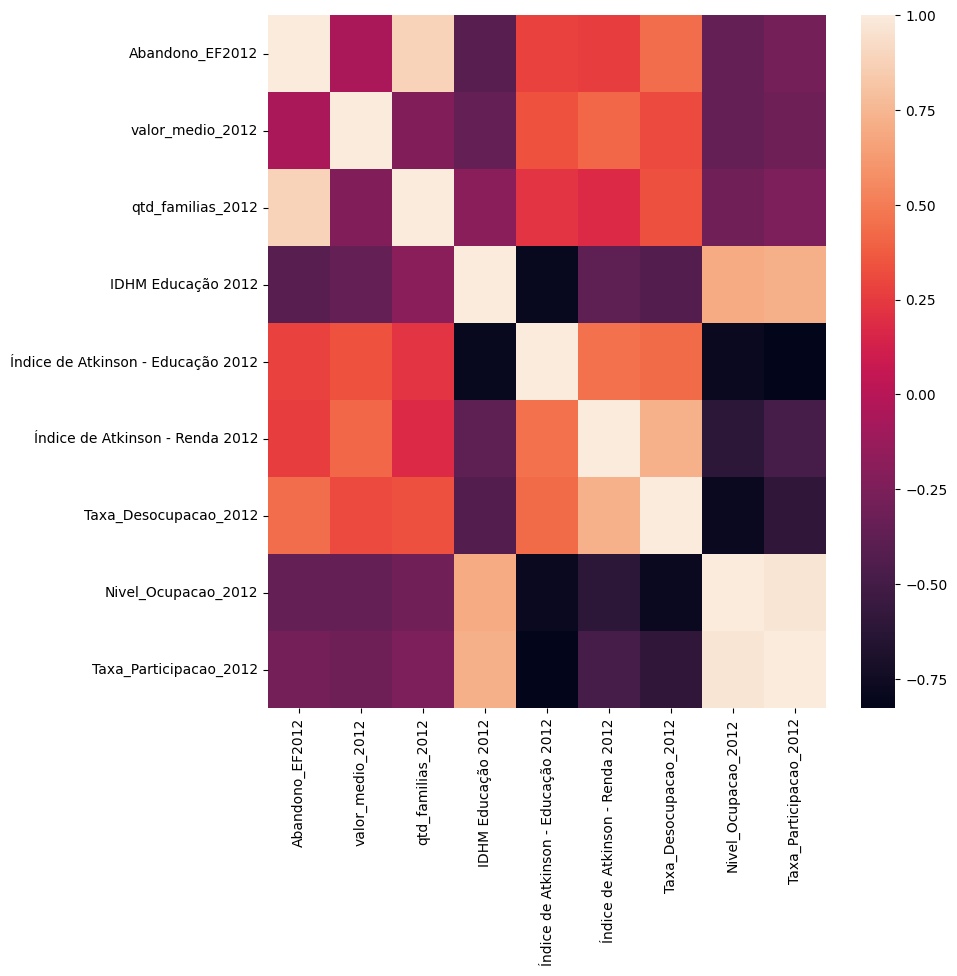

In [10]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2012','valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','Índice de Atkinson - Educação 2012','Índice de Atkinson - Renda 2012','Taxa_Desocupacao_2012','Nivel_Ocupacao_2012','Taxa_Participacao_2012']].corr())
plt.show()

In [11]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2013': 'qtd_familias_2013'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2013': 'valor_medio_2013'})

dados_df[['Abandono_EF2013','valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','Índice de Atkinson - Educação 2013','Índice de Atkinson - Renda 2013','Taxa_Desocupacao_2013','Nivel_Ocupacao_2013','Taxa_Participacao_2013']].corr()

,Abandono_EF2013,valor_medio_2013,qtd_familias_2013,IDHM Educação 2013,Índice de Atkinson - Educação 2013,Índice de Atkinson - Renda 2013,Taxa_Desocupacao_2013,Nivel_Ocupacao_2013,Taxa_Participacao_2013
Abandono_EF2013,1.000000,0.034833,0.882879,-0.394629,0.225352,0.265629,0.420470,-0.339327,-0.270006
valor_medio_2013,0.034833,1.000000,-0.125897,-0.397830,0.537714,0.448437,0.394445,-0.502167,-0.480068
qtd_familias_2013,0.882879,-0.125897,1.000000,-0.198644,0.179016,0.190475,0.332006,-0.289108,-0.237851
IDHM Educação 2013,-0.394629,-0.397830,-0.198644,1.000000,-0.795641,-0.429936,-0.386007,0.687579,0.723513
Índice de Atkinson - Educação 2013,0.225352,0.537714,0.179016,-0.795641,1.000000,0.522449,0.468906,-0.802325,-0.835582
Índice de Atkinson - Renda 2013,0.265629,0.448437,0.190475,-0.429936,0.522449,1.000000,0.779125,-0.689991,-0.569363
Taxa_Desocupacao_2013,0.420470,0.394445,0.332006,-0.386007,0.468906,0.779125,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2013,-0.339327,-0.502167,-0.289108,0.687579,-0.802325,-0.689991,-0.774518,1.000000,0.970122
Taxa_Participacao_2013,-0.270006,-0.480068,-0.237851,0.723513,-0.835582,-0.569363,-0.598578,0.970122,1.000000


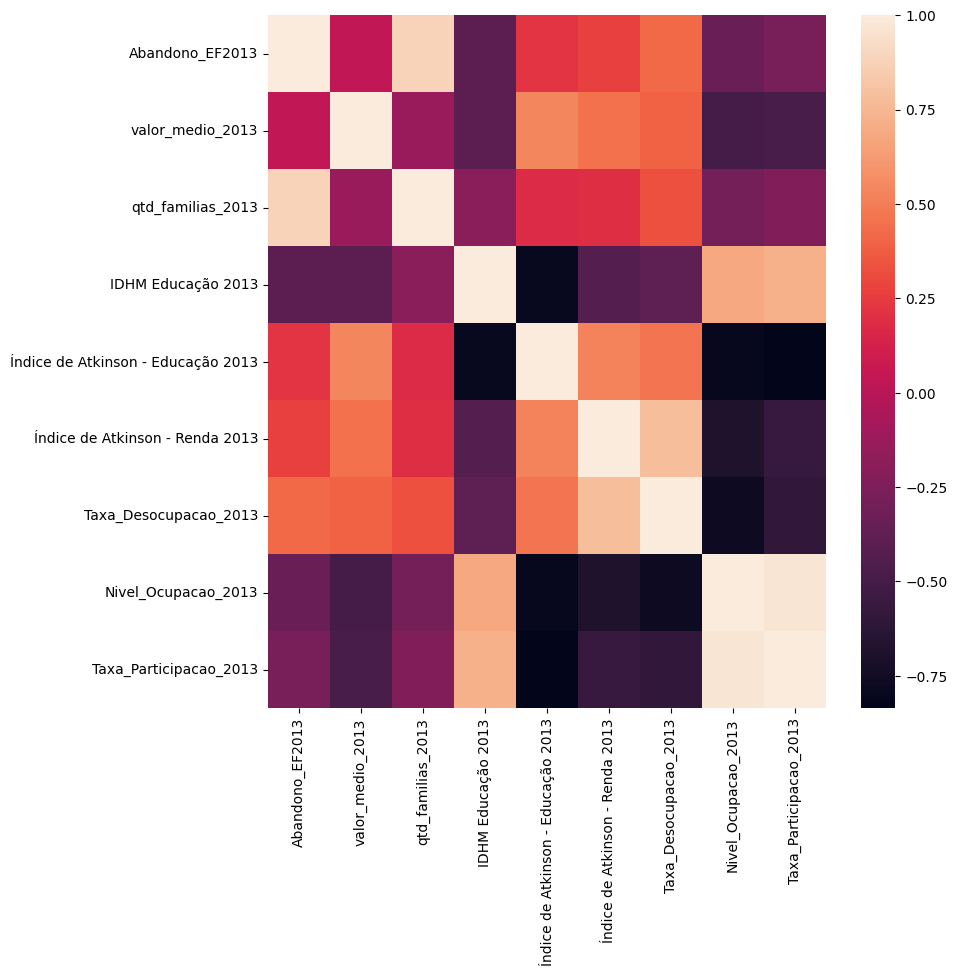

In [12]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2013','valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','Índice de Atkinson - Educação 2013','Índice de Atkinson - Renda 2013','Taxa_Desocupacao_2013','Nivel_Ocupacao_2013','Taxa_Participacao_2013']].corr())
plt.show()

In [13]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2014': 'qtd_familias_2014'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2014': 'valor_medio_2014'})

dados_df[['Abandono_EF2014','valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','Índice de Atkinson - Educação 2014','Índice de Atkinson - Renda 2014','Taxa_Desocupacao_2014','Nivel_Ocupacao_2014','Taxa_Participacao_2014']].corr()

,Abandono_EF2014,valor_medio_2014,qtd_familias_2014,IDHM Educação 2014,Índice de Atkinson - Educação 2014,Índice de Atkinson - Renda 2014,Taxa_Desocupacao_2014,Nivel_Ocupacao_2014,Taxa_Participacao_2014
Abandono_EF2014,1.000000,0.028893,0.891788,-0.340036,0.148462,0.214402,0.417782,-0.324194,-0.251327
valor_medio_2014,0.028893,1.000000,-0.108491,-0.390789,0.552078,0.460338,0.396711,-0.494133,-0.468858
qtd_familias_2014,0.891788,-0.108491,1.000000,-0.165808,0.114110,0.149112,0.338272,-0.296181,-0.244247
IDHM Educação 2014,-0.340036,-0.390789,-0.165808,1.000000,-0.770561,-0.392797,-0.397729,0.672791,0.701094
Índice de Atkinson - Educação 2014,0.148462,0.552078,0.114110,-0.770561,1.000000,0.514109,0.456621,-0.792274,-0.828171
Índice de Atkinson - Renda 2014,0.214402,0.460338,0.149112,-0.392797,0.514109,1.000000,0.831553,-0.717497,-0.586123
Taxa_Desocupacao_2014,0.417782,0.396711,0.338272,-0.397729,0.456621,0.831553,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2014,-0.324194,-0.494133,-0.296181,0.672791,-0.792274,-0.717497,-0.774518,1.000000,0.970122
Taxa_Participacao_2014,-0.251327,-0.468858,-0.244247,0.701094,-0.828171,-0.586123,-0.598578,0.970122,1.000000


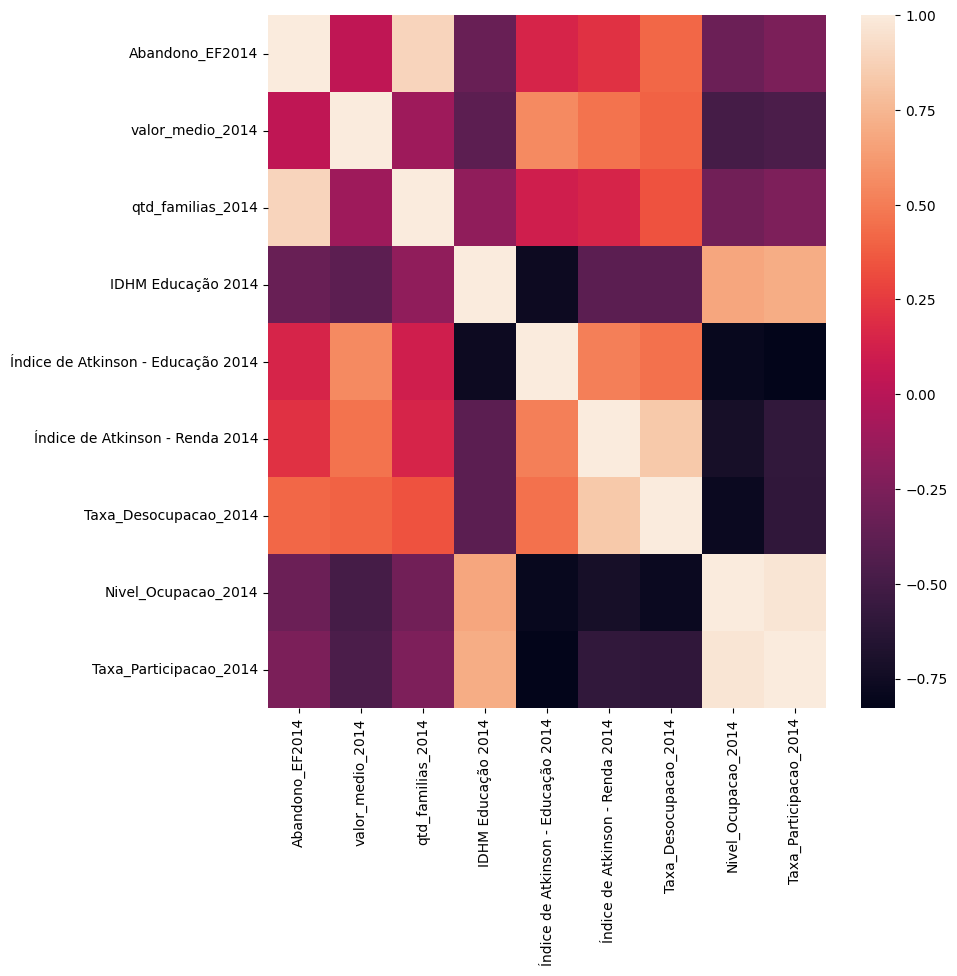

In [14]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2014','valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','Índice de Atkinson - Educação 2014','Índice de Atkinson - Renda 2014','Taxa_Desocupacao_2014','Nivel_Ocupacao_2014','Taxa_Participacao_2014']].corr())
plt.show()

In [15]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2015': 'qtd_familias_2015'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2015': 'valor_medio_2015'})

dados_df[['Abandono_EF2015','valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','Índice de Atkinson - Educação 2015','Índice de Atkinson - Renda 2015','Taxa_Desocupacao_2015','Nivel_Ocupacao_2015','Taxa_Participacao_2015']].corr()

,Abandono_EF2015,valor_medio_2015,qtd_familias_2015,IDHM Educação 2015,Índice de Atkinson - Educação 2015,Índice de Atkinson - Renda 2015,Taxa_Desocupacao_2015,Nivel_Ocupacao_2015,Taxa_Participacao_2015
Abandono_EF2015,1.000000,0.075634,0.861718,-0.333068,0.177113,0.230531,0.393671,-0.310894,-0.243516
valor_medio_2015,0.075634,1.000000,-0.071279,-0.429818,0.532161,0.621517,0.417694,-0.512187,-0.484071
qtd_familias_2015,0.861718,-0.071279,1.000000,-0.109309,0.130287,0.162570,0.346738,-0.286172,-0.228090
IDHM Educação 2015,-0.333068,-0.429818,-0.109309,1.000000,-0.803004,-0.446460,-0.421586,0.697390,0.723231
Índice de Atkinson - Educação 2015,0.177113,0.532161,0.130287,-0.803004,1.000000,0.556968,0.462234,-0.796048,-0.831263
Índice de Atkinson - Renda 2015,0.230531,0.621517,0.162570,-0.446460,0.556968,1.000000,0.849827,-0.758464,-0.629861
Taxa_Desocupacao_2015,0.393671,0.417694,0.346738,-0.421586,0.462234,0.849827,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2015,-0.310894,-0.512187,-0.286172,0.697390,-0.796048,-0.758464,-0.774518,1.000000,0.970122
Taxa_Participacao_2015,-0.243516,-0.484071,-0.228090,0.723231,-0.831263,-0.629861,-0.598578,0.970122,1.000000


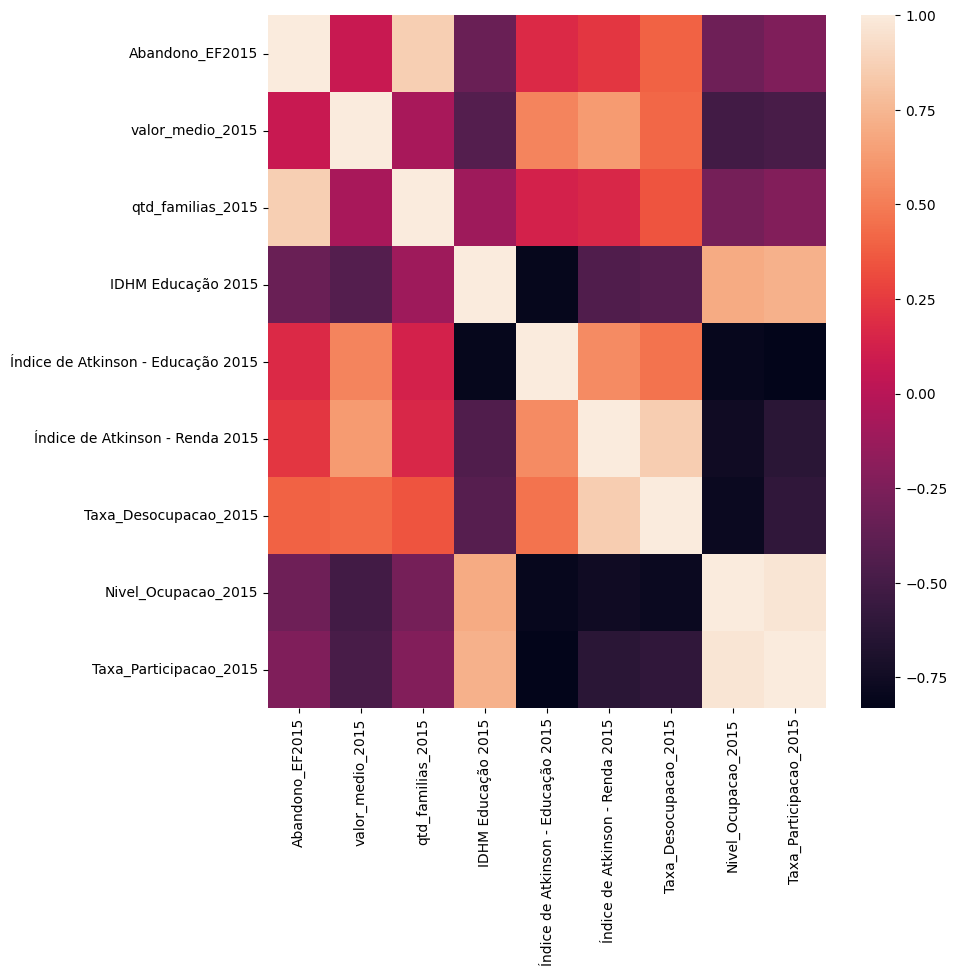

In [16]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2015','valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','Índice de Atkinson - Educação 2015','Índice de Atkinson - Renda 2015','Taxa_Desocupacao_2015','Nivel_Ocupacao_2015','Taxa_Participacao_2015']].corr())
plt.show()

In [17]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2016': 'qtd_familias_2016'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2016': 'valor_medio_2016'})

dados_df[['Abandono_EF2016','valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','Índice de Atkinson - Educação 2016','Índice de Atkinson - Renda 2016','Taxa_Desocupacao_2016','Nivel_Ocupacao_2016','Taxa_Participacao_2016']].corr()

,Abandono_EF2016,valor_medio_2016,qtd_familias_2016,IDHM Educação 2016,Índice de Atkinson - Educação 2016,Índice de Atkinson - Renda 2016,Taxa_Desocupacao_2016,Nivel_Ocupacao_2016,Taxa_Participacao_2016
Abandono_EF2016,1.000000,0.073727,0.877738,-0.324854,0.159887,0.213579,0.418552,-0.329406,-0.257067
valor_medio_2016,0.073727,1.000000,-0.071292,-0.407189,0.505397,0.556844,0.417668,-0.512163,-0.484050
qtd_familias_2016,0.877738,-0.071292,1.000000,-0.111705,0.104769,0.144609,0.346738,-0.286172,-0.228090
IDHM Educação 2016,-0.324854,-0.407189,-0.111705,1.000000,-0.717711,-0.455561,-0.420440,0.691387,0.715143
Índice de Atkinson - Educação 2016,0.159887,0.505397,0.104769,-0.717711,1.000000,0.489657,0.440423,-0.768335,-0.804330
Índice de Atkinson - Renda 2016,0.213579,0.556844,0.144609,-0.455561,0.489657,1.000000,0.890026,-0.737669,-0.589012
Taxa_Desocupacao_2016,0.418552,0.417668,0.346738,-0.420440,0.440423,0.890026,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2016,-0.329406,-0.512163,-0.286172,0.691387,-0.768335,-0.737669,-0.774518,1.000000,0.970122
Taxa_Participacao_2016,-0.257067,-0.484050,-0.228090,0.715143,-0.804330,-0.589012,-0.598578,0.970122,1.000000


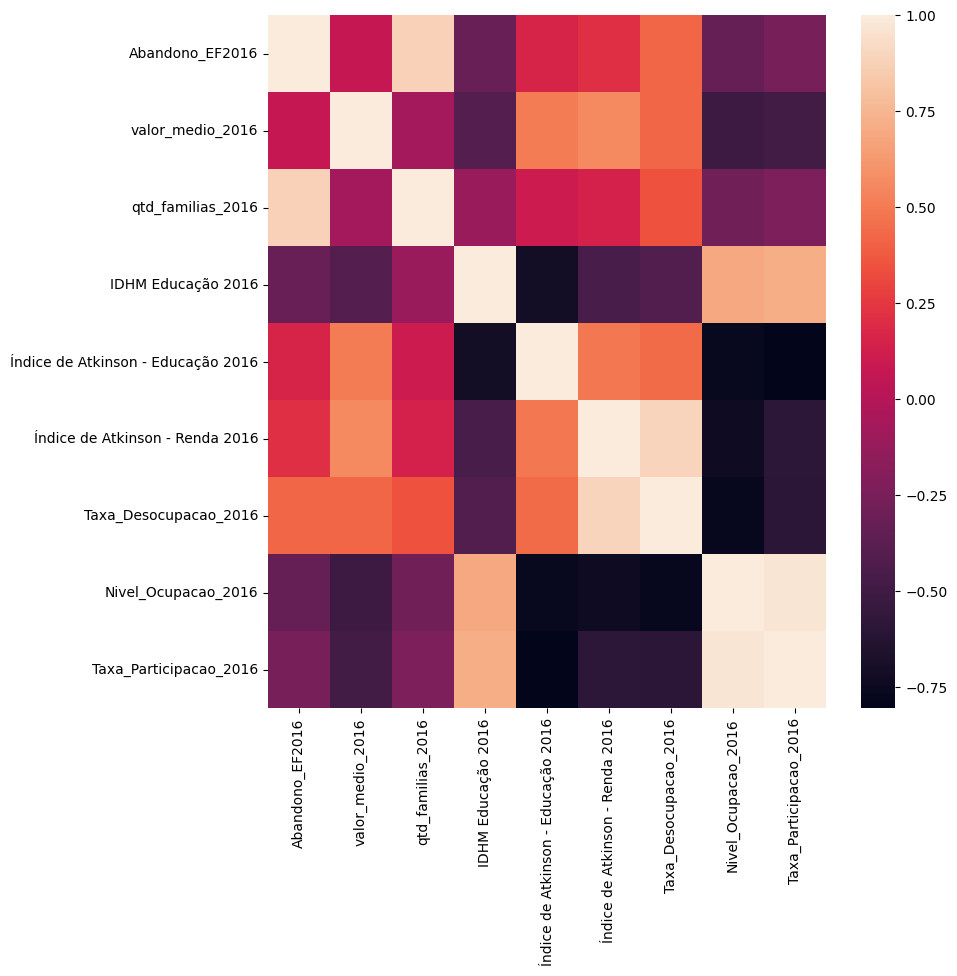

In [18]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2016','valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','Índice de Atkinson - Educação 2016','Índice de Atkinson - Renda 2016','Taxa_Desocupacao_2016','Nivel_Ocupacao_2016','Taxa_Participacao_2016']].corr())
plt.show()

In [19]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2017': 'qtd_familias_2017'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2017': 'valor_medio_2017'})

dados_df[['Abandono_EF2017','valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','Índice de Atkinson - Educação 2017','Índice de Atkinson - Renda 2017','Taxa_Desocupacao_2017','Nivel_Ocupacao_2017','Taxa_Participacao_2017']].corr()

,Abandono_EF2017,valor_medio_2017,qtd_familias_2017,IDHM Educação 2017,Índice de Atkinson - Educação 2017,Índice de Atkinson - Renda 2017,Taxa_Desocupacao_2017,Nivel_Ocupacao_2017,Taxa_Participacao_2017
Abandono_EF2017,1.000000,0.076633,0.865255,-0.266582,0.159165,0.243560,0.384183,-0.276138,-0.202633
valor_medio_2017,0.076633,1.000000,-0.047753,-0.422363,0.495842,0.603920,0.443059,-0.519338,-0.483398
qtd_familias_2017,0.865255,-0.047753,1.000000,-0.078071,0.140317,0.201728,0.357766,-0.294136,-0.233969
IDHM Educação 2017,-0.266582,-0.422363,-0.078071,1.000000,-0.797678,-0.451031,-0.475613,0.726635,0.740675
Índice de Atkinson - Educação 2017,0.159165,0.495842,0.140317,-0.797678,1.000000,0.480186,0.452303,-0.790507,-0.827980
Índice de Atkinson - Renda 2017,0.243560,0.603920,0.201728,-0.451031,0.480186,1.000000,0.890257,-0.702055,-0.544491
Taxa_Desocupacao_2017,0.384183,0.443059,0.357766,-0.475613,0.452303,0.890257,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2017,-0.276138,-0.519338,-0.294136,0.726635,-0.790507,-0.702055,-0.774518,1.000000,0.970122
Taxa_Participacao_2017,-0.202633,-0.483398,-0.233969,0.740675,-0.827980,-0.544491,-0.598578,0.970122,1.000000


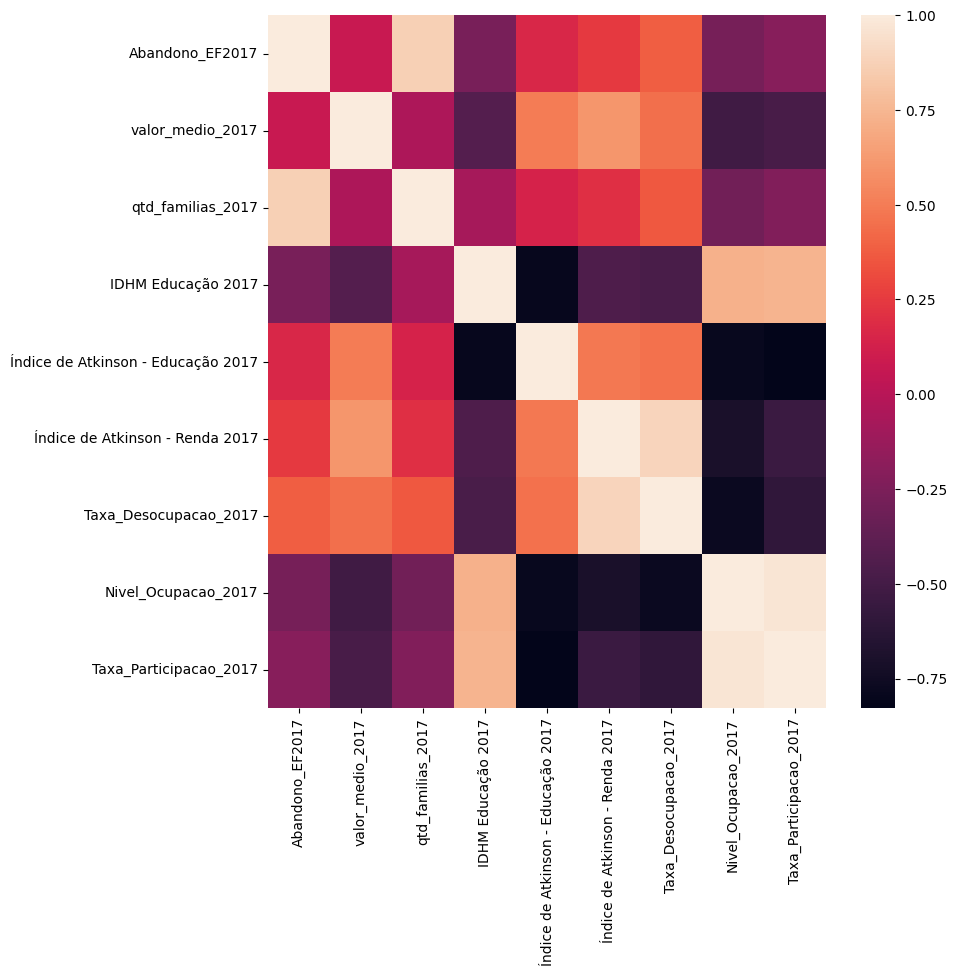

In [20]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2017','valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','Índice de Atkinson - Educação 2017','Índice de Atkinson - Renda 2017','Taxa_Desocupacao_2017','Nivel_Ocupacao_2017','Taxa_Participacao_2017']].corr())
plt.show()

In [21]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2018': 'qtd_familias_2018'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2018': 'valor_medio_2018'})

dados_df[['Abandono_EF2018','valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','Índice de Atkinson - Educação 2018','Índice de Atkinson - Renda 2018','Taxa_Desocupacao_2018','Nivel_Ocupacao_2018','Taxa_Participacao_2018']].corr()

,Abandono_EF2018,valor_medio_2018,qtd_familias_2018,IDHM Educação 2018,Índice de Atkinson - Educação 2018,Índice de Atkinson - Renda 2018,Taxa_Desocupacao_2018,Nivel_Ocupacao_2018,Taxa_Participacao_2018
Abandono_EF2018,1.000000,0.068057,0.836517,-0.321034,0.155435,0.194691,0.346861,-0.243842,-0.175663
valor_medio_2018,0.068057,1.000000,-0.054561,-0.355512,0.456788,0.624845,0.448228,-0.509117,-0.468423
qtd_familias_2018,0.836517,-0.054561,1.000000,-0.101879,0.155461,0.117187,0.360324,-0.292484,-0.230798
IDHM Educação 2018,-0.321034,-0.355512,-0.101879,1.000000,-0.802614,-0.488183,-0.398244,0.672877,0.701798
Índice de Atkinson - Educação 2018,0.155435,0.456788,0.155461,-0.802614,1.000000,0.588584,0.487948,-0.810697,-0.840382
Índice de Atkinson - Renda 2018,0.194691,0.624845,0.117187,-0.488183,0.588584,1.000000,0.833580,-0.761153,-0.641017
Taxa_Desocupacao_2018,0.346861,0.448228,0.360324,-0.398244,0.487948,0.833580,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2018,-0.243842,-0.509117,-0.292484,0.672877,-0.810697,-0.761153,-0.774518,1.000000,0.970122
Taxa_Participacao_2018,-0.175663,-0.468423,-0.230798,0.701798,-0.840382,-0.641017,-0.598578,0.970122,1.000000


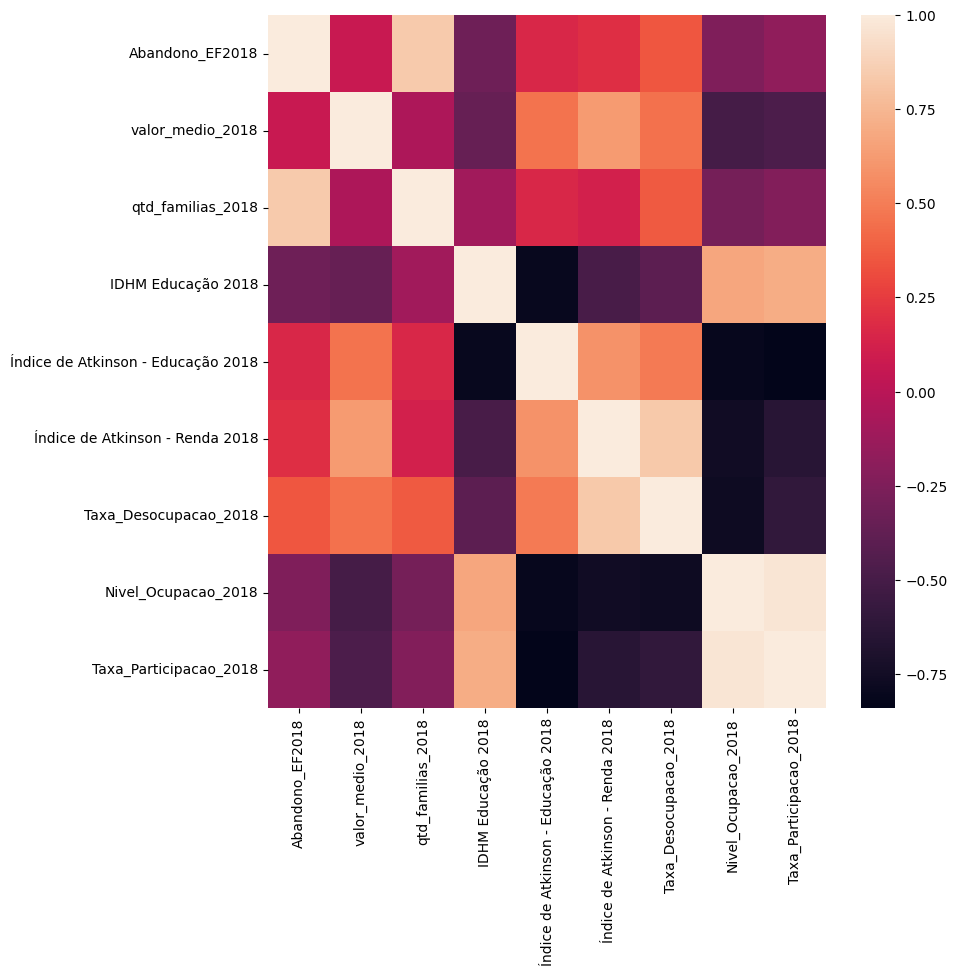

In [22]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2018','valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','Índice de Atkinson - Educação 2018','Índice de Atkinson - Renda 2018','Taxa_Desocupacao_2018','Nivel_Ocupacao_2018','Taxa_Participacao_2018']].corr())
plt.show()

In [23]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2019': 'qtd_familias_2019'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2019': 'valor_medio_2019'})

dados_df[['Abandono_EF2019','valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','Índice de Atkinson - Educação 2019','Índice de Atkinson - Renda 2019','Taxa_Desocupacao_2019','Nivel_Ocupacao_2019','Taxa_Participacao_2019']].corr()

,Abandono_EF2019,valor_medio_2019,qtd_familias_2019,IDHM Educação 2019,Índice de Atkinson - Educação 2019,Índice de Atkinson - Renda 2019,Taxa_Desocupacao_2019,Nivel_Ocupacao_2019,Taxa_Participacao_2019
Abandono_EF2019,1.000000,0.063305,0.814208,-0.242865,0.129439,0.205911,0.330273,-0.210546,-0.139021
valor_medio_2019,0.063305,1.000000,-0.060641,-0.244349,0.415517,0.625092,0.442350,-0.487003,-0.442730
qtd_familias_2019,0.814208,-0.060641,1.000000,-0.062894,0.192372,0.189551,0.368004,-0.302276,-0.240145
IDHM Educação 2019,-0.242865,-0.244349,-0.062894,1.000000,-0.772891,-0.549282,-0.419436,0.683110,0.707341
Índice de Atkinson - Educação 2019,0.129439,0.415517,0.192372,-0.772891,1.000000,0.676204,0.491773,-0.832540,-0.865888
Índice de Atkinson - Renda 2019,0.205911,0.625092,0.189551,-0.549282,0.676204,1.000000,0.793343,-0.812936,-0.719904
Taxa_Desocupacao_2019,0.330273,0.442350,0.368004,-0.419436,0.491773,0.793343,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2019,-0.210546,-0.487003,-0.302276,0.683110,-0.832540,-0.812936,-0.774518,1.000000,0.970122
Taxa_Participacao_2019,-0.139021,-0.442730,-0.240145,0.707341,-0.865888,-0.719904,-0.598578,0.970122,1.000000


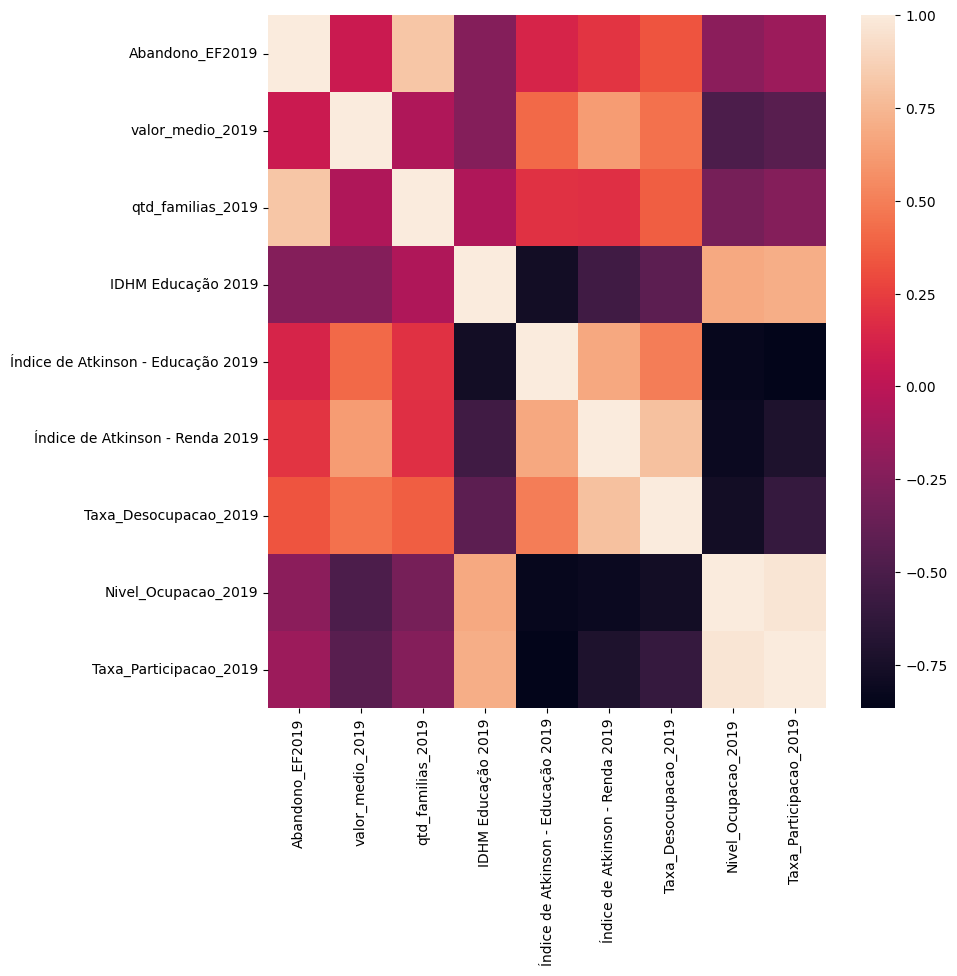

In [24]:
plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2019','valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','Índice de Atkinson - Educação 2019','Índice de Atkinson - Renda 2019','Taxa_Desocupacao_2019','Nivel_Ocupacao_2019','Taxa_Participacao_2019']].corr())
plt.show()

In [25]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2020': 'qtd_familias_2020'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2020': 'valor_medio_2020'})

dados_df[['Abandono_EF2020','valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','Índice de Atkinson - Educação 2020','Índice de Atkinson - Renda 2020','Taxa_Desocupacao_2020','Nivel_Ocupacao_2020','Taxa_Participacao_2020']].corr()

,Abandono_EF2020,valor_medio_2020,qtd_familias_2020,IDHM Educação 2020,Índice de Atkinson - Educação 2020,Índice de Atkinson - Renda 2020,Taxa_Desocupacao_2020,Nivel_Ocupacao_2020,Taxa_Participacao_2020
Abandono_EF2020,1.000000,-0.094111,0.792046,-0.142196,0.179534,0.044550,0.269669,-0.234137,-0.191184
valor_medio_2020,-0.094111,1.000000,-0.195147,-0.104627,0.200525,0.275748,0.175876,-0.198848,-0.183144
qtd_familias_2020,0.792046,-0.195147,1.000000,-0.010274,0.183474,0.210038,0.359957,-0.290286,-0.227947
IDHM Educação 2020,-0.142196,-0.104627,-0.010274,1.000000,-0.742734,-0.255963,-0.484825,0.689809,0.692158
Índice de Atkinson - Educação 2020,0.179534,0.200525,0.183474,-0.742734,1.000000,0.350124,0.491123,-0.825632,-0.858323
Índice de Atkinson - Renda 2020,0.044550,0.275748,0.210038,-0.255963,0.350124,1.000000,0.805673,-0.652155,-0.512367
Taxa_Desocupacao_2020,0.269669,0.175876,0.359957,-0.484825,0.491123,0.805673,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2020,-0.234137,-0.198848,-0.290286,0.689809,-0.825632,-0.652155,-0.774518,1.000000,0.970122
Taxa_Participacao_2020,-0.191184,-0.183144,-0.227947,0.692158,-0.858323,-0.512367,-0.598578,0.970122,1.000000


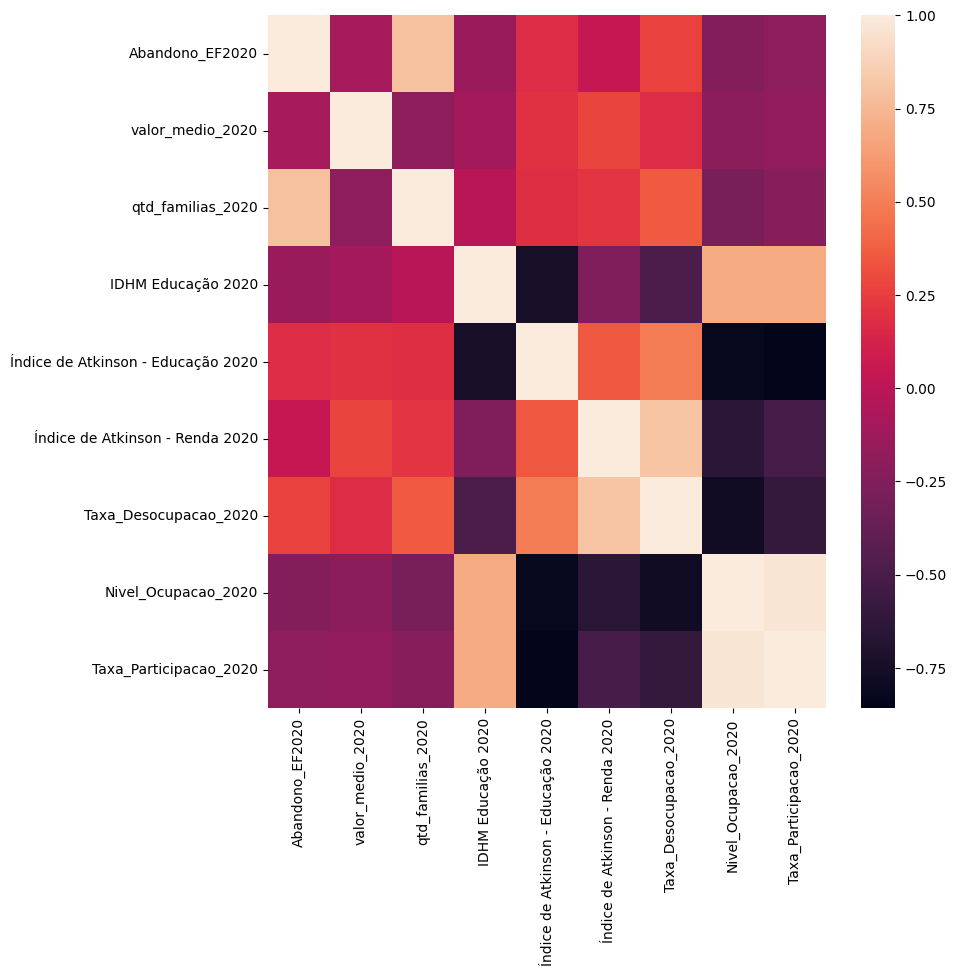

In [26]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2020','valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','Índice de Atkinson - Educação 2020','Índice de Atkinson - Renda 2020','Taxa_Desocupacao_2020','Nivel_Ocupacao_2020','Taxa_Participacao_2020']].corr())
plt.show()

In [27]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2021': 'qtd_familias_2021'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2021': 'valor_medio_2021'})

dados_df[['Abandono_EF2021','valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','Índice de Atkinson - Educação 2021','Índice de Atkinson - Renda 2021','Taxa_Desocupacao_2021','Nivel_Ocupacao_2021','Taxa_Participacao_2021']].corr()

,Abandono_EF2021,valor_medio_2021,qtd_familias_2021,IDHM Educação 2021,Índice de Atkinson - Educação 2021,Índice de Atkinson - Renda 2021,Taxa_Desocupacao_2021,Nivel_Ocupacao_2021,Taxa_Participacao_2021
Abandono_EF2021,1.000000,-0.000795,0.786204,-0.150155,0.124975,0.164293,0.313895,-0.164809,-0.088122
valor_medio_2021,-0.000795,1.000000,-0.165351,-0.343736,0.193753,0.367613,0.244356,-0.270099,-0.245624
qtd_familias_2021,0.786204,-0.165351,1.000000,0.119890,0.167585,0.213340,0.345878,-0.269194,-0.206624
IDHM Educação 2021,-0.150155,-0.343736,0.119890,1.000000,-0.638550,-0.507528,-0.519511,0.617114,0.583346
Índice de Atkinson - Educação 2021,0.124975,0.193753,0.167585,-0.638550,1.000000,0.409921,0.417990,-0.769797,-0.814329
Índice de Atkinson - Renda 2021,0.164293,0.367613,0.213340,-0.507528,0.409921,1.000000,0.825892,-0.740858,-0.616667
Taxa_Desocupacao_2021,0.313895,0.244356,0.345878,-0.519511,0.417990,0.825892,1.000000,-0.774518,-0.598578
Nivel_Ocupacao_2021,-0.164809,-0.270099,-0.269194,0.617114,-0.769797,-0.740858,-0.774518,1.000000,0.970122
Taxa_Participacao_2021,-0.088122,-0.245624,-0.206624,0.583346,-0.814329,-0.616667,-0.598578,0.970122,1.000000


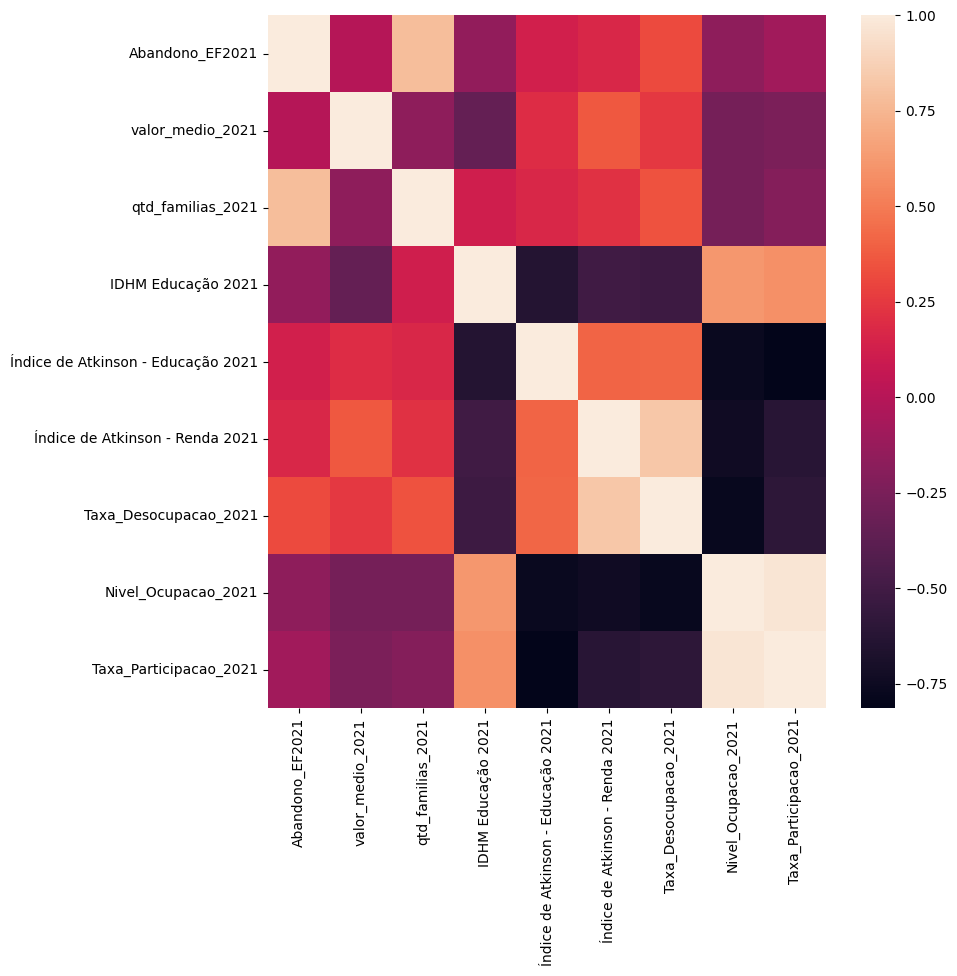

In [28]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EF2021','valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','Índice de Atkinson - Educação 2021','Índice de Atkinson - Renda 2021','Taxa_Desocupacao_2021','Nivel_Ocupacao_2021','Taxa_Participacao_2021']].corr())
plt.show()

### plotando graficos de disperção

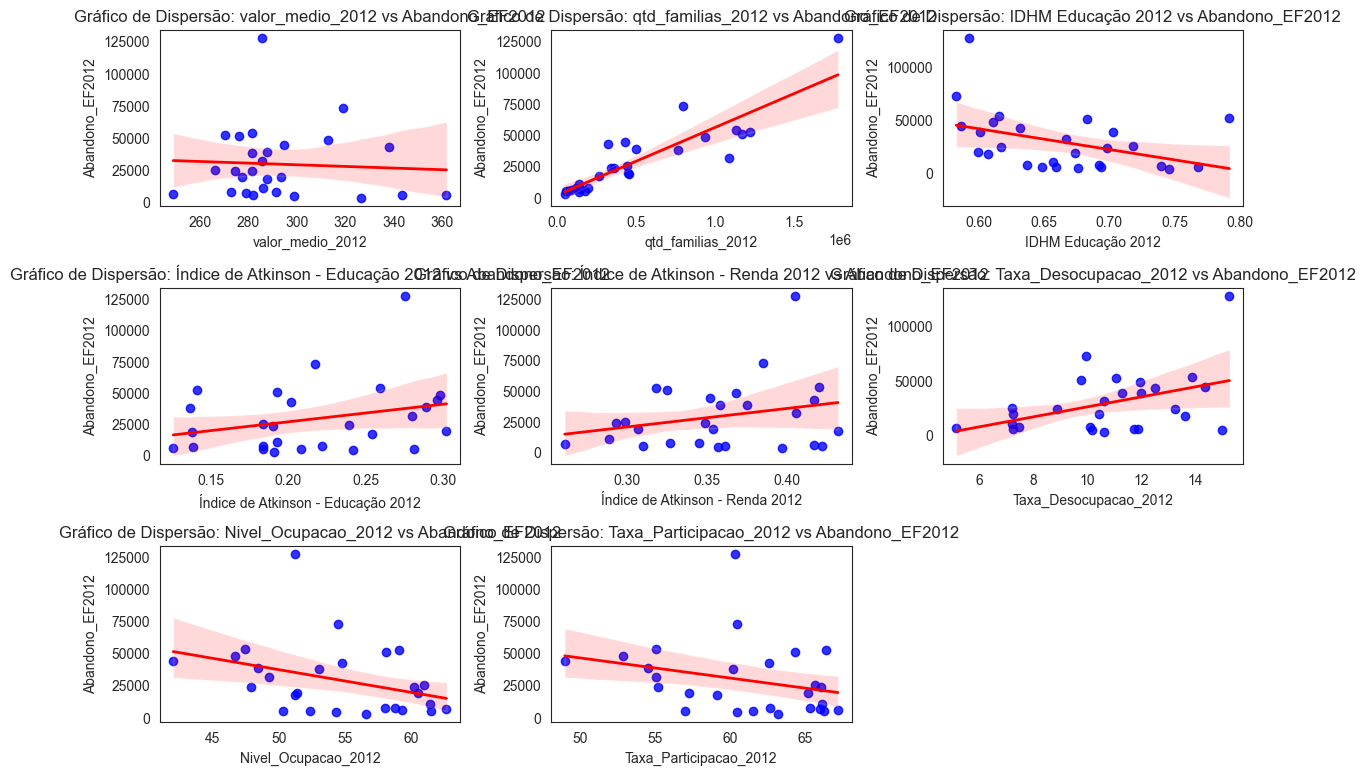

In [30]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','Índice de Atkinson - Educação 2012','Índice de Atkinson - Renda 2012','Taxa_Desocupacao_2012','Nivel_Ocupacao_2012','Taxa_Participacao_2012']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2012", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2012')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2012')


plt.tight_layout()
plt.show()


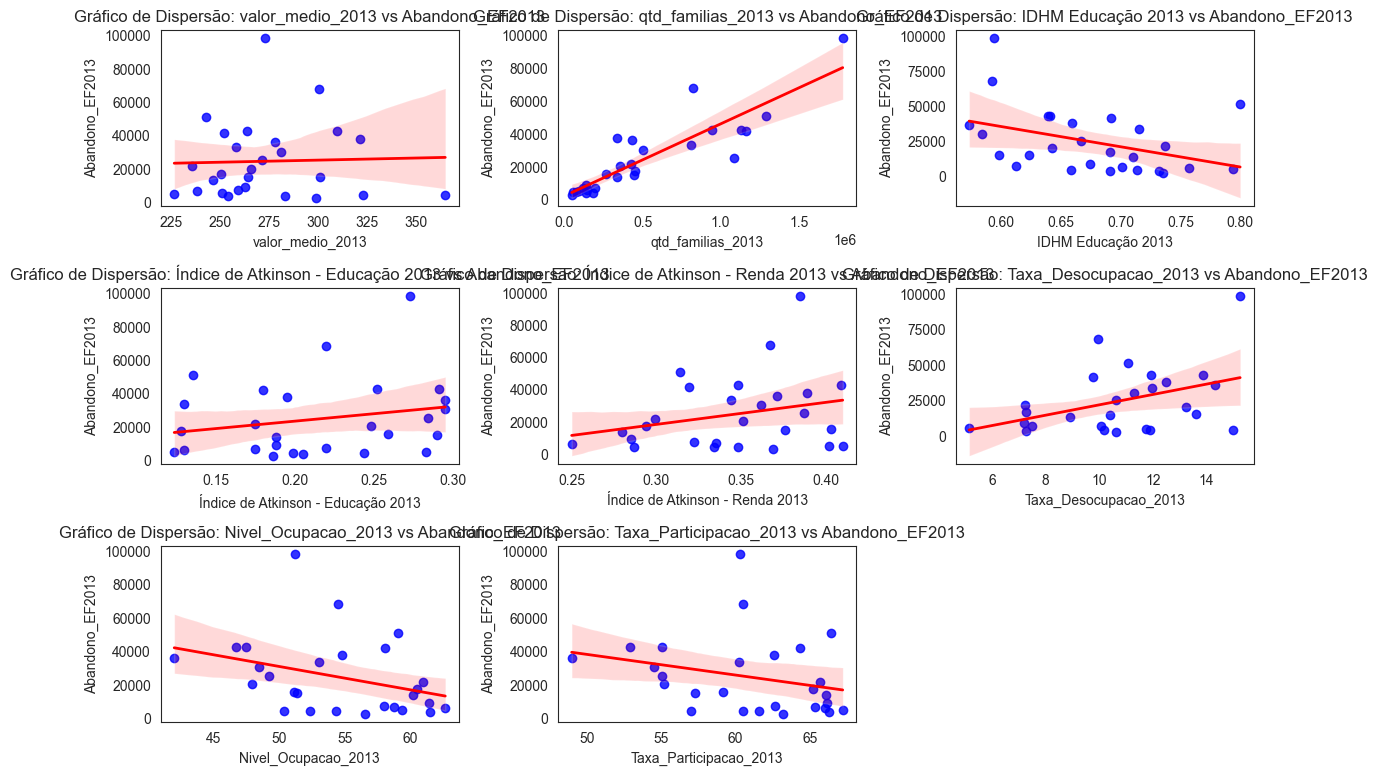

In [31]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','Índice de Atkinson - Educação 2013','Índice de Atkinson - Renda 2013','Taxa_Desocupacao_2013','Nivel_Ocupacao_2013','Taxa_Participacao_2013']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2013", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2013')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2013')


plt.tight_layout()
plt.show()


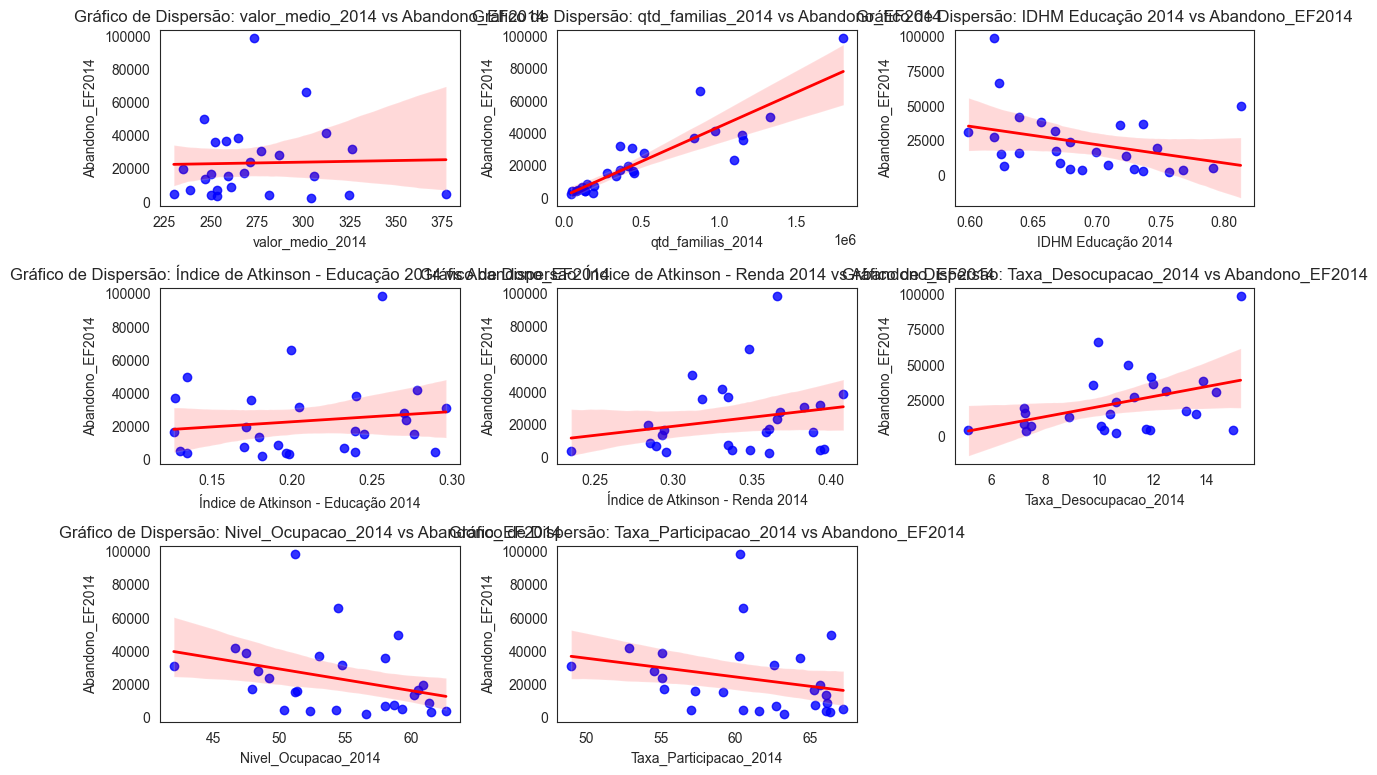

In [32]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','Índice de Atkinson - Educação 2014','Índice de Atkinson - Renda 2014','Taxa_Desocupacao_2014','Nivel_Ocupacao_2014','Taxa_Participacao_2014']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2014", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2014')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2014')


plt.tight_layout()
plt.show()


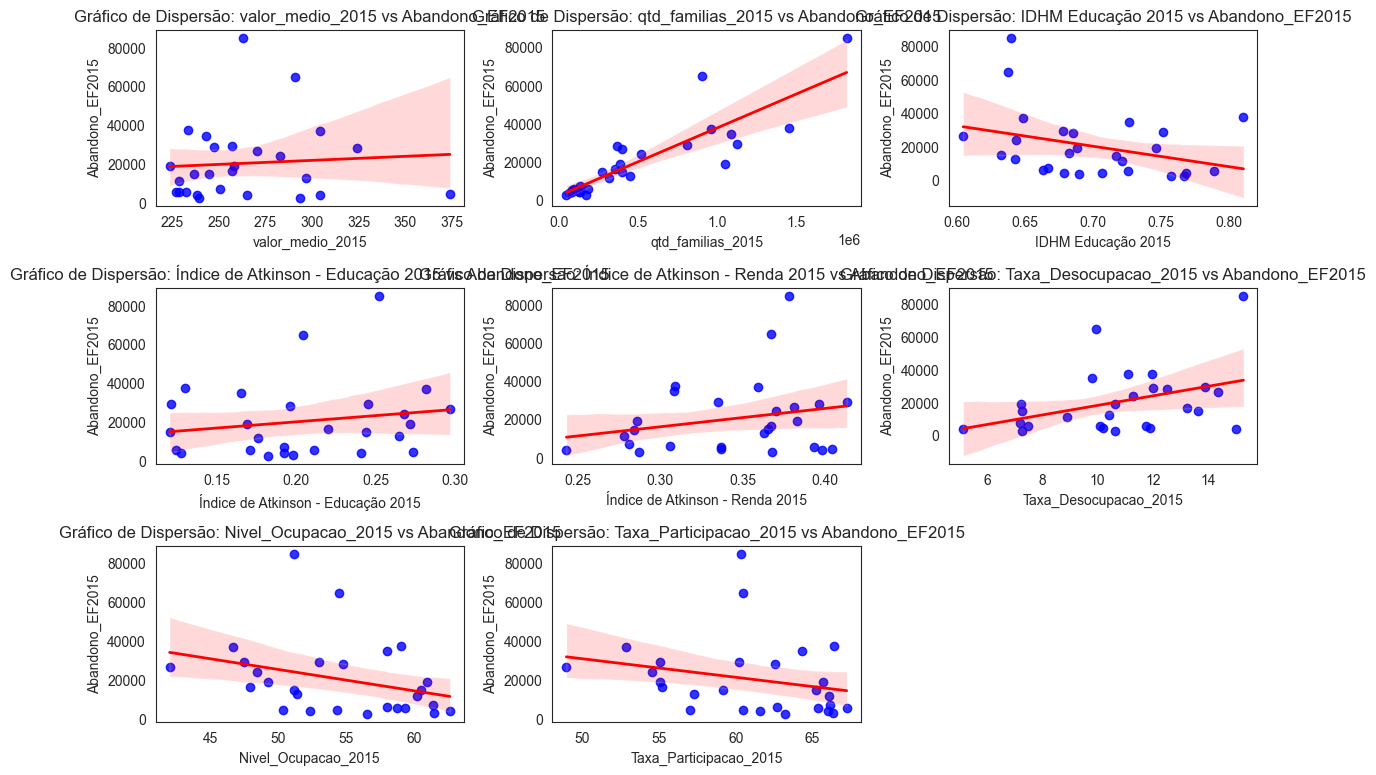

In [33]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','Índice de Atkinson - Educação 2015','Índice de Atkinson - Renda 2015','Taxa_Desocupacao_2015','Nivel_Ocupacao_2015','Taxa_Participacao_2015']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2015", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2015')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2015')


plt.tight_layout()
plt.show()


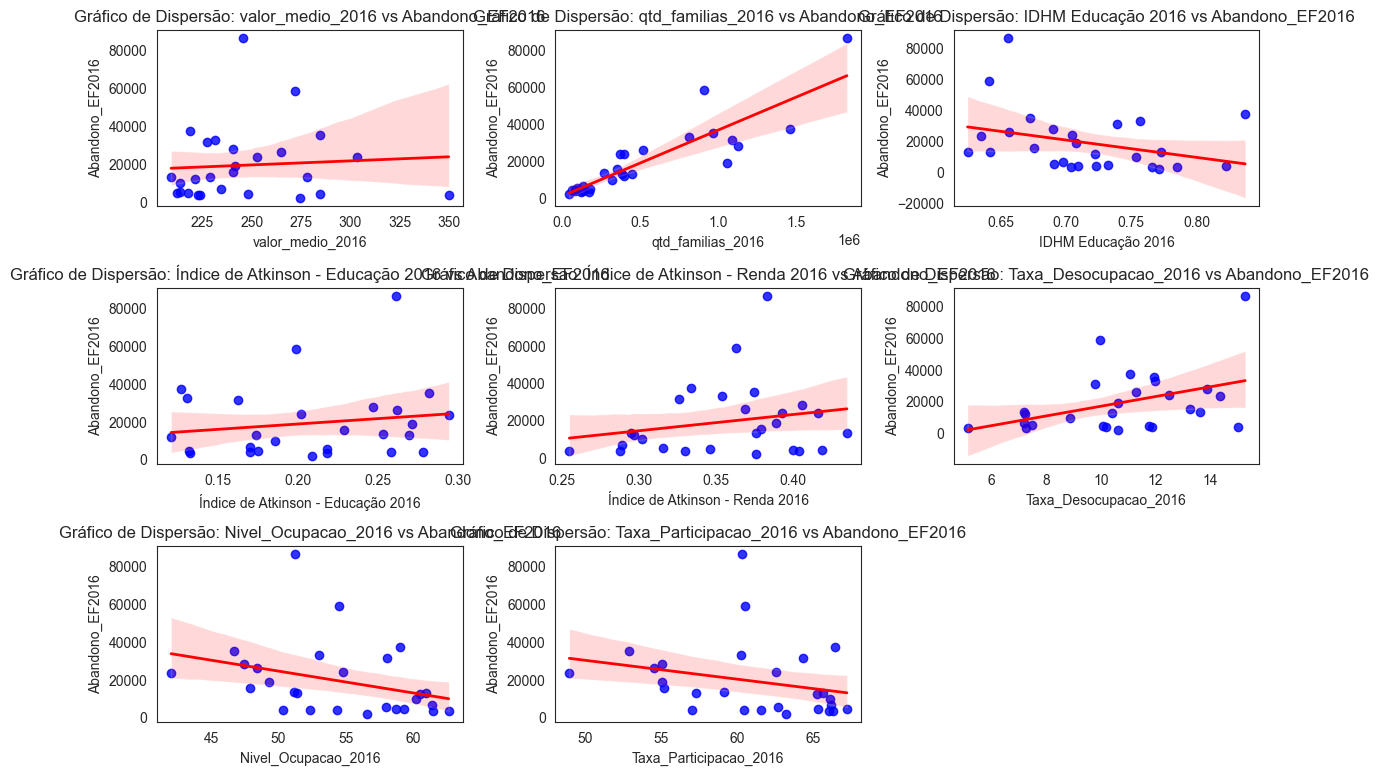

In [34]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','Índice de Atkinson - Educação 2016','Índice de Atkinson - Renda 2016','Taxa_Desocupacao_2016','Nivel_Ocupacao_2016','Taxa_Participacao_2016']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2016", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2016')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2016')


plt.tight_layout()
plt.show()


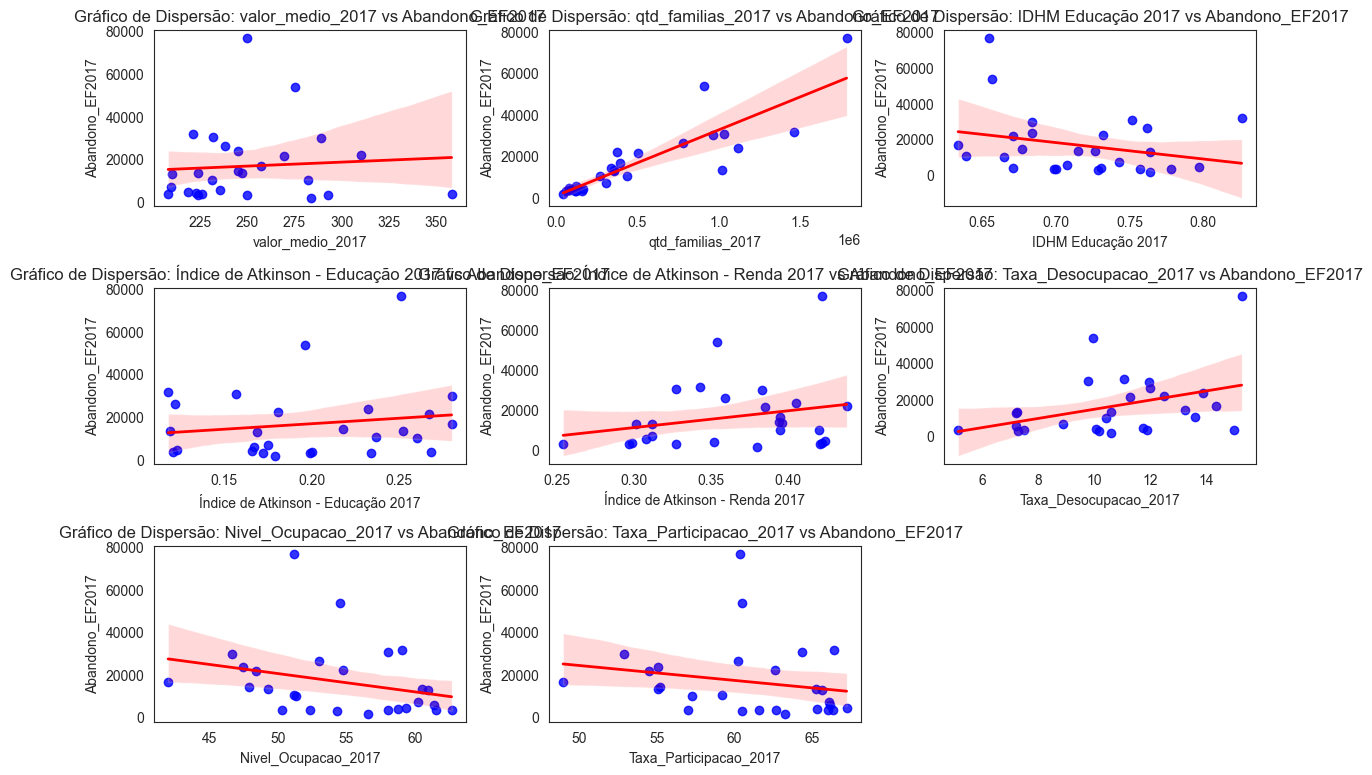

In [35]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','Índice de Atkinson - Educação 2017','Índice de Atkinson - Renda 2017','Taxa_Desocupacao_2017','Nivel_Ocupacao_2017','Taxa_Participacao_2017']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2017", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2017')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2017')


plt.tight_layout()
plt.show()


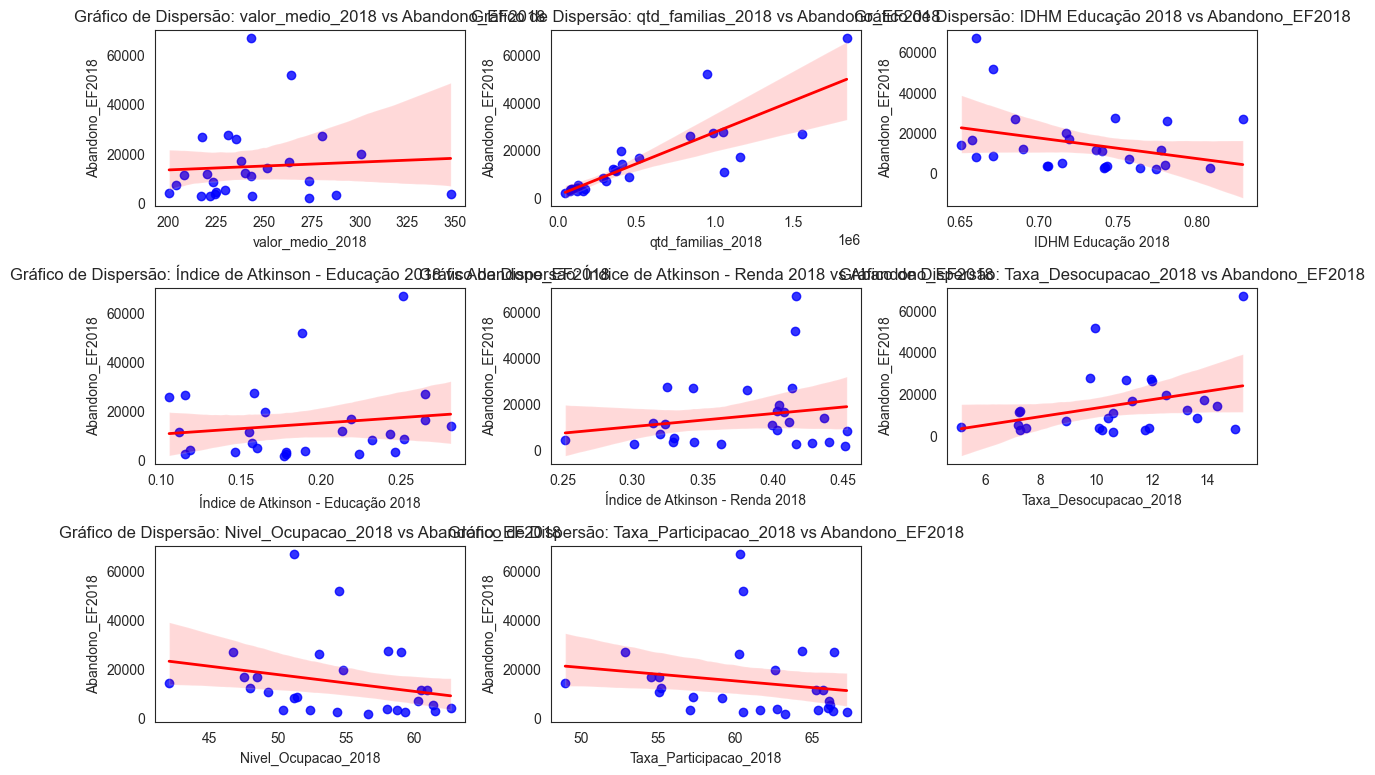

In [36]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','Índice de Atkinson - Educação 2018','Índice de Atkinson - Renda 2018','Taxa_Desocupacao_2018','Nivel_Ocupacao_2018','Taxa_Participacao_2018']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2018", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2018')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2018')


plt.tight_layout()
plt.show()


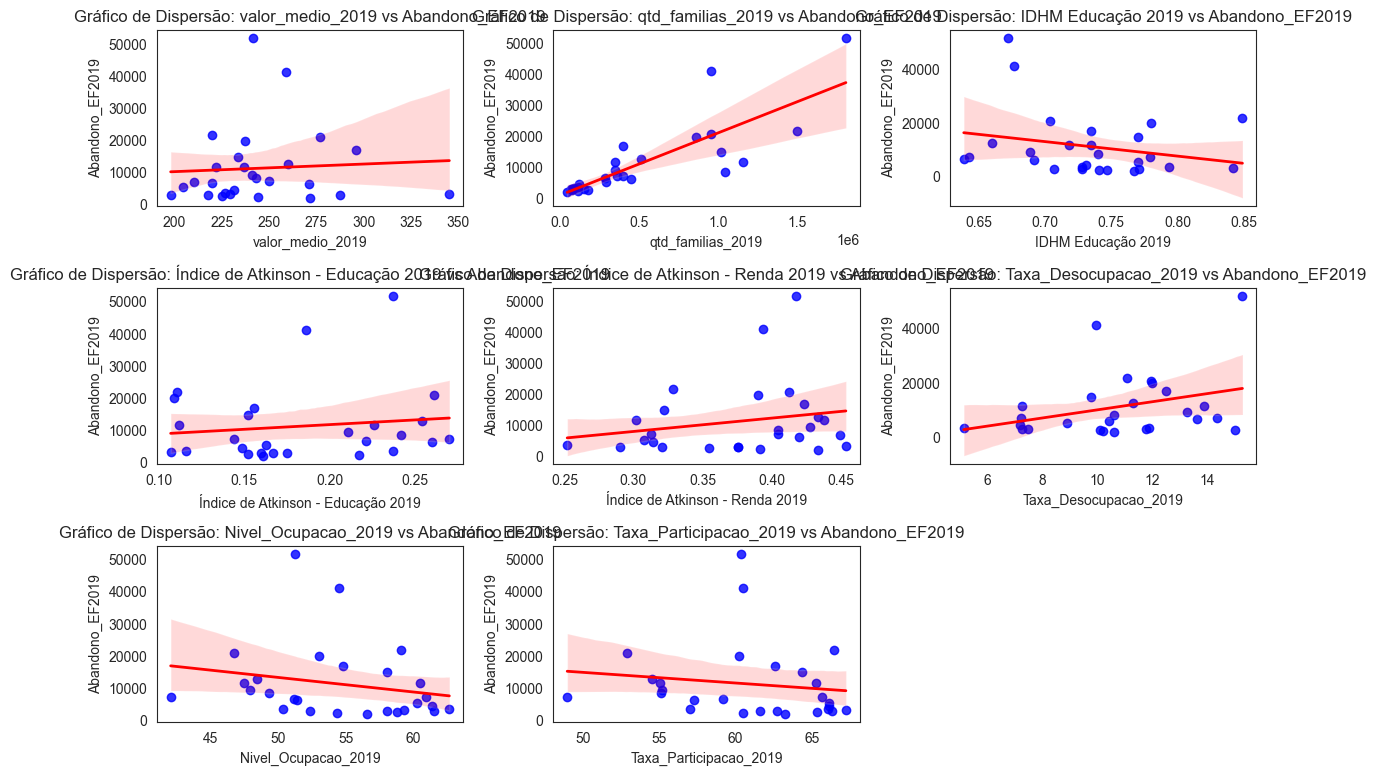

In [37]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','Índice de Atkinson - Educação 2019','Índice de Atkinson - Renda 2019','Taxa_Desocupacao_2019','Nivel_Ocupacao_2019','Taxa_Participacao_2019']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2019", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2019')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2019')


plt.tight_layout()
plt.show()


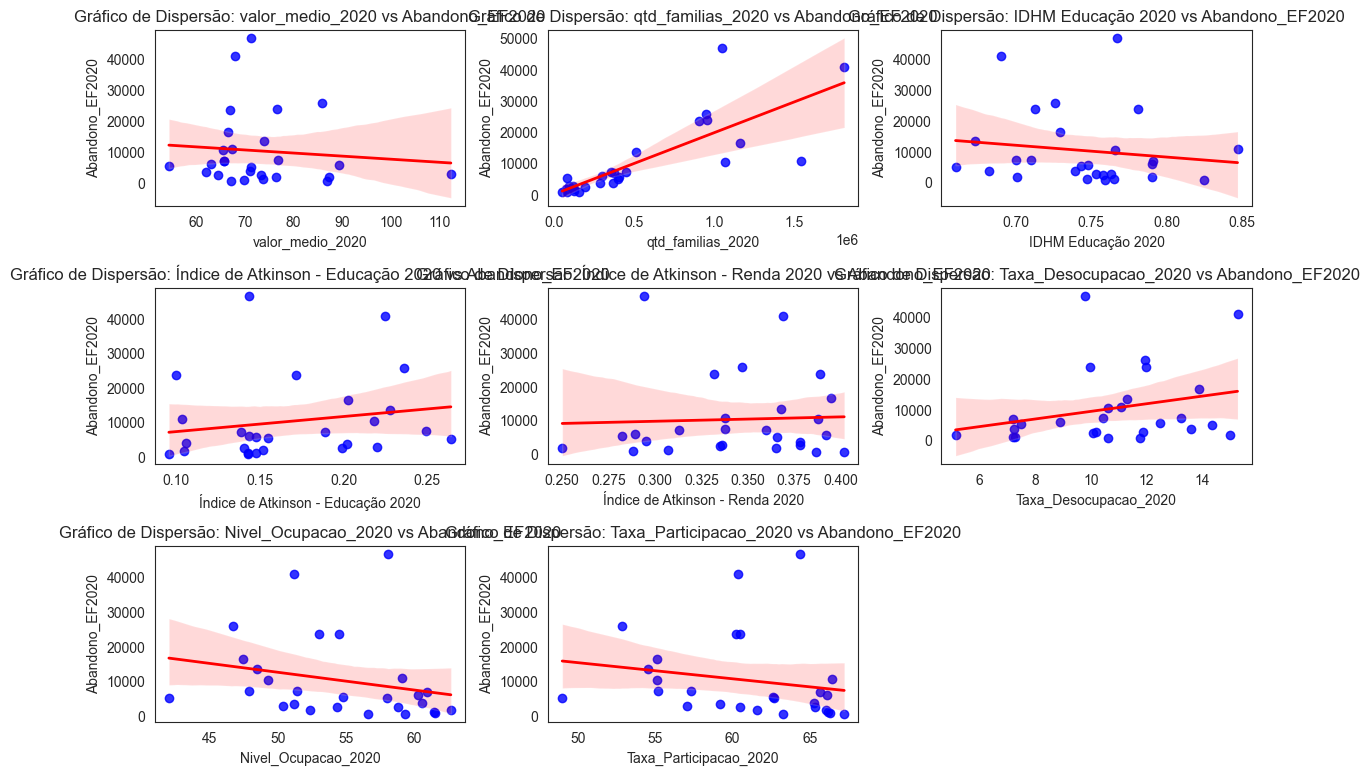

In [38]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','Índice de Atkinson - Educação 2020','Índice de Atkinson - Renda 2020','Taxa_Desocupacao_2020','Nivel_Ocupacao_2020','Taxa_Participacao_2020']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2020", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2020')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2020')


plt.tight_layout()
plt.show()


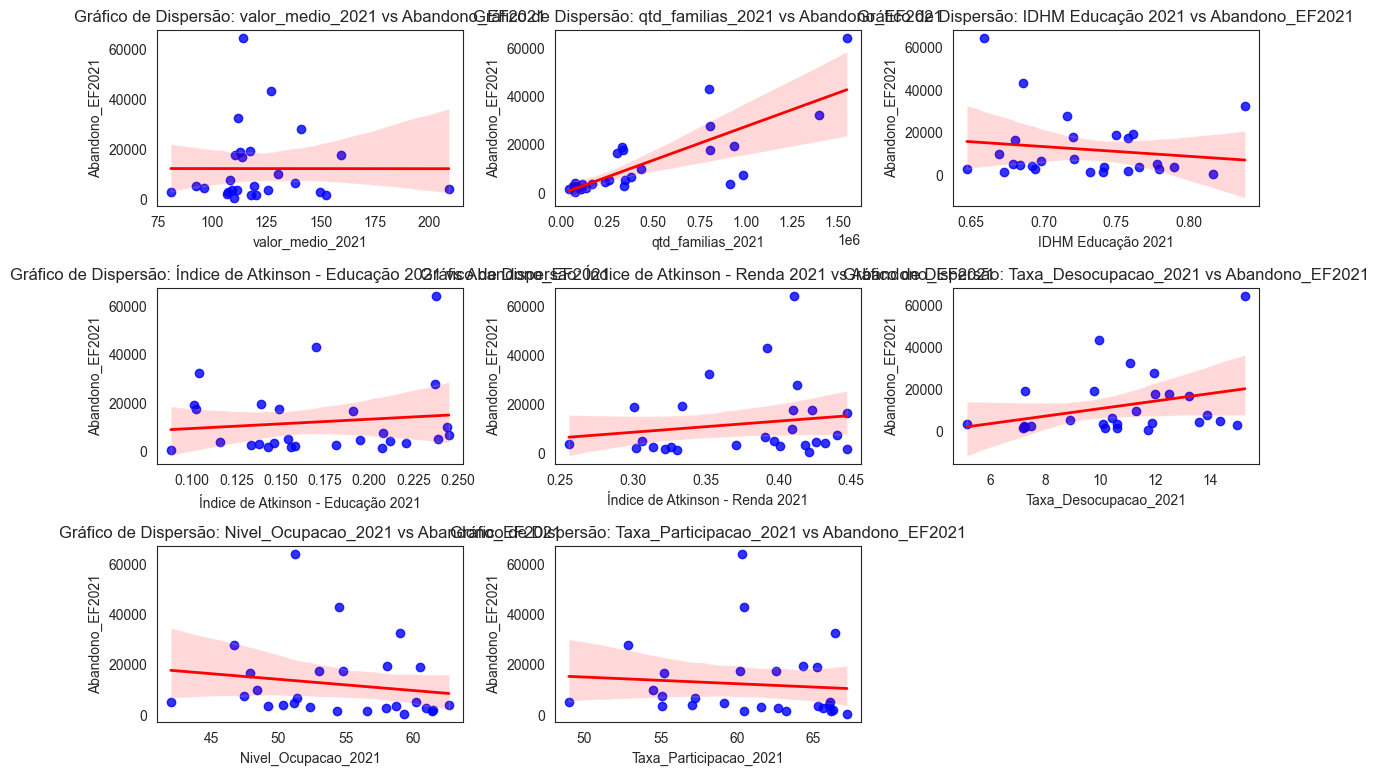

In [39]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','Índice de Atkinson - Educação 2021','Índice de Atkinson - Renda 2021','Taxa_Desocupacao_2021','Nivel_Ocupacao_2021','Taxa_Participacao_2021']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EF2021", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EF2021')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EF2021')


plt.tight_layout()
plt.show()


## correlação dos valores de cada ano usando o abandono do Encino Medio

In [40]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2012': 'qtd_familias_2012'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2012': 'valor_medio_2012'})

dados_df[['Abandono_EM2012','valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','IDHM Renda 2012','Índice de Atkinson - Educação 2012','Índice de Gini 2012','Taxa_Desocupacao_2012','Taxa_Participacao_2012']].corr()

,Abandono_EM2012,valor_medio_2012,qtd_familias_2012,IDHM Educação 2012,IDHM Renda 2012,Índice de Atkinson - Educação 2012,Índice de Gini 2012,Taxa_Desocupacao_2012,Taxa_Participacao_2012
Abandono_EM2012,1.000000,-0.264269,0.892195,-0.014588,0.034472,-0.053774,0.011308,0.128646,0.015345
valor_medio_2012,-0.264269,1.000000,-0.228185,-0.350410,-0.532823,0.342438,0.298905,0.314345,-0.318316
qtd_familias_2012,0.892195,-0.228185,1.000000,-0.197475,-0.193795,0.224720,0.183132,0.330697,-0.244950
IDHM Educação 2012,-0.014588,-0.350410,-0.197475,1.000000,0.846118,-0.784678,-0.151595,-0.431021,0.717837
IDHM Renda 2012,0.034472,-0.532823,-0.193795,0.846118,1.000000,-0.903516,-0.079826,-0.458808,0.835772
Índice de Atkinson - Educação 2012,-0.053774,0.342438,0.224720,-0.784678,-0.903516,1.000000,0.163825,0.431682,-0.827261
Índice de Gini 2012,0.011308,0.298905,0.183132,-0.151595,-0.079826,0.163825,1.000000,0.687851,-0.228384
Taxa_Desocupacao_2012,0.128646,0.314345,0.330697,-0.431021,-0.458808,0.431682,0.687851,1.000000,-0.598578
Taxa_Participacao_2012,0.015345,-0.318316,-0.244950,0.717837,0.835772,-0.827261,-0.228384,-0.598578,1.000000


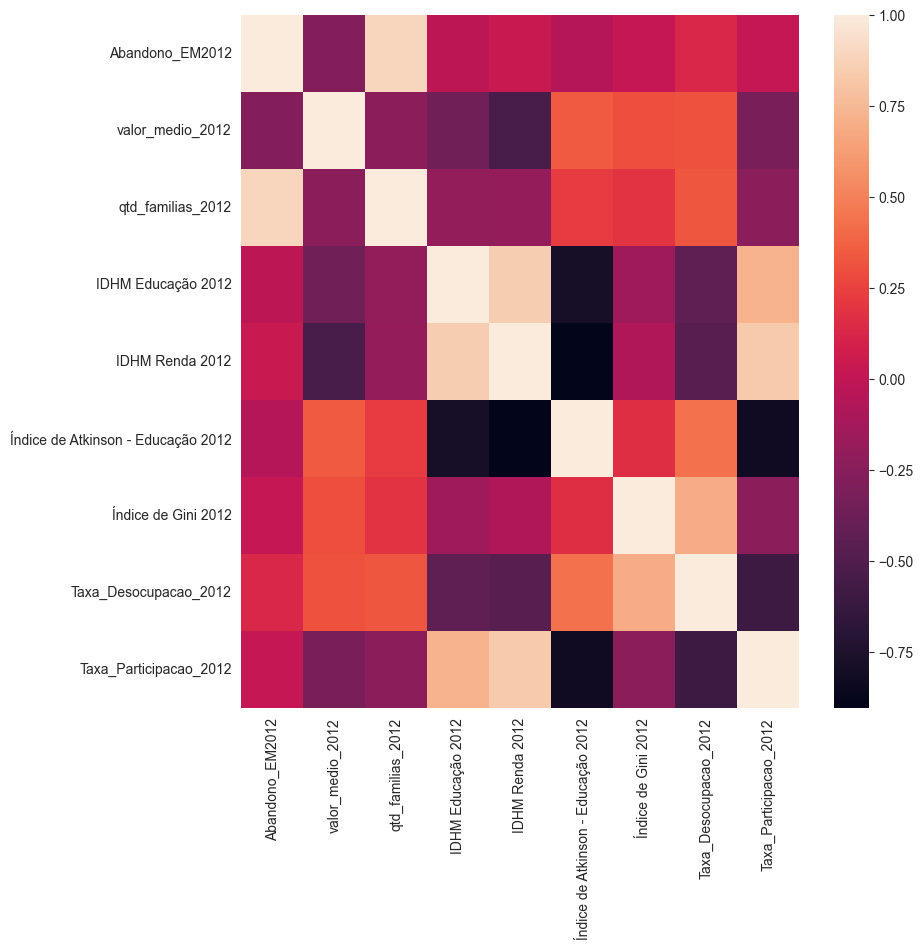

In [41]:
plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2012','valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','IDHM Renda 2012','Índice de Atkinson - Educação 2012','Índice de Gini 2012','Taxa_Desocupacao_2012','Taxa_Participacao_2012']].corr())
plt.show()

In [42]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2013': 'qtd_familias_2013'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2013': 'valor_medio_2013'})

dados_df[['Abandono_EM2013','valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','IDHM Renda 2013','Índice de Atkinson - Educação 2013','Índice de Gini 2013','Taxa_Desocupacao_2013','Taxa_Participacao_2013']].corr()

,Abandono_EM2013,valor_medio_2013,qtd_familias_2013,IDHM Educação 2013,IDHM Renda 2013,Índice de Atkinson - Educação 2013,Índice de Gini 2013,Taxa_Desocupacao_2013,Taxa_Participacao_2013
Abandono_EM2013,1.000000,-0.220373,0.789374,0.085468,0.093604,-0.178772,-0.116469,-0.004013,0.097596
valor_medio_2013,-0.220373,1.000000,-0.125897,-0.397830,-0.650077,0.537714,0.398907,0.394445,-0.480068
qtd_familias_2013,0.789374,-0.125897,1.000000,-0.198644,-0.194901,0.179016,0.134226,0.332006,-0.237851
IDHM Educação 2013,0.085468,-0.397830,-0.198644,1.000000,0.832995,-0.795641,-0.226448,-0.386007,0.723513
IDHM Renda 2013,0.093604,-0.650077,-0.194901,0.832995,1.000000,-0.906529,-0.211874,-0.460543,0.838961
Índice de Atkinson - Educação 2013,-0.178772,0.537714,0.179016,-0.795641,-0.906529,1.000000,0.295367,0.468906,-0.835582
Índice de Gini 2013,-0.116469,0.398907,0.134226,-0.226448,-0.211874,0.295367,1.000000,0.706399,-0.337348
Taxa_Desocupacao_2013,-0.004013,0.394445,0.332006,-0.386007,-0.460543,0.468906,0.706399,1.000000,-0.598578
Taxa_Participacao_2013,0.097596,-0.480068,-0.237851,0.723513,0.838961,-0.835582,-0.337348,-0.598578,1.000000


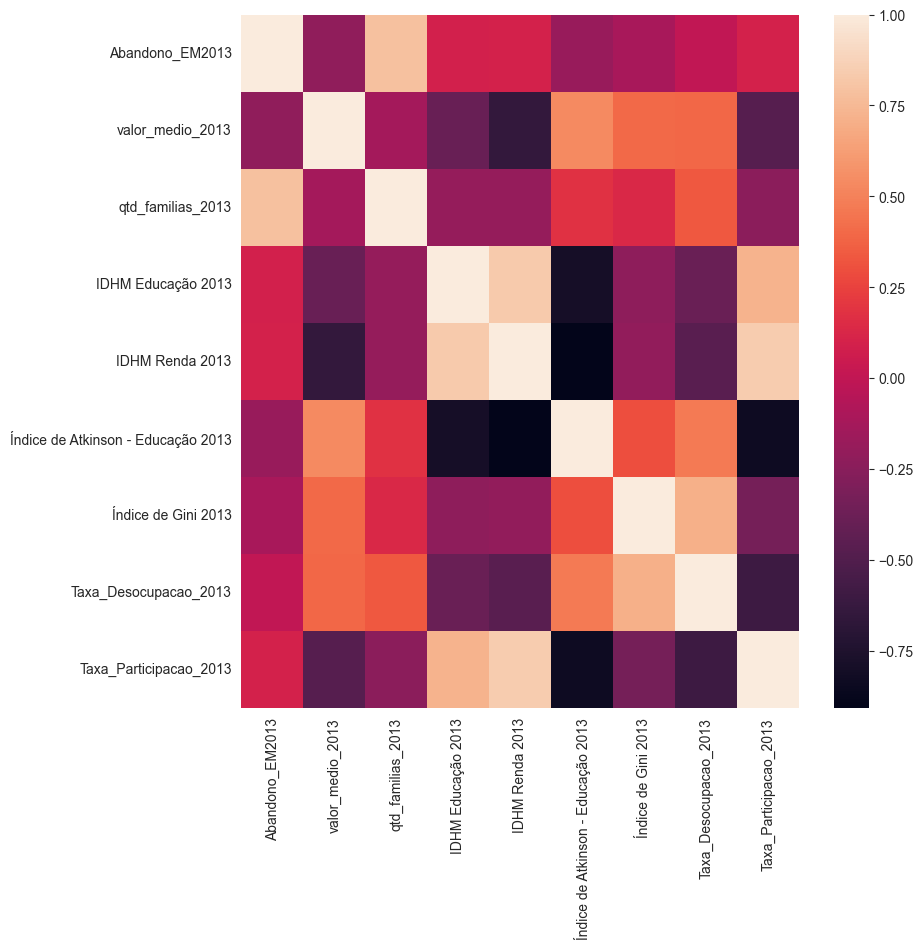

In [43]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2013','valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','IDHM Renda 2013','Índice de Atkinson - Educação 2013','Índice de Gini 2013','Taxa_Desocupacao_2013','Taxa_Participacao_2013']].corr())
plt.show()

In [44]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2014': 'qtd_familias_2014'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2014': 'valor_medio_2014'})

dados_df[['Abandono_EM2014','valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','IDHM Renda 2014','Índice de Atkinson - Educação 2014','Índice de Gini 2014','Taxa_Desocupacao_2014','Taxa_Participacao_2014']].corr()

,Abandono_EM2014,valor_medio_2014,qtd_familias_2014,IDHM Educação 2014,IDHM Renda 2014,Índice de Atkinson - Educação 2014,Índice de Gini 2014,Taxa_Desocupacao_2014,Taxa_Participacao_2014
Abandono_EM2014,1.000000,-0.184851,0.805795,0.108353,0.097461,-0.223263,-0.062750,0.014505,0.111346
valor_medio_2014,-0.184851,1.000000,-0.108491,-0.390789,-0.661275,0.552078,0.324163,0.396711,-0.468858
qtd_familias_2014,0.805795,-0.108491,1.000000,-0.165808,-0.168701,0.114110,0.192133,0.338272,-0.244247
IDHM Educação 2014,0.108353,-0.390789,-0.165808,1.000000,0.809670,-0.770561,-0.210308,-0.397729,0.701094
IDHM Renda 2014,0.097461,-0.661275,-0.168701,0.809670,1.000000,-0.886514,-0.172630,-0.445290,0.809787
Índice de Atkinson - Educação 2014,-0.223263,0.552078,0.114110,-0.770561,-0.886514,1.000000,0.273331,0.456621,-0.828171
Índice de Gini 2014,-0.062750,0.324163,0.192133,-0.210308,-0.172630,0.273331,1.000000,0.797039,-0.382185
Taxa_Desocupacao_2014,0.014505,0.396711,0.338272,-0.397729,-0.445290,0.456621,0.797039,1.000000,-0.598578
Taxa_Participacao_2014,0.111346,-0.468858,-0.244247,0.701094,0.809787,-0.828171,-0.382185,-0.598578,1.000000


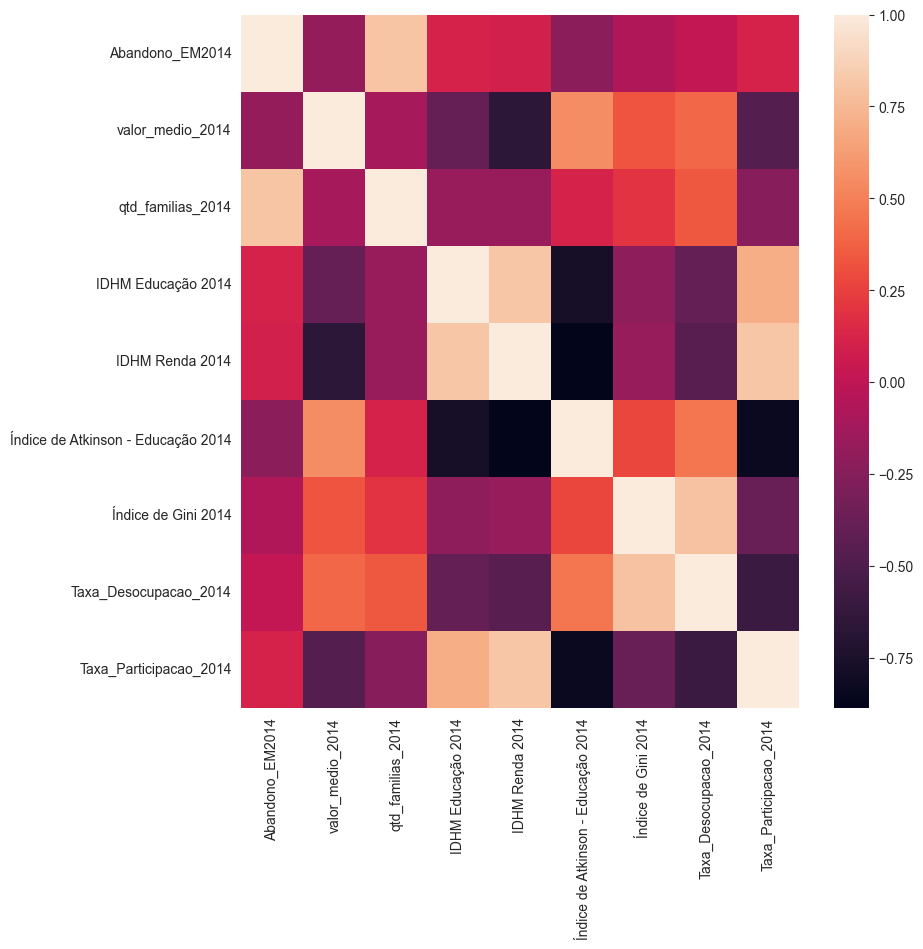

In [45]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2014','valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','IDHM Renda 2014','Índice de Atkinson - Educação 2014','Índice de Gini 2014','Taxa_Desocupacao_2014','Taxa_Participacao_2014']].corr())
plt.show()

In [46]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2015': 'qtd_familias_2015'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2015': 'valor_medio_2015'})

dados_df[['Abandono_EM2015','valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','IDHM Renda 2015','Índice de Atkinson - Educação 2015','Índice de Gini 2015','Taxa_Desocupacao_2015','Taxa_Participacao_2015']].corr()

,Abandono_EM2015,valor_medio_2015,qtd_familias_2015,IDHM Educação 2015,IDHM Renda 2015,Índice de Atkinson - Educação 2015,Índice de Gini 2015,Taxa_Desocupacao_2015,Taxa_Participacao_2015
Abandono_EM2015,1.000000,-0.156376,0.730778,0.087709,0.029664,-0.181449,-0.194478,-0.082765,0.120733
valor_medio_2015,-0.156376,1.000000,-0.071279,-0.429818,-0.596642,0.532161,0.486416,0.417694,-0.484071
qtd_familias_2015,0.730778,-0.071279,1.000000,-0.109309,-0.180727,0.130287,0.151733,0.346738,-0.228090
IDHM Educação 2015,0.087709,-0.429818,-0.109309,1.000000,0.844008,-0.803004,-0.241426,-0.421586,0.723231
IDHM Renda 2015,0.029664,-0.596642,-0.180727,0.844008,1.000000,-0.888868,-0.236532,-0.433281,0.786924
Índice de Atkinson - Educação 2015,-0.181449,0.532161,0.130287,-0.803004,-0.888868,1.000000,0.347637,0.462234,-0.831263
Índice de Gini 2015,-0.194478,0.486416,0.151733,-0.241426,-0.236532,0.347637,1.000000,0.824218,-0.449767
Taxa_Desocupacao_2015,-0.082765,0.417694,0.346738,-0.421586,-0.433281,0.462234,0.824218,1.000000,-0.598578
Taxa_Participacao_2015,0.120733,-0.484071,-0.228090,0.723231,0.786924,-0.831263,-0.449767,-0.598578,1.000000


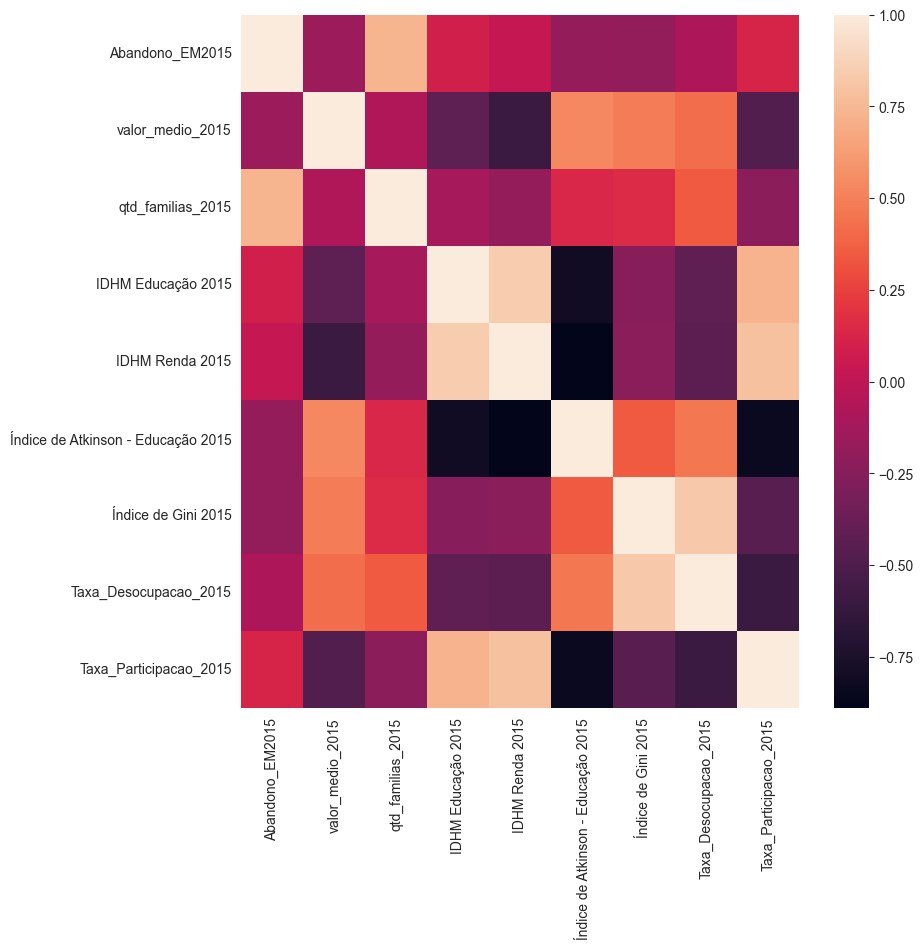

In [47]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2015','valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','IDHM Renda 2015','Índice de Atkinson - Educação 2015','Índice de Gini 2015','Taxa_Desocupacao_2015','Taxa_Participacao_2015']].corr())
plt.show()

In [48]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2016': 'qtd_familias_2016'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2016': 'valor_medio_2016'})

dados_df[['Abandono_EM2016','valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','IDHM Renda 2016','Índice de Atkinson - Educação 2016','Índice de Gini 2016','Taxa_Desocupacao_2016','Taxa_Participacao_2016']].corr()

,Abandono_EM2016,valor_medio_2016,qtd_familias_2016,IDHM Educação 2016,IDHM Renda 2016,Índice de Atkinson - Educação 2016,Índice de Gini 2016,Taxa_Desocupacao_2016,Taxa_Participacao_2016
Abandono_EM2016,1.000000,-0.169851,0.795509,0.147256,0.102189,-0.253181,-0.081152,0.006045,0.082332
valor_medio_2016,-0.169851,1.000000,-0.071292,-0.407189,-0.643526,0.505397,0.475825,0.417668,-0.484050
qtd_familias_2016,0.795509,-0.071292,1.000000,-0.111705,-0.172896,0.104769,0.200837,0.346738,-0.228090
IDHM Educação 2016,0.147256,-0.407189,-0.111705,1.000000,0.824511,-0.717711,-0.262426,-0.420440,0.715143
IDHM Renda 2016,0.102189,-0.643526,-0.172896,0.824511,1.000000,-0.861611,-0.280512,-0.449946,0.777418
Índice de Atkinson - Educação 2016,-0.253181,0.505397,0.104769,-0.717711,-0.861611,1.000000,0.338389,0.440423,-0.804330
Índice de Gini 2016,-0.081152,0.475825,0.200837,-0.262426,-0.280512,0.338389,1.000000,0.855731,-0.461743
Taxa_Desocupacao_2016,0.006045,0.417668,0.346738,-0.420440,-0.449946,0.440423,0.855731,1.000000,-0.598578
Taxa_Participacao_2016,0.082332,-0.484050,-0.228090,0.715143,0.777418,-0.804330,-0.461743,-0.598578,1.000000


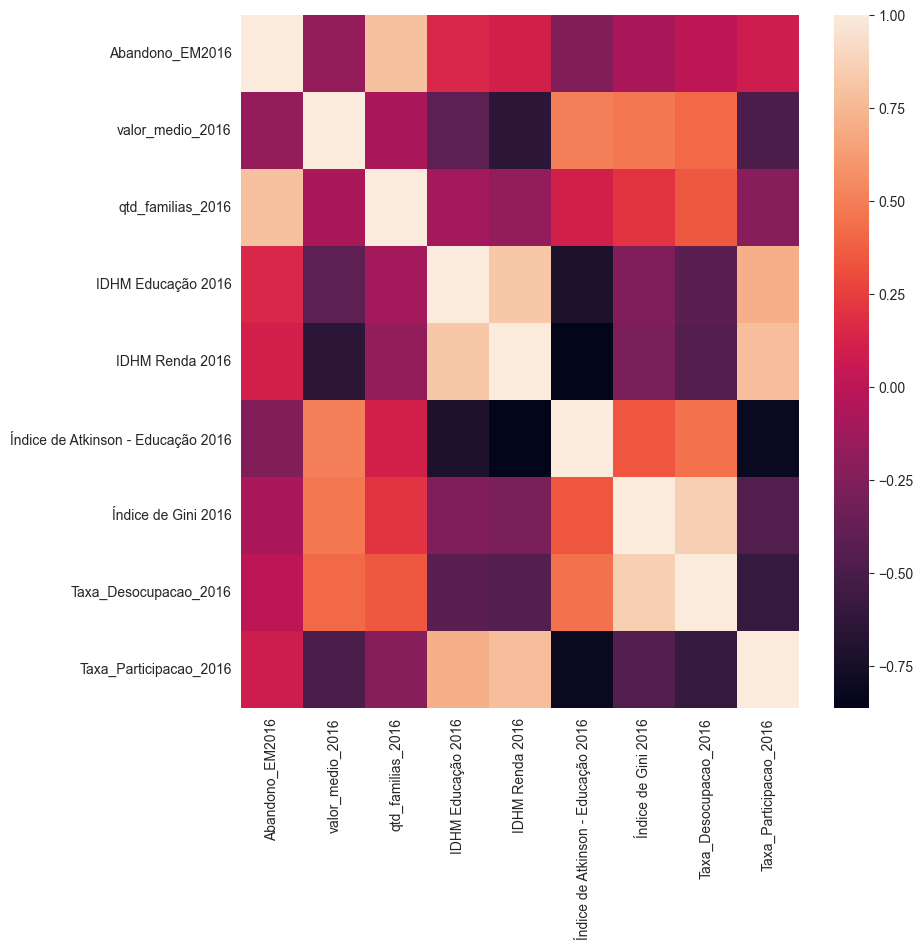

In [49]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2016','valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','IDHM Renda 2016','Índice de Atkinson - Educação 2016','Índice de Gini 2016','Taxa_Desocupacao_2016','Taxa_Participacao_2016']].corr())
plt.show()

In [50]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2017': 'qtd_familias_2017'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2017': 'valor_medio_2017'})

dados_df[['Abandono_EM2017','valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','IDHM Renda 2017','Índice de Atkinson - Educação 2017','Índice de Gini 2017','Taxa_Desocupacao_2017','Taxa_Participacao_2017']].corr()

,Abandono_EM2017,valor_medio_2017,qtd_familias_2017,IDHM Educação 2017,IDHM Renda 2017,Índice de Atkinson - Educação 2017,Índice de Gini 2017,Taxa_Desocupacao_2017,Taxa_Participacao_2017
Abandono_EM2017,1.000000,-0.164317,0.774166,0.190195,0.141314,-0.216361,0.012667,-0.012086,0.150206
valor_medio_2017,-0.164317,1.000000,-0.047753,-0.422363,-0.627108,0.495842,0.495102,0.443059,-0.483398
qtd_familias_2017,0.774166,-0.047753,1.000000,-0.078071,-0.161292,0.140317,0.296650,0.357766,-0.233969
IDHM Educação 2017,0.190195,-0.422363,-0.078071,1.000000,0.824496,-0.797678,-0.267777,-0.475613,0.740675
IDHM Renda 2017,0.141314,-0.627108,-0.161292,0.824496,1.000000,-0.866737,-0.281133,-0.489758,0.804742
Índice de Atkinson - Educação 2017,-0.216361,0.495842,0.140317,-0.797678,-0.866737,1.000000,0.305609,0.452303,-0.827980
Índice de Gini 2017,0.012667,0.495102,0.296650,-0.267777,-0.281133,0.305609,1.000000,0.864865,-0.370003
Taxa_Desocupacao_2017,-0.012086,0.443059,0.357766,-0.475613,-0.489758,0.452303,0.864865,1.000000,-0.598578
Taxa_Participacao_2017,0.150206,-0.483398,-0.233969,0.740675,0.804742,-0.827980,-0.370003,-0.598578,1.000000


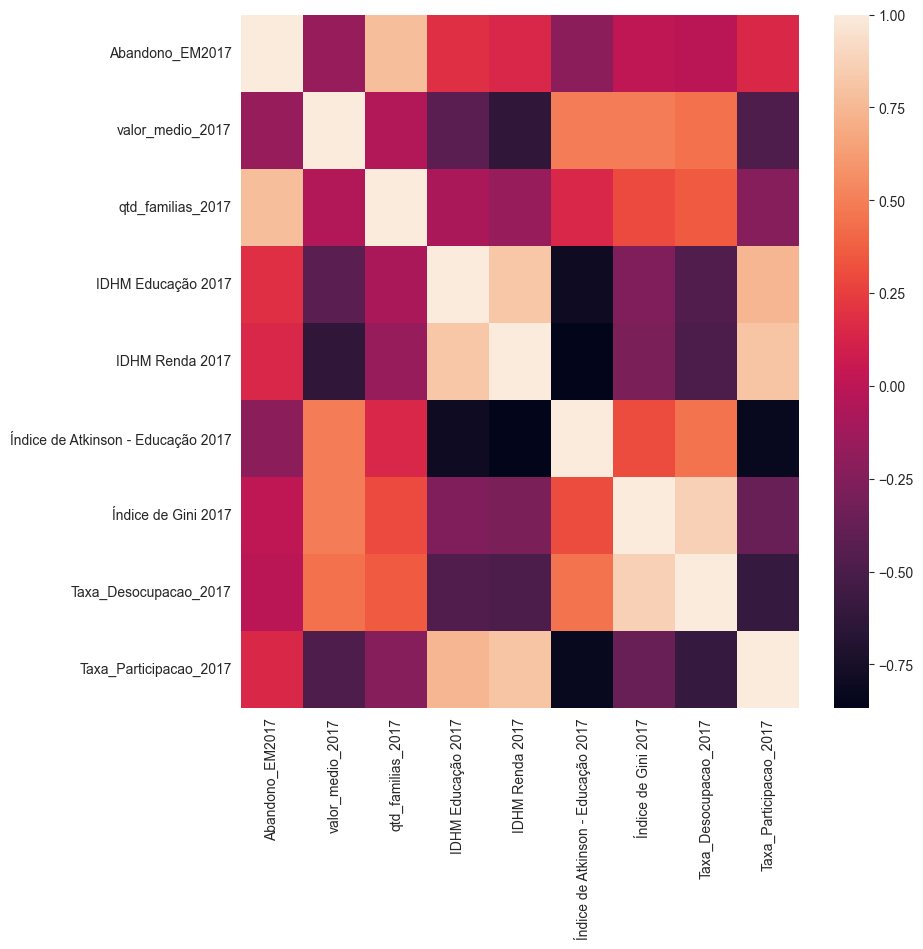

In [51]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2017','valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','IDHM Renda 2017','Índice de Atkinson - Educação 2017','Índice de Gini 2017','Taxa_Desocupacao_2017','Taxa_Participacao_2017']].corr())
plt.show()

In [52]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2018': 'qtd_familias_2018'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2018': 'valor_medio_2018'})

dados_df[['Abandono_EM2018','valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','IDHM Renda 2018','Índice de Atkinson - Educação 2018','Índice de Gini 2018','Taxa_Desocupacao_2018','Taxa_Participacao_2018']].corr()

,Abandono_EM2018,valor_medio_2018,qtd_familias_2018,IDHM Educação 2018,IDHM Renda 2018,Índice de Atkinson - Educação 2018,Índice de Gini 2018,Taxa_Desocupacao_2018,Taxa_Participacao_2018
Abandono_EM2018,1.000000,-0.121317,0.761826,0.054887,0.084351,-0.172425,-0.023992,0.009192,0.151090
valor_medio_2018,-0.121317,1.000000,-0.054561,-0.355512,-0.590735,0.456788,0.487757,0.448228,-0.468423
qtd_familias_2018,0.761826,-0.054561,1.000000,-0.101879,-0.195784,0.155461,0.217673,0.360324,-0.230798
IDHM Educação 2018,0.054887,-0.355512,-0.101879,1.000000,0.810922,-0.802614,-0.328392,-0.398244,0.701798
IDHM Renda 2018,0.084351,-0.590735,-0.195784,0.810922,1.000000,-0.866995,-0.397879,-0.545430,0.800978
Índice de Atkinson - Educação 2018,-0.172425,0.456788,0.155461,-0.802614,-0.866995,1.000000,0.421807,0.487948,-0.840382
Índice de Gini 2018,-0.023992,0.487757,0.217673,-0.328392,-0.397879,0.421807,1.000000,0.791240,-0.496732
Taxa_Desocupacao_2018,0.009192,0.448228,0.360324,-0.398244,-0.545430,0.487948,0.791240,1.000000,-0.598578
Taxa_Participacao_2018,0.151090,-0.468423,-0.230798,0.701798,0.800978,-0.840382,-0.496732,-0.598578,1.000000


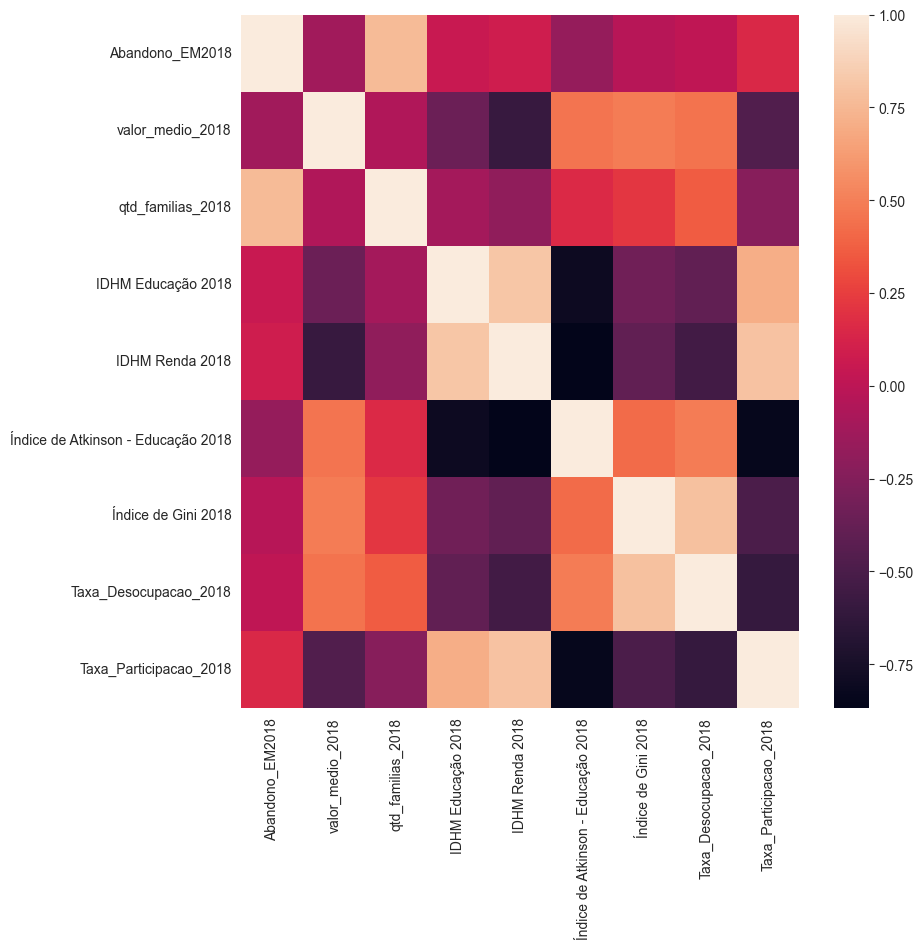

In [53]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2018','valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','IDHM Renda 2018','Índice de Atkinson - Educação 2018','Índice de Gini 2018','Taxa_Desocupacao_2018','Taxa_Participacao_2018']].corr())
plt.show()

In [54]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2019': 'qtd_familias_2019'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2019': 'valor_medio_2019'})

dados_df[['Abandono_EM2019','valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','IDHM Renda 2019','Índice de Atkinson - Educação 2019','Índice de Gini 2019','Taxa_Desocupacao_2019','Taxa_Participacao_2019']].corr()

,Abandono_EM2019,valor_medio_2019,qtd_familias_2019,IDHM Educação 2019,IDHM Renda 2019,Índice de Atkinson - Educação 2019,Índice de Gini 2019,Taxa_Desocupacao_2019,Taxa_Participacao_2019
Abandono_EM2019,1.000000,-0.077938,0.753720,0.092658,0.095396,-0.214162,-0.012068,0.063077,0.115133
valor_medio_2019,-0.077938,1.000000,-0.060641,-0.244349,-0.574643,0.415517,0.490974,0.442350,-0.442730
qtd_familias_2019,0.753720,-0.060641,1.000000,-0.062894,-0.150588,0.192372,0.284731,0.368004,-0.240145
IDHM Educação 2019,0.092658,-0.244349,-0.062894,1.000000,0.779521,-0.772891,-0.336968,-0.419436,0.707341
IDHM Renda 2019,0.095396,-0.574643,-0.150588,0.779521,1.000000,-0.856884,-0.409125,-0.501450,0.765442
Índice de Atkinson - Educação 2019,-0.214162,0.415517,0.192372,-0.772891,-0.856884,1.000000,0.455628,0.491773,-0.865888
Índice de Gini 2019,-0.012068,0.490974,0.284731,-0.336968,-0.409125,0.455628,1.000000,0.777848,-0.548121
Taxa_Desocupacao_2019,0.063077,0.442350,0.368004,-0.419436,-0.501450,0.491773,0.777848,1.000000,-0.598578
Taxa_Participacao_2019,0.115133,-0.442730,-0.240145,0.707341,0.765442,-0.865888,-0.548121,-0.598578,1.000000


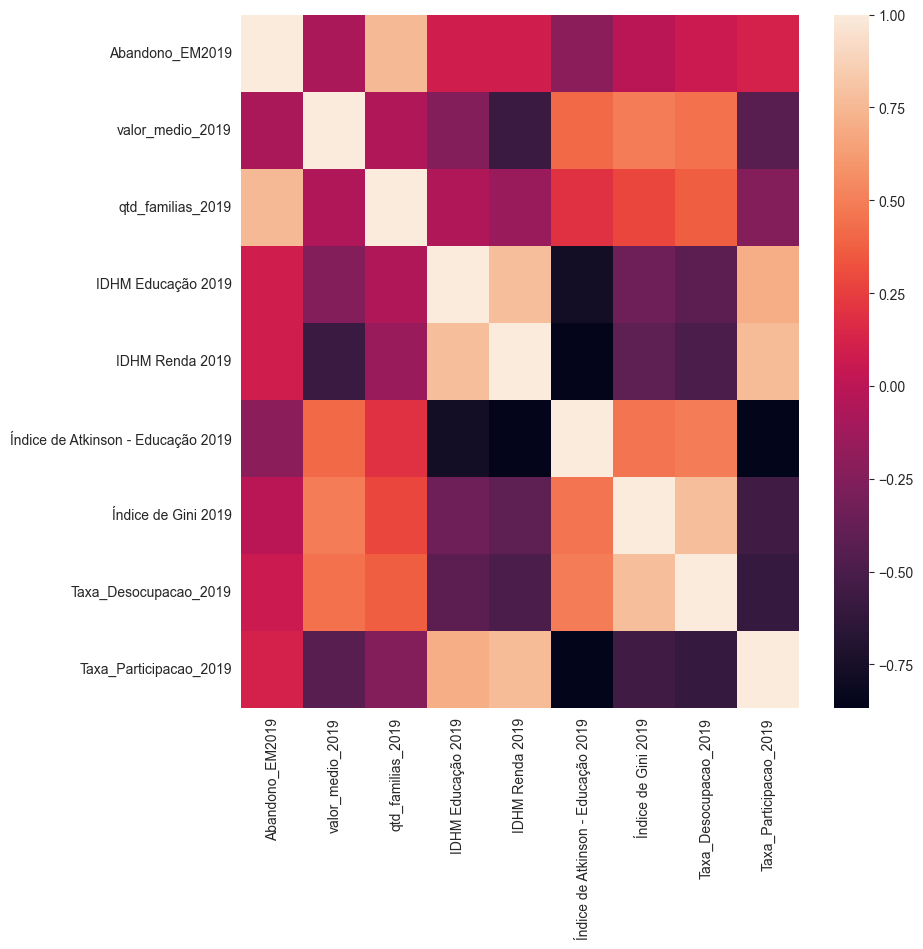

In [55]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2019','valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','IDHM Renda 2019','Índice de Atkinson - Educação 2019','Índice de Gini 2019','Taxa_Desocupacao_2019','Taxa_Participacao_2019']].corr())
plt.show()

In [56]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2020': 'qtd_familias_2020'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2020': 'valor_medio_2020'})

dados_df[['Abandono_EM2020','valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','IDHM Renda 2020','Índice de Atkinson - Educação 2020','Índice de Gini 2020','Taxa_Desocupacao_2020','Taxa_Participacao_2020']].corr()

,Abandono_EM2020,valor_medio_2020,qtd_familias_2020,IDHM Educação 2020,IDHM Renda 2020,Índice de Atkinson - Educação 2020,Índice de Gini 2020,Taxa_Desocupacao_2020,Taxa_Participacao_2020
Abandono_EM2020,1.000000,-0.060957,0.305926,0.152988,0.163215,-0.129112,-0.304893,-0.242535,0.147533
valor_medio_2020,-0.060957,1.000000,-0.195147,-0.104627,-0.405982,0.200525,0.135531,0.175876,-0.183144
qtd_familias_2020,0.305926,-0.195147,1.000000,-0.010274,-0.105055,0.183474,0.345966,0.359957,-0.227947
IDHM Educação 2020,0.152988,-0.104627,-0.010274,1.000000,0.744885,-0.742734,-0.106369,-0.484825,0.692158
IDHM Renda 2020,0.163215,-0.405982,-0.105055,0.744885,1.000000,-0.833877,-0.138308,-0.498663,0.756968
Índice de Atkinson - Educação 2020,-0.129112,0.200525,0.183474,-0.742734,-0.833877,1.000000,0.182575,0.491123,-0.858323
Índice de Gini 2020,-0.304893,0.135531,0.345966,-0.106369,-0.138308,0.182575,1.000000,0.751773,-0.365205
Taxa_Desocupacao_2020,-0.242535,0.175876,0.359957,-0.484825,-0.498663,0.491123,0.751773,1.000000,-0.598578
Taxa_Participacao_2020,0.147533,-0.183144,-0.227947,0.692158,0.756968,-0.858323,-0.365205,-0.598578,1.000000


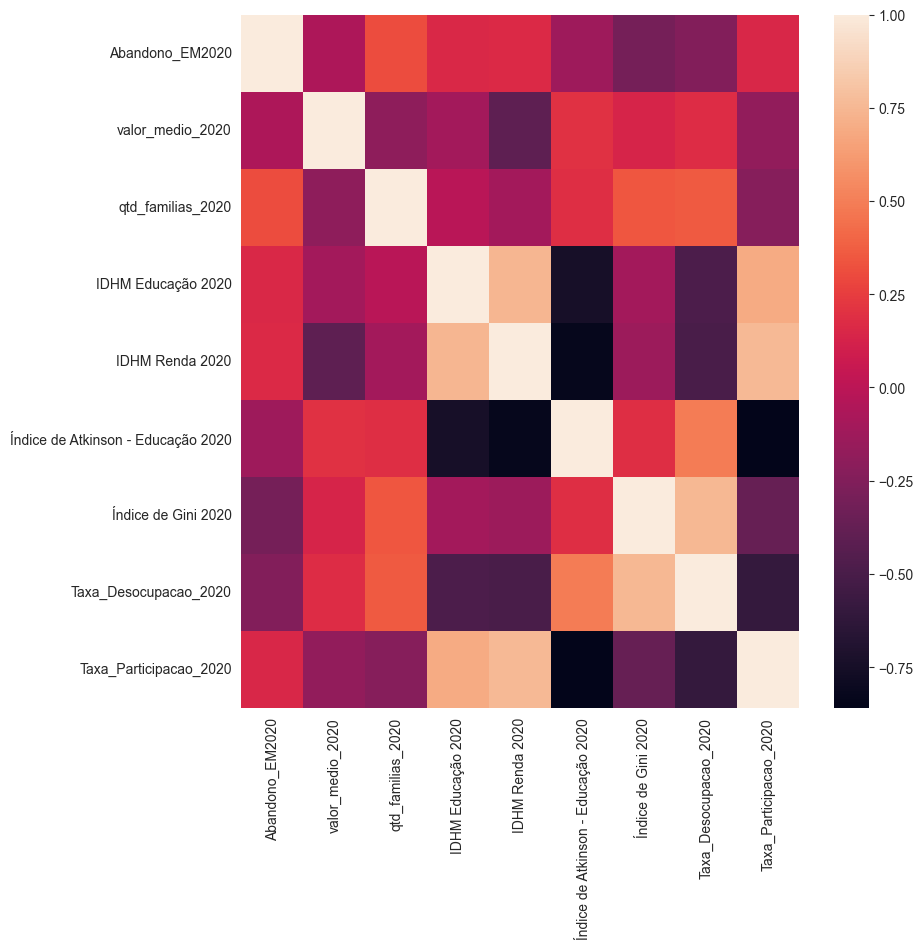

In [57]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2020','valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','IDHM Renda 2020','Índice de Atkinson - Educação 2020','Índice de Gini 2020','Taxa_Desocupacao_2020','Taxa_Participacao_2020']].corr())
plt.show()

In [58]:
dados_df = dados_df.rename(columns={'qtd_familias_beneficiarias_bolsa_familia_ajustado_2021': 'qtd_familias_2021'})
dados_df = dados_df.rename(columns={'valor_medio_bf_ajustado_2021': 'valor_medio_2021'})

dados_df[['Abandono_EM2021','valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','IDHM Renda 2021','Índice de Atkinson - Educação 2021','Índice de Gini 2021','Taxa_Desocupacao_2021','Taxa_Participacao_2021']].corr()

,Abandono_EM2021,valor_medio_2021,qtd_familias_2021,IDHM Educação 2021,IDHM Renda 2021,Índice de Atkinson - Educação 2021,Índice de Gini 2021,Taxa_Desocupacao_2021,Taxa_Participacao_2021
Abandono_EM2021,1.000000,-0.071626,0.724861,0.021418,0.008634,-0.047416,-0.016663,0.106660,0.070482
valor_medio_2021,-0.071626,1.000000,-0.165351,-0.343736,-0.367424,0.193753,0.259657,0.244356,-0.245624
qtd_familias_2021,0.724861,-0.165351,1.000000,0.119890,-0.132052,0.167585,0.247928,0.345878,-0.206624
IDHM Educação 2021,0.021418,-0.343736,0.119890,1.000000,0.781416,-0.638550,-0.381811,-0.519511,0.583346
IDHM Renda 2021,0.008634,-0.367424,-0.132052,0.781416,1.000000,-0.840578,-0.312947,-0.515416,0.750368
Índice de Atkinson - Educação 2021,-0.047416,0.193753,0.167585,-0.638550,-0.840578,1.000000,0.289435,0.417990,-0.814329
Índice de Gini 2021,-0.016663,0.259657,0.247928,-0.381811,-0.312947,0.289435,1.000000,0.779616,-0.500350
Taxa_Desocupacao_2021,0.106660,0.244356,0.345878,-0.519511,-0.515416,0.417990,0.779616,1.000000,-0.598578
Taxa_Participacao_2021,0.070482,-0.245624,-0.206624,0.583346,0.750368,-0.814329,-0.500350,-0.598578,1.000000


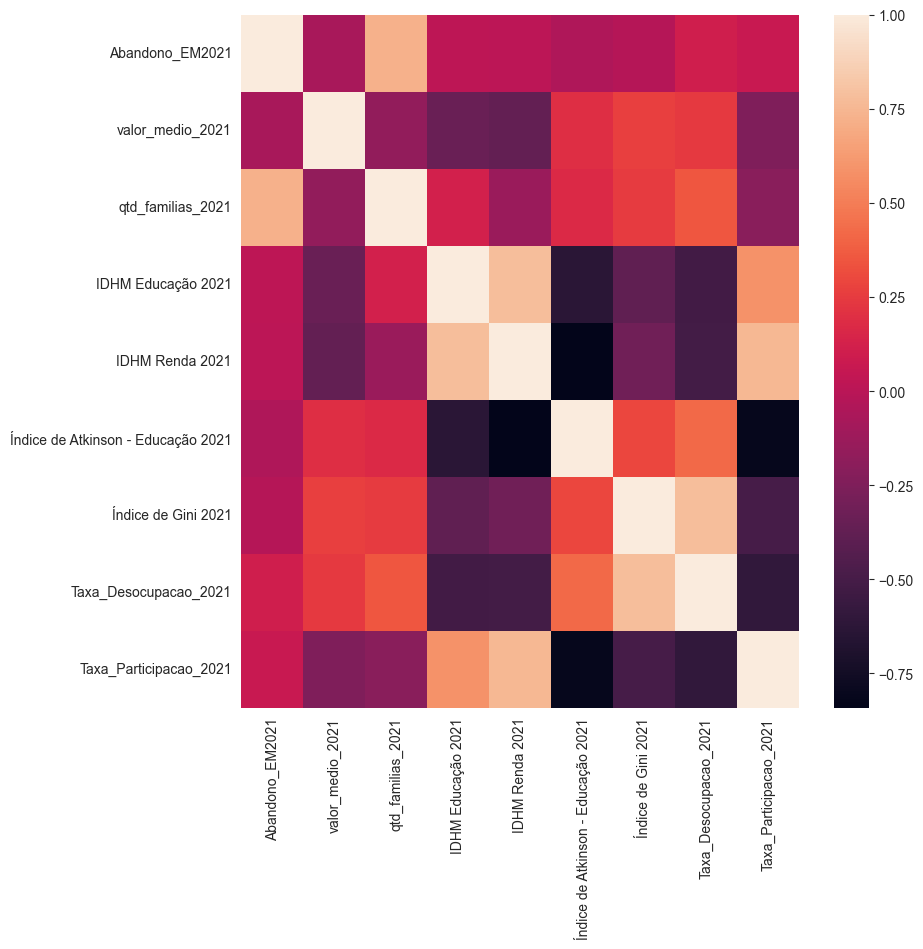

In [59]:

plt.figure(figsize=(9,9))
sns.heatmap(dados_df[['Abandono_EM2021','valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','IDHM Renda 2021','Índice de Atkinson - Educação 2021','Índice de Gini 2021','Taxa_Desocupacao_2021','Taxa_Participacao_2021']].corr())
plt.show()

## plotando graficos de disperção

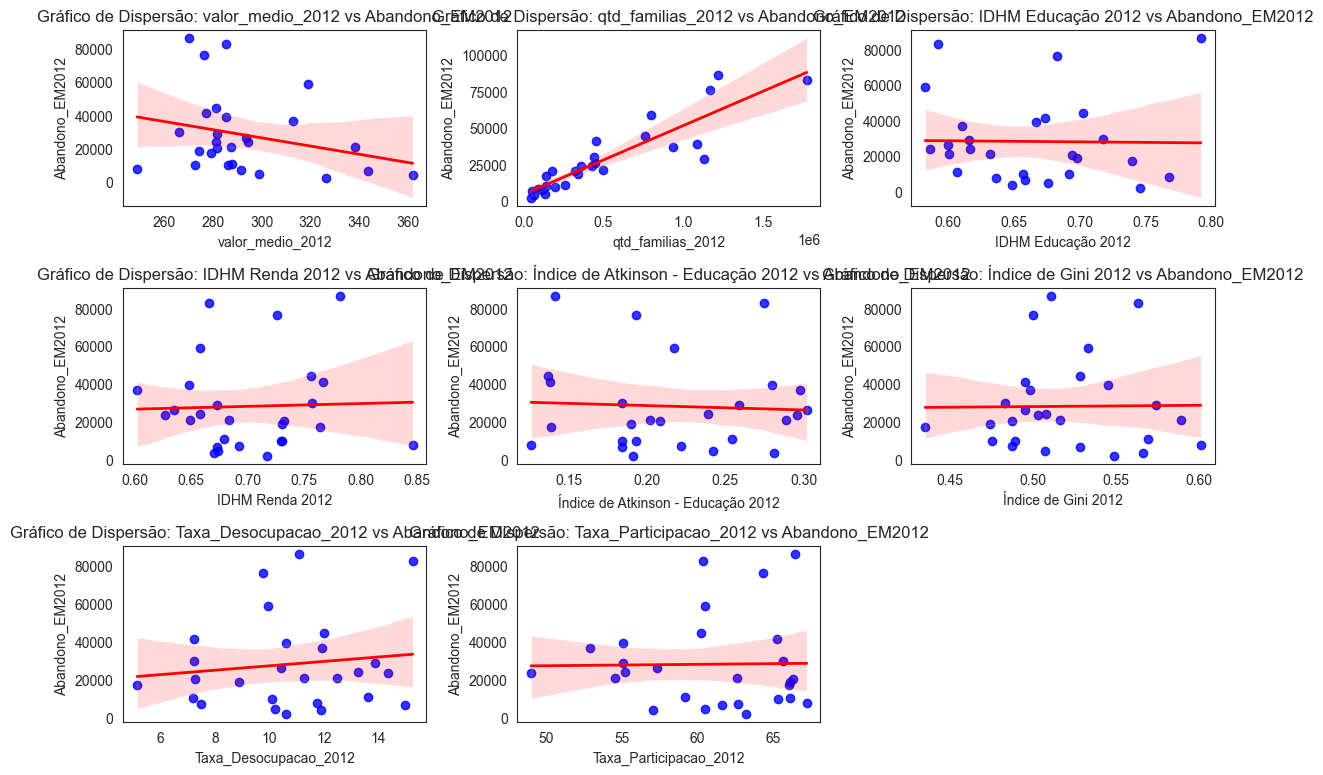

In [61]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2012','qtd_familias_2012','IDHM Educação 2012','IDHM Renda 2012','Índice de Atkinson - Educação 2012','Índice de Gini 2012','Taxa_Desocupacao_2012','Taxa_Participacao_2012']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2012", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2012')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2012')


plt.tight_layout()
plt.show()


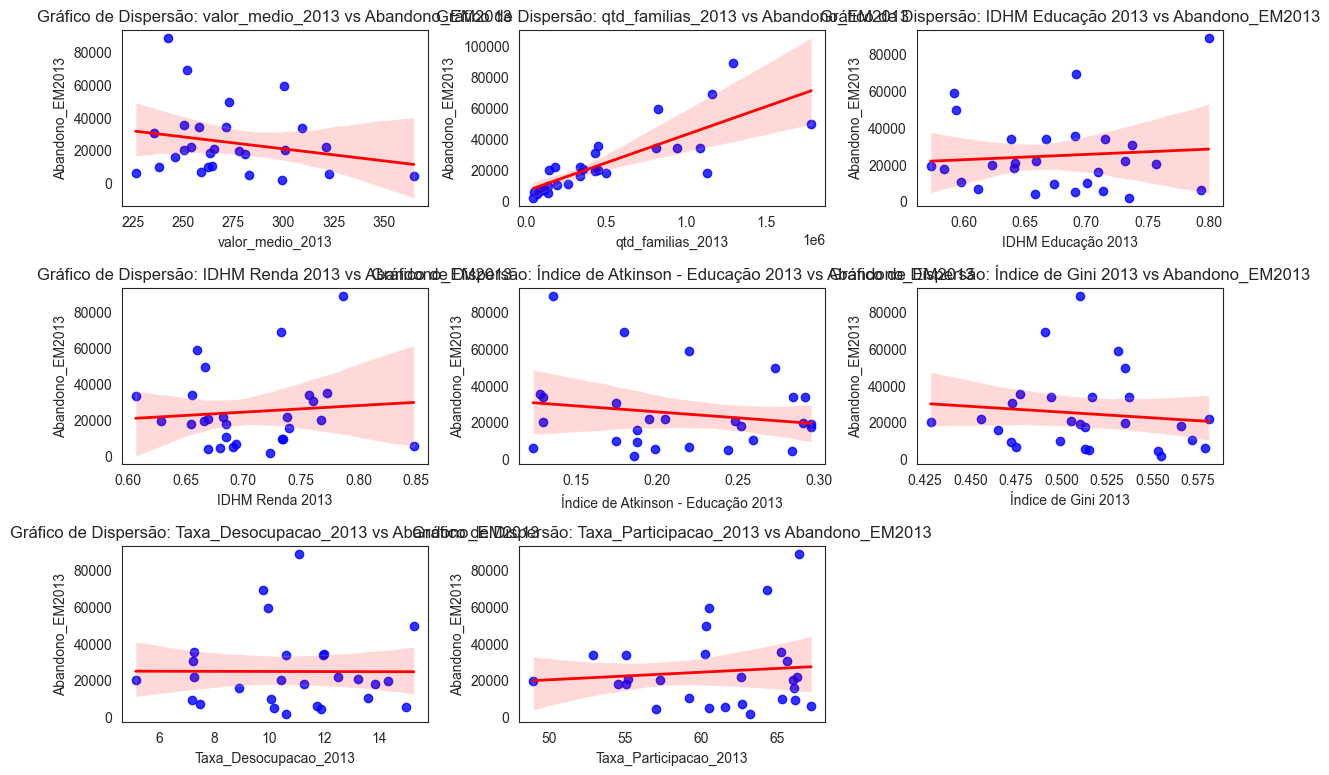

In [62]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2013','qtd_familias_2013','IDHM Educação 2013','IDHM Renda 2013','Índice de Atkinson - Educação 2013','Índice de Gini 2013','Taxa_Desocupacao_2013','Taxa_Participacao_2013']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2013", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2013')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2013')


plt.tight_layout()
plt.show()


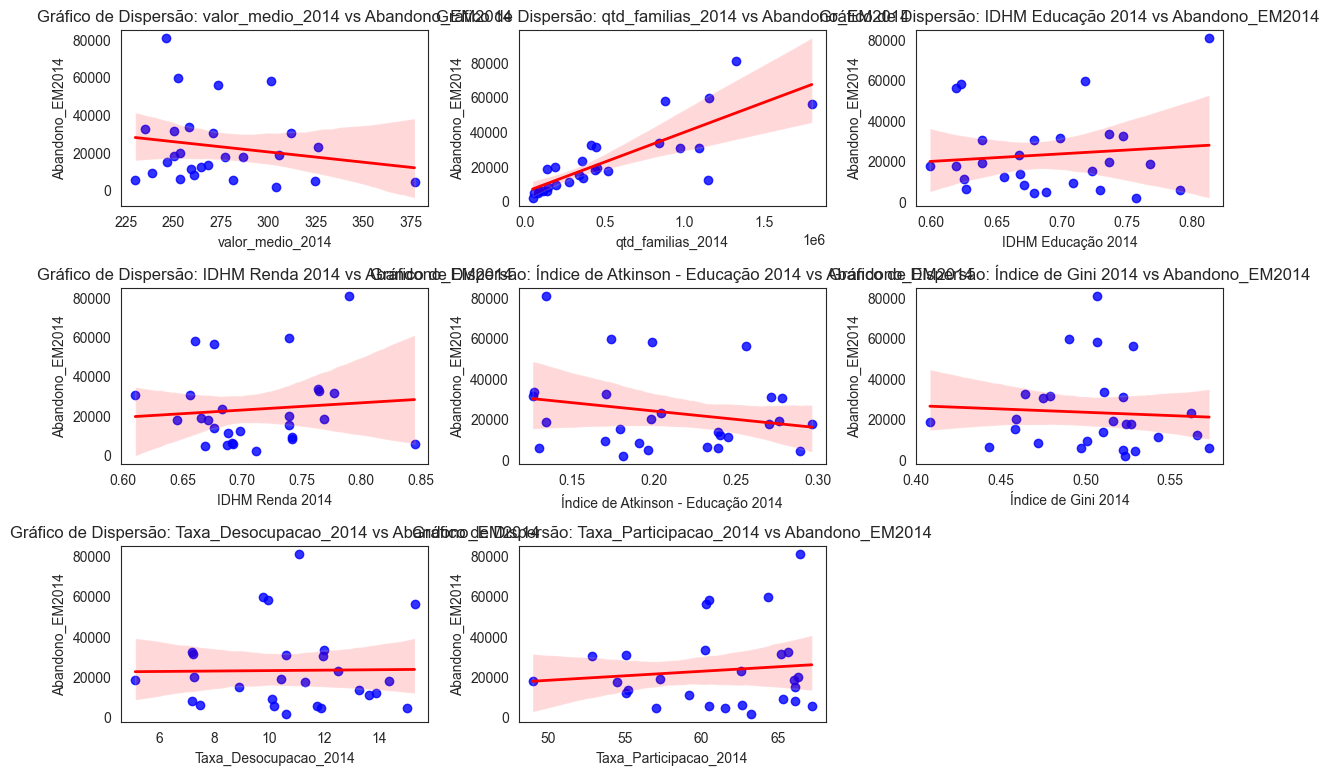

In [63]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2014','qtd_familias_2014','IDHM Educação 2014','IDHM Renda 2014','Índice de Atkinson - Educação 2014','Índice de Gini 2014','Taxa_Desocupacao_2014','Taxa_Participacao_2014']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2014", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2014')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2014')


plt.tight_layout()
plt.show()


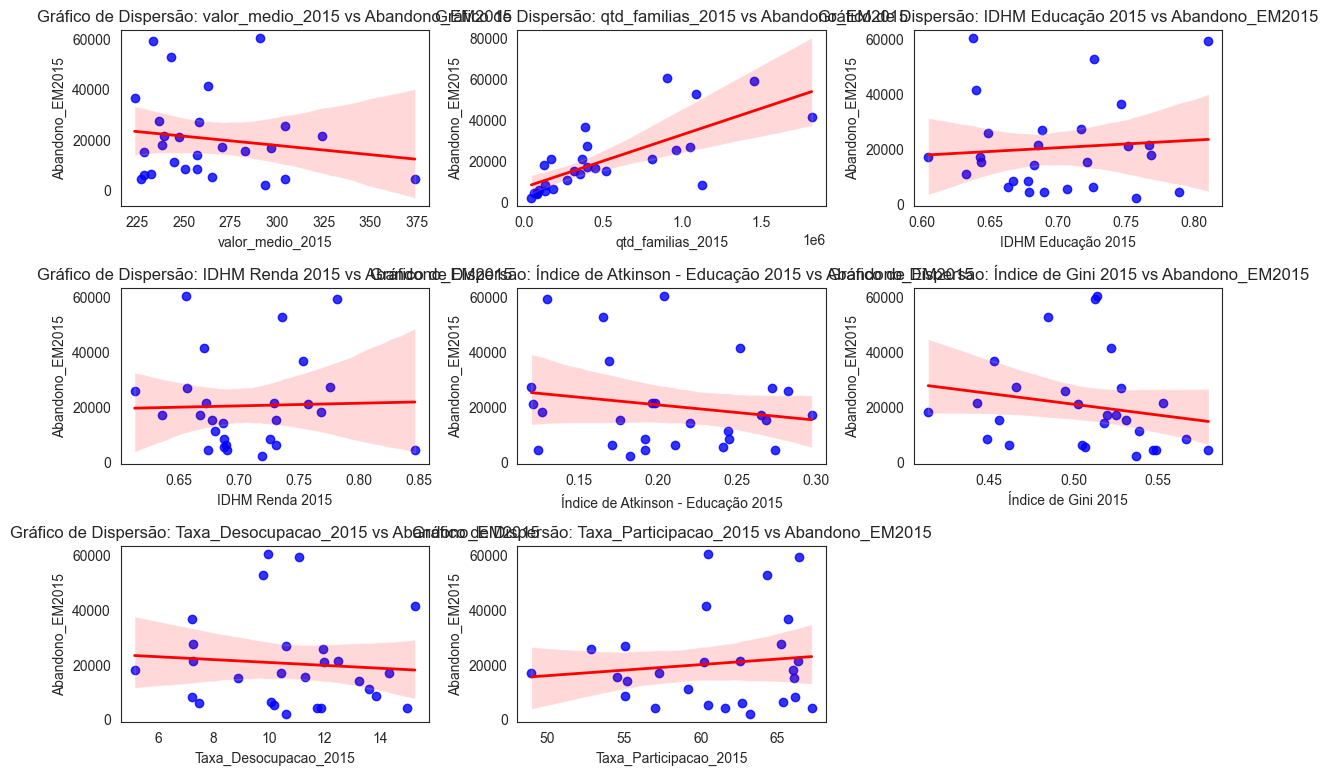

In [64]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2015','qtd_familias_2015','IDHM Educação 2015','IDHM Renda 2015','Índice de Atkinson - Educação 2015','Índice de Gini 2015','Taxa_Desocupacao_2015','Taxa_Participacao_2015']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2015", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2015')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2015')


plt.tight_layout()
plt.show()


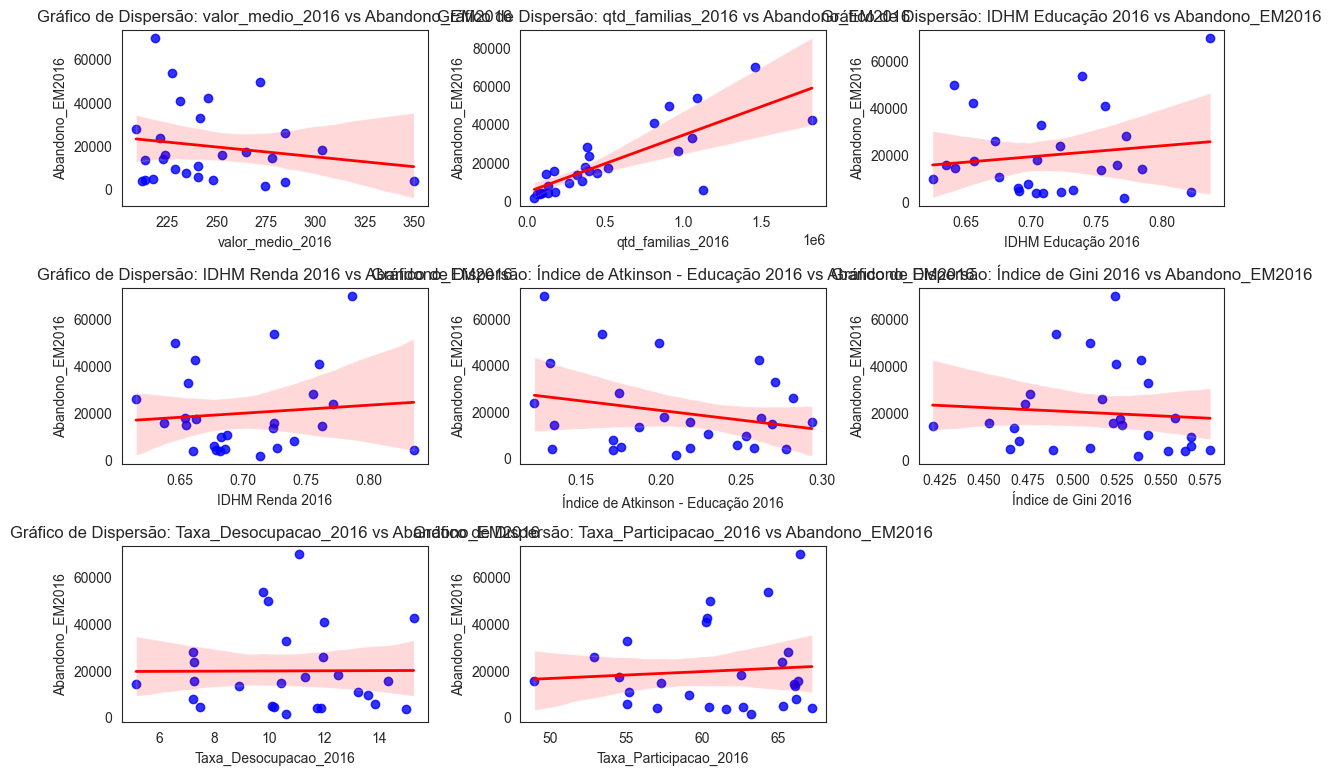

In [65]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2016','qtd_familias_2016','IDHM Educação 2016','IDHM Renda 2016','Índice de Atkinson - Educação 2016','Índice de Gini 2016','Taxa_Desocupacao_2016','Taxa_Participacao_2016']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2016", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2016')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2016')


plt.tight_layout()
plt.show()


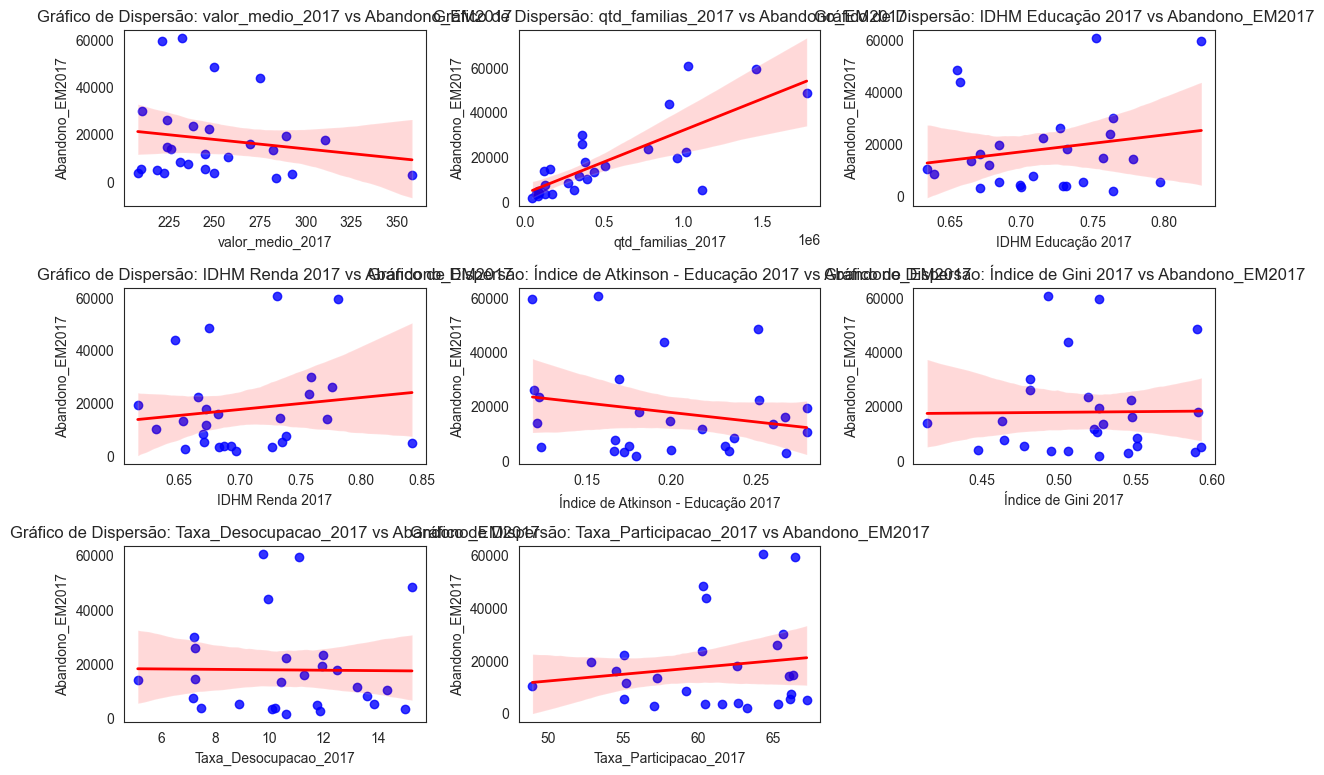

In [66]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2017','qtd_familias_2017','IDHM Educação 2017','IDHM Renda 2017','Índice de Atkinson - Educação 2017','Índice de Gini 2017','Taxa_Desocupacao_2017','Taxa_Participacao_2017']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2017", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2017')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2017')


plt.tight_layout()
plt.show()


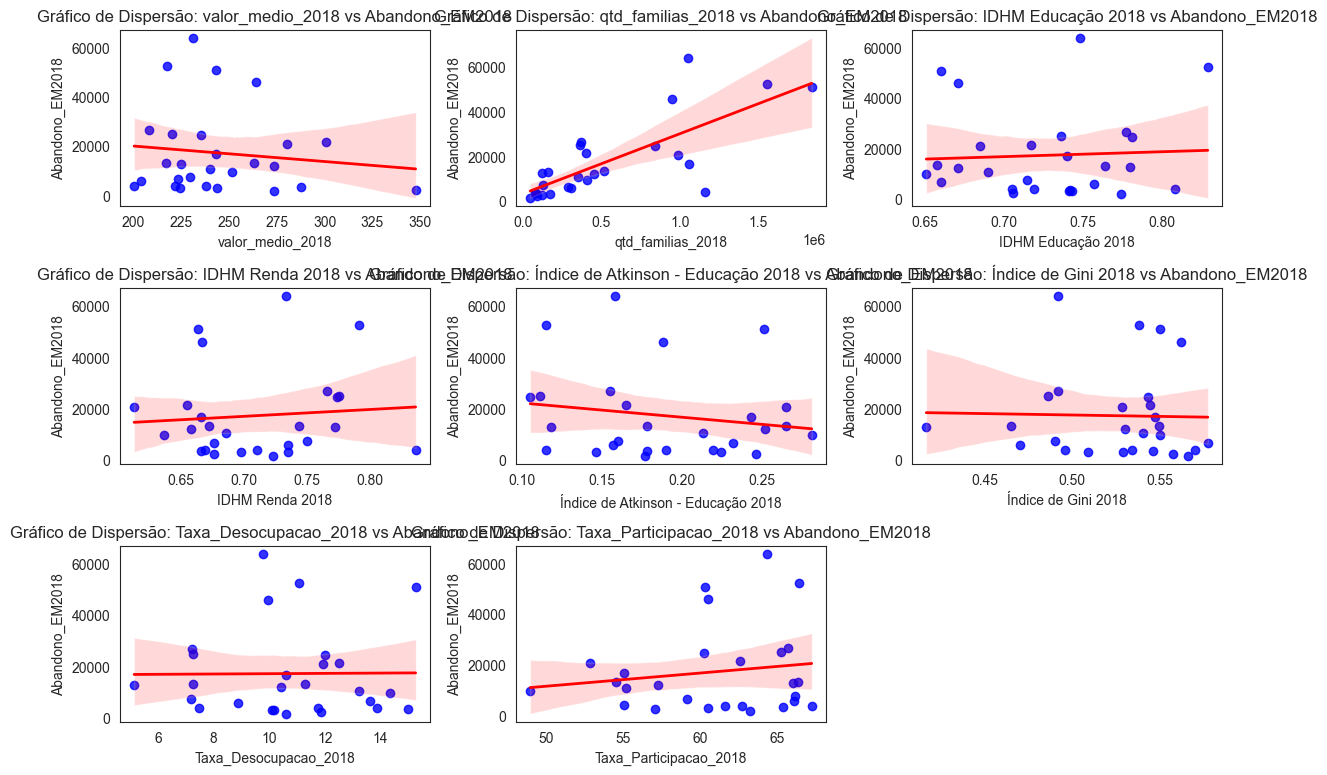

In [67]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2018','qtd_familias_2018','IDHM Educação 2018','IDHM Renda 2018','Índice de Atkinson - Educação 2018','Índice de Gini 2018','Taxa_Desocupacao_2018','Taxa_Participacao_2018']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2018", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2018')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2018')


plt.tight_layout()
plt.show()


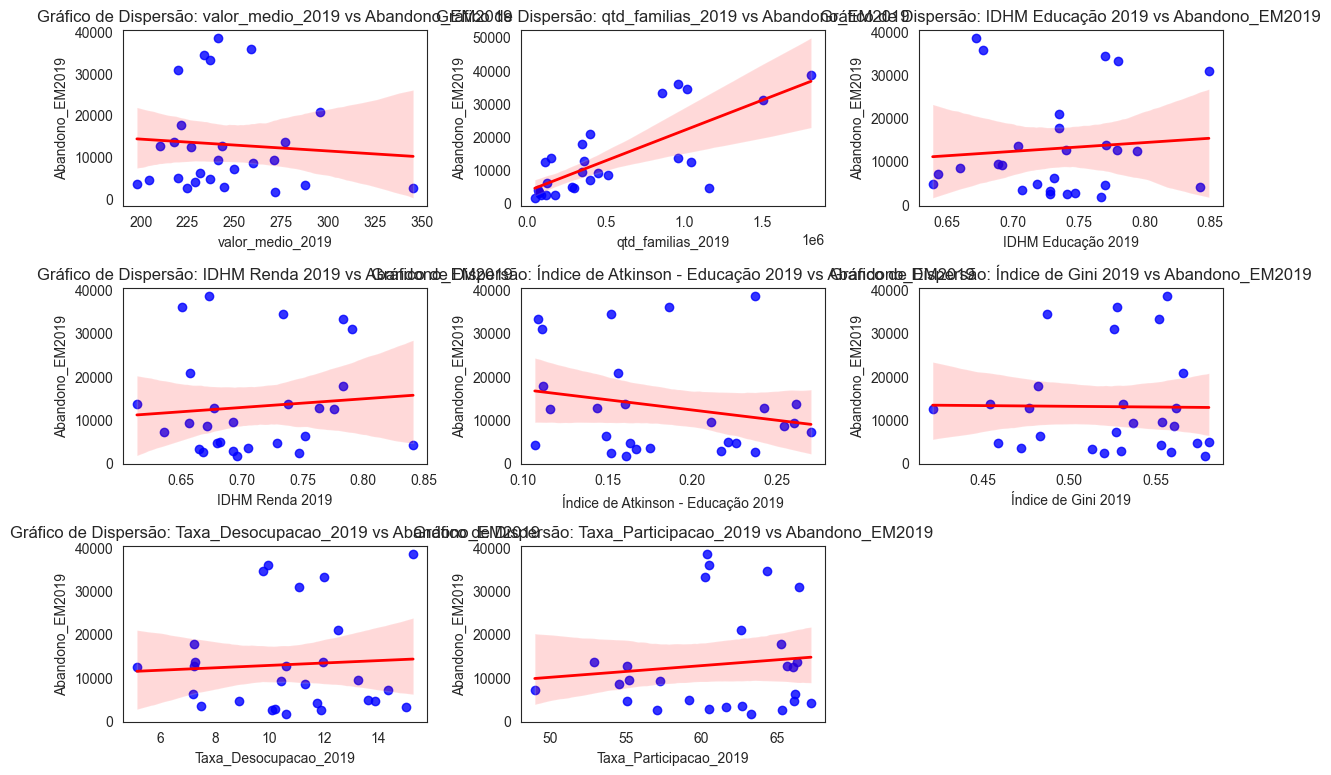

In [68]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2019','qtd_familias_2019','IDHM Educação 2019','IDHM Renda 2019','Índice de Atkinson - Educação 2019','Índice de Gini 2019','Taxa_Desocupacao_2019','Taxa_Participacao_2019']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2019", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2019')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2019')


plt.tight_layout()
plt.show()


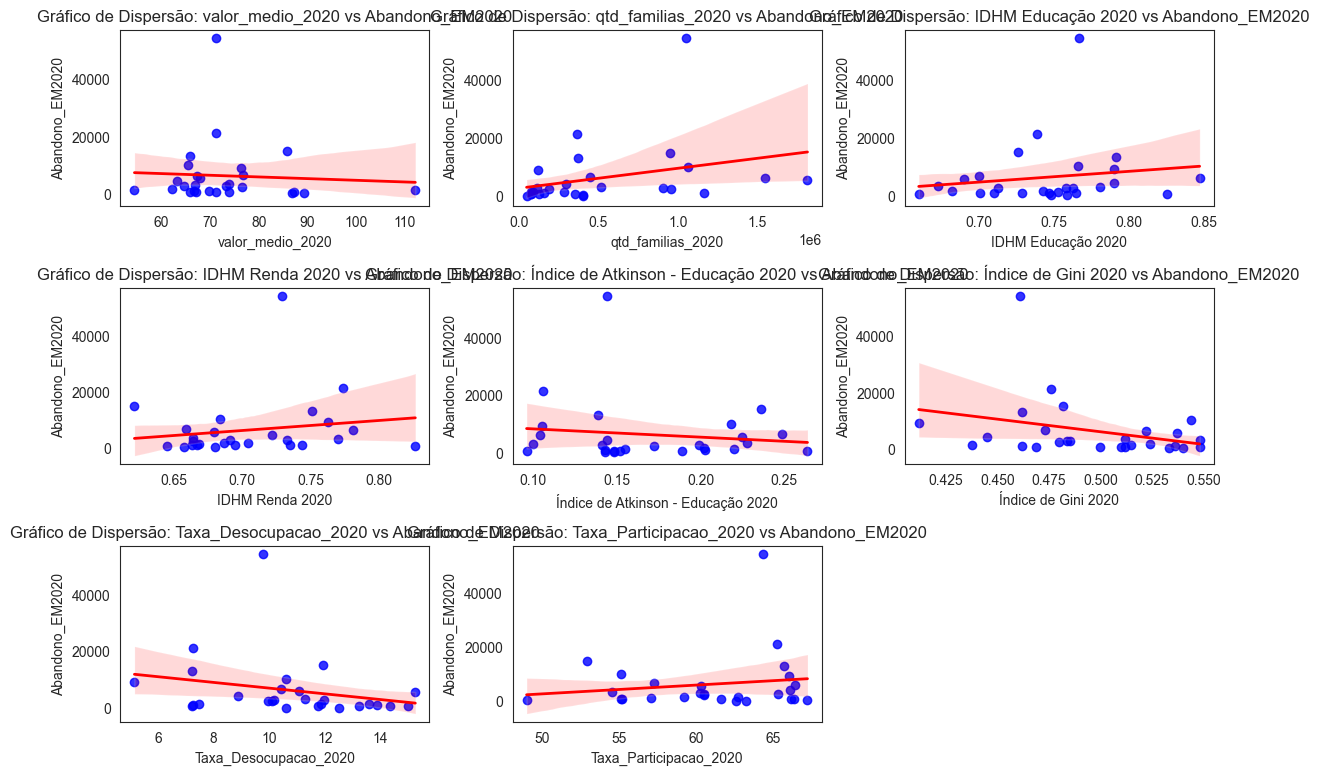

In [69]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2020','qtd_familias_2020','IDHM Educação 2020','IDHM Renda 2020','Índice de Atkinson - Educação 2020','Índice de Gini 2020','Taxa_Desocupacao_2020','Taxa_Participacao_2020']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2020", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2020')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2020')


plt.tight_layout()
plt.show()


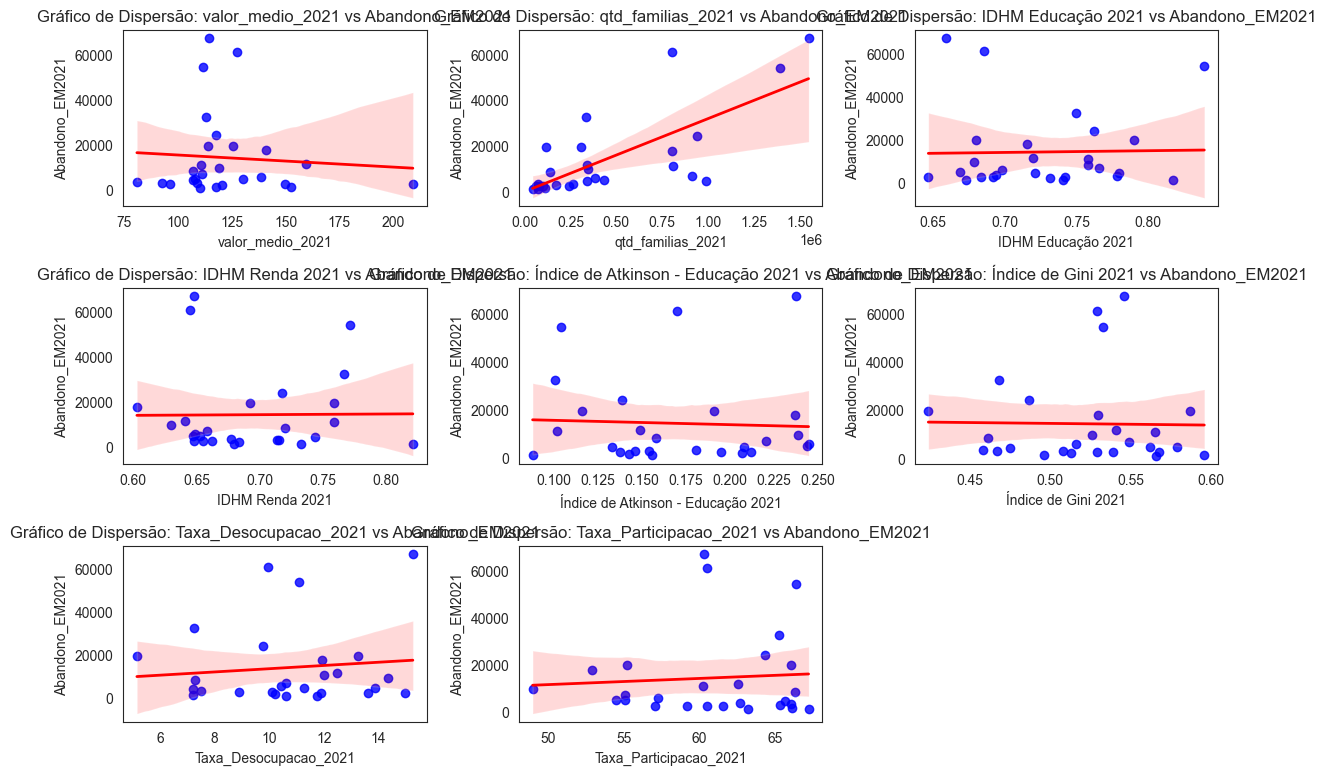

In [70]:


sns.set_style("white")


plt.figure(figsize=(12, 10))


variaveis_x = ['valor_medio_2021','qtd_familias_2021','IDHM Educação 2021','IDHM Renda 2021','Índice de Atkinson - Educação 2021','Índice de Gini 2021','Taxa_Desocupacao_2021','Taxa_Participacao_2021']


for i, var_x in enumerate(variaveis_x, 1):
    plt.subplot(4, 3, i)  
    sns.regplot(x=var_x, y="Abandono_EM2021", data=dados_df, 
                scatter_kws={'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Gráfico de Dispersão: {var_x} vs Abandono_EM2021')
    plt.xlabel(var_x)
    plt.ylabel('Abandono_EM2021')


plt.tight_layout()
plt.show()


### Apos isso foi realizada a regressap linear

In [151]:
print(df_final.columns)

Index(['UF', 'Ano', 'Abandono_EM', 'Valor_medio_BF', 'Abandono_EF',
       'IDHM Educação', 'IDHM Renda', 'Índice de Atkinson Renda',
       'Índice de Atkinson Educacao', 'QTD_FAMILIAS_BF', 'rendaPercapta',
       'IndiceDeGINI', 'Taxa_Desocupacao', 'Nivel_Ocupacao',
       'Taxa_Participacao'],
      dtype='object')


In [ ]:

X = df_final[['Valor_medio_BF', 'IDHM Educação', 'Índice de Atkinson Renda', 'Índice de Atkinson Educacao','Taxa_Desocupacao',
       'Nivel_Ocupacao', 'Taxa_Participacao',
       'QTD_FAMILIAS_BF']]  
X = sm.add_constant(X) 
y = df_final["Abandono_EM"]  


modelo = sm.OLS(y, X).fit()


print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EM   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                 4.572e+06
Date:                Mon, 21 Apr 2025   Prob (F-statistic):               0.00
Time:                        20:30:38   Log-Likelihood:            -1.8453e+08
No. Observations:            17280000   AIC:                         3.691e+08
Df Residuals:                17279991   BIC:                         3.691e+08
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
X = df_final[['Valor_medio_BF', 'IDHM Educação',
       'IDHM Renda', 'Índice de Atkinson Educacao','IndiceDeGINI', 'Taxa_Desocupacao','Taxa_Participacao',
       'QTD_FAMILIAS_BF']] 
X = sm.add_constant(X)
y = df_final["Abandono_EF"]  

modelo = sm.OLS(y, X).fit()


print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            Abandono_EF   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                 8.558e+06
Date:                Mon, 21 Apr 2025   Prob (F-statistic):               0.00
Time:                        20:31:00   Log-Likelihood:            -1.8141e+08
No. Observations:            17280000   AIC:                         3.628e+08
Df Residuals:                17279991   BIC:                         3.628e+08
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

Por fim foral plotados os graficos dos valores medios das variaveisusadas na regreção linear 

## Implementando os dados tratados no geobr

(np.float64(-76.24758052684994),
 np.float64(-26.590708254149963),
 np.float64(-35.702230060524194),
 np.float64(7.222987321825162))

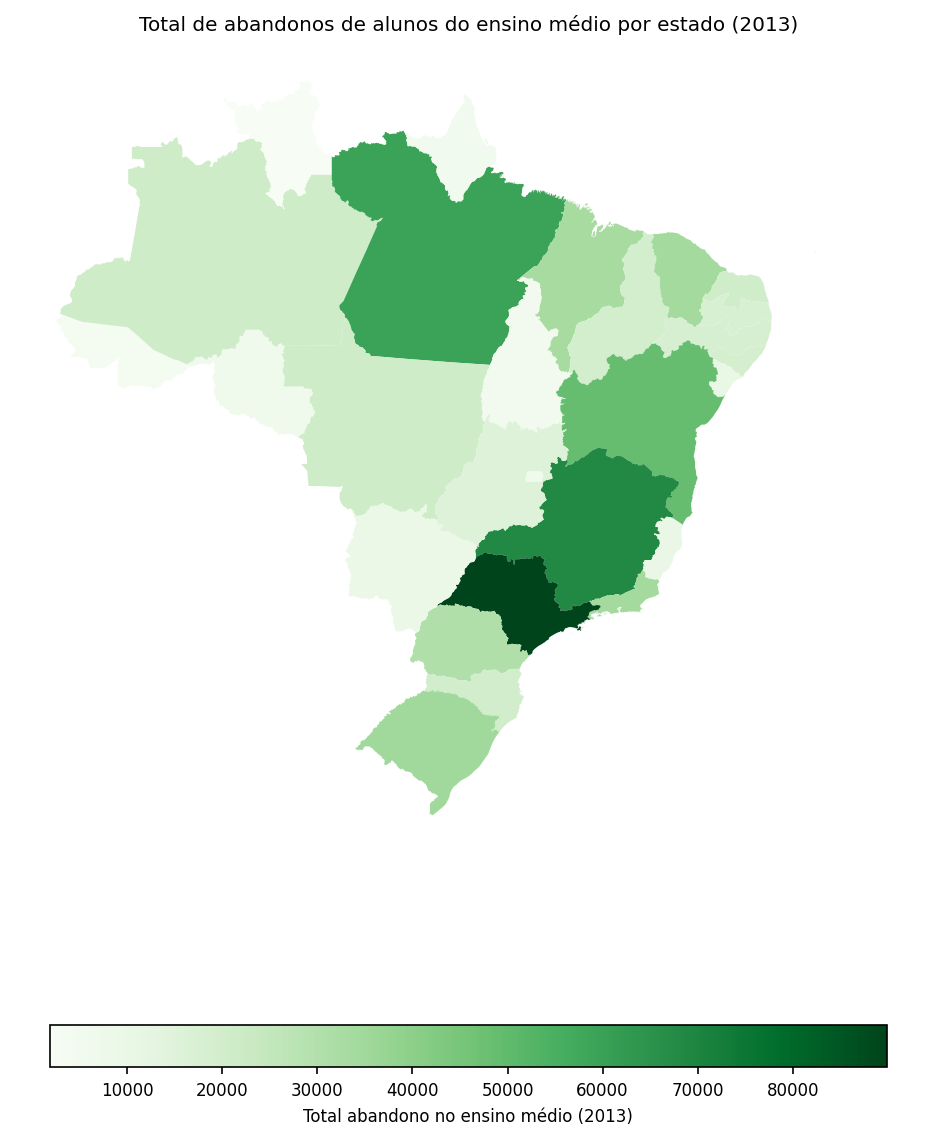

In [ ]:
# 1. Carrega os municípios do Brasil (polígonos)
estados = geobr.read_state(year=2023)  # Dados geoespaciais dos municípios


# 2. Carrega os dados de matrículas por município
df_muni = pd.read_csv("total_abandono_alunos_estados/Estados2015.csv")

# 3. Padroniza colunas para merge (código IBGE do município)
df_muni["estado"] = df_muni["UF"].str.lower() 
estados["sigla"] = estados["abbrev_state"].str.lower() 


# 4. Merge dos dados geoespaciais com as matrículas
estados = estados.merge(df_muni, left_on="sigla", right_on="estado", how="left")


# 6. Configuração do mapa
plt.rcParams.update({"font.size": 8})
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)


# 7. Plot dos municípios (cor por total de matrículas)
estados.plot(
    column="Resultado_Multiplicacao_EM2015",
    cmap="Greens",
    legend=True,
    legend_kwds={
        "label": "Total abandono no ensino médio (2015)",
        "orientation": "horizontal",
        "shrink": 0.6,
    },
    ax=ax
)


ax.set_title("Total de abandonos de alunos do ensino médio por estado (2015)")
ax.axis("off")

In [154]:
df = pd.read_csv("analise_robustaFINAL.csv")

In [ ]:
colunas_anos = ['IDHM Educação 2012','IDHM Educação 2013', 'IDHM Educação 2014', 'IDHM Educação 2015', 
                'IDHM Educação 2016', 'IDHM Educação 2017', 'IDHM Educação 2018', 
                'IDHM Educação 2019', 'IDHM Educação 2020', 'IDHM Educação 2021']

df['IDHM Educação média'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)

df_media = df.groupby('UF')['IDHM Educação média'].mean()
df_media.head()

UF
AC    0.6919
AL    0.6266
AM    0.7001
AP    0.6978
BA    0.6438
Name: IDHM Educação média, dtype: float64

In [ ]:
colunas_anos = ['qtd_familias_beneficiarias_bolsa_familia_ajustado_2012','qtd_familias_beneficiarias_bolsa_familia_ajustado_2013','qtd_familias_beneficiarias_bolsa_familia_ajustado_2014','qtd_familias_beneficiarias_bolsa_familia_ajustado_2015','qtd_familias_beneficiarias_bolsa_familia_ajustado_2016','qtd_familias_beneficiarias_bolsa_familia_ajustado_2017','qtd_familias_beneficiarias_bolsa_familia_ajustado_2018','qtd_familias_beneficiarias_bolsa_familia_ajustado_2019','qtd_familias_beneficiarias_bolsa_familia_ajustado_2020','qtd_familias_beneficiarias_bolsa_familia_ajustado_2021']

df['QTD_DE_FAMILIAS_média'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)
df_media = df.groupby('UF')['QTD_DE_FAMILIAS_média'].mean()

df_media.head()

UF
AC      81242.6
AL     405017.1
AM     368289.2
AP      64188.6
BA    1780262.6
Name: QTD_DE_FAMILIAS_média, dtype: float64

In [ ]:
colunas_anos = ['valor_medio_bf_ajustado_2012','valor_medio_bf_ajustado_2013','valor_medio_bf_ajustado_2014','valor_medio_bf_ajustado_2015','valor_medio_bf_ajustado_2016','valor_medio_bf_ajustado_2017','valor_medio_bf_ajustado_2018','valor_medio_bf_ajustado_2019','valor_medio_bf_ajustado_2020','valor_medio_bf_ajustado_2021',]

df['VALOR MEDIO REPASSADO'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)

df_media = df.groupby('UF')['VALOR MEDIO REPASSADO'].mean()
df_media.head()

UF
AC    320.068
AL    232.164
AM    276.897
AP    268.484
BA    225.683
Name: VALOR MEDIO REPASSADO, dtype: float64

In [ ]:
colunas_anos = ["Abandono_EM2012","Abandono_EM2013","Abandono_EM2014","Abandono_EM2015","Abandono_EM2016","Abandono_EM2017","Abandono_EM2018","Abandono_EM2019","Abandono_EM2020","Abandono_EM2021","Abandono_EM2022","Abandono_EM2023"]

df['Abandono_EM'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)
df_media = df.groupby('UF')['Abandono_EM'].mean()

df_media.head()

UF
AC     3181.166667
AL    11914.333333
AM    16742.833333
AP     3521.000000
BA    47922.166667
Name: Abandono_EM, dtype: float64

In [ ]:

colunas_anos = ["Abandono_EF2012","Abandono_EF2013","Abandono_EF2014","Abandono_EF2015","Abandono_EF2016","Abandono_EF2017","Abandono_EF2018","Abandono_EF2019","Abandono_EF2020","Abandono_EF2021","Abandono_EF2022","Abandono_EF2023"]

df['Abandono_EF'] = df[colunas_anos].sum(axis=1) / len(colunas_anos)

df_media = df.groupby('UF')['Abandono_EF'].mean()
df_media.head()

UF
AC     3927.500000
AL    18291.250000
AM    22647.666667
AP     3251.916667
BA    73556.833333
Name: Abandono_EF, dtype: float64

In [ ]:
import geopandas as gpd
gdf_estados = gpd.read_file("sheap")

print(gdf_estados.head())

  CD_UF     NM_UF SIGLA_UF CD_REGIAO NM_REGIAO     AREA_KM2  \
0    11  Rondônia       RO         1     Norte   237754.171   
1    12      Acre       AC         1     Norte   164173.525   
2    13  Amazonas       AM         1     Norte  1559256.365   
3    14   Roraima       RR         1     Norte   223644.534   
4    15      Pará       PA         1     Norte  1245870.242   

                                            geometry  
0  POLYGON ((-63.56494 -12.50309, -63.56925 -12.5...  
1  POLYGON ((-69.42369 -10.92668, -69.42421 -10.9...  
2  POLYGON ((-67.51732 -9.56071, -67.51776 -9.560...  
3  POLYGON ((-60.04183 0.25298, -60.04683 0.23213...  
4  MULTIPOLYGON (((-51.48817 -9.76058, -51.72427 ...  


In [ ]:
gdf_merge = gdf_estados.merge(df_media, left_on='SIGLA_UF', right_index=True)
print(gdf_merge.head())

  CD_UF     NM_UF SIGLA_UF CD_REGIAO NM_REGIAO     AREA_KM2  \
0    11  Rondônia       RO         1     Norte   237754.171   
1    12      Acre       AC         1     Norte   164173.525   
2    13  Amazonas       AM         1     Norte  1559256.365   
3    14   Roraima       RR         1     Norte   223644.534   
4    15      Pará       PA         1     Norte  1245870.242   

                                            geometry   Abandono_EF  
0  POLYGON ((-63.56494 -12.50309, -63.56925 -12.5...   4581.166667  
1  POLYGON ((-69.42369 -10.92668, -69.42421 -10.9...   3927.500000  
2  POLYGON ((-67.51732 -9.56071, -67.51776 -9.560...  22647.666667  
3  POLYGON ((-60.04183 0.25298, -60.04683 0.23213...   1988.500000  
4  MULTIPOLYGON (((-51.48817 -9.76058, -51.72427 ...  50751.833333  


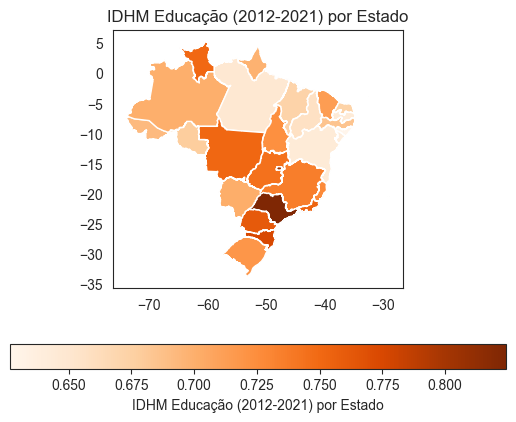

In [ ]:


gdf_merge.plot(column='IDHM Educação média', 
               cmap='Oranges',  
               legend=True, 
               legend_kwds={'label': "IDHM Educação (2012-2021) por Estado", 'orientation': "horizontal"})

plt.title("IDHM Educação (2012-2021) por Estado")
plt.show()

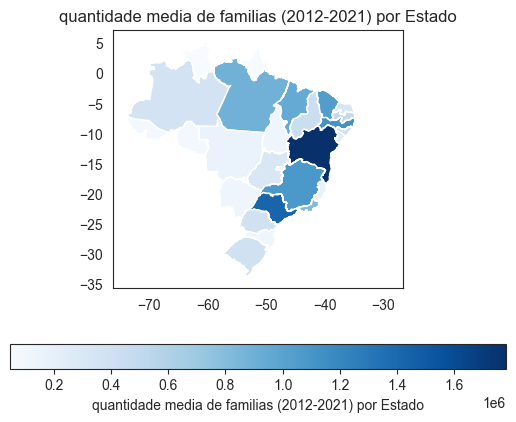

In [ ]:
gdf_merge.plot(column='QTD_DE_FAMILIAS_média', 
               cmap='Blues',  
               legend=True, 
               legend_kwds={'label': "quantidade media de familias (2012-2021) por Estado", 'orientation': "horizontal"})


plt.title("quantidade media de familias (2012-2021) por Estado")
plt.show()

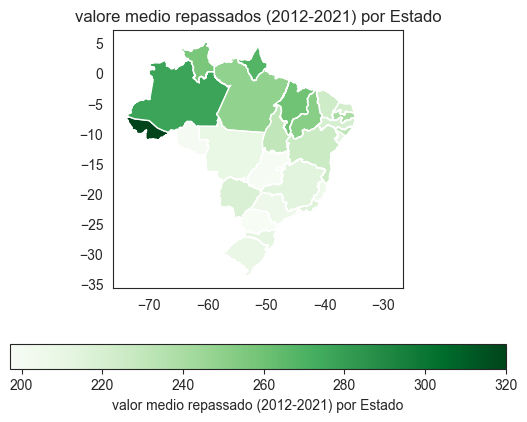

In [ ]:
gdf_merge.plot(column='VALOR MEDIO REPASSADO', 
               cmap='Greens',
               legend=True, 
               legend_kwds={'label': "valor medio repassado (2012-2021) por Estado", 'orientation': "horizontal"})

plt.title("valore medio repassados (2012-2021) por Estado")
plt.show()

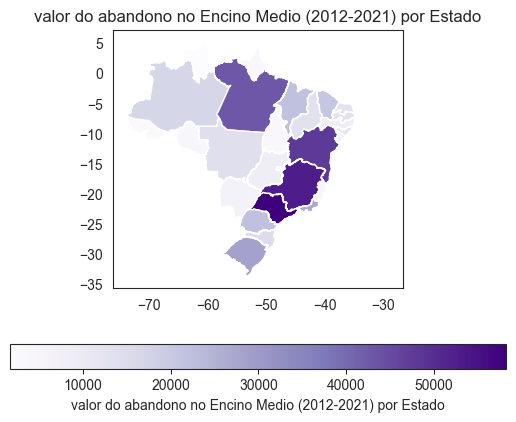

In [ ]:
gdf_merge.plot(column='Abandono_EM', 
               cmap='Purples', 
               legend=True, 
               legend_kwds={'label': "valor do abandono no Encino Medio (2012-2021) por Estado", 'orientation': "horizontal"})


plt.title("valor do abandono no Encino Medio (2012-2021) por Estado")
plt.show()

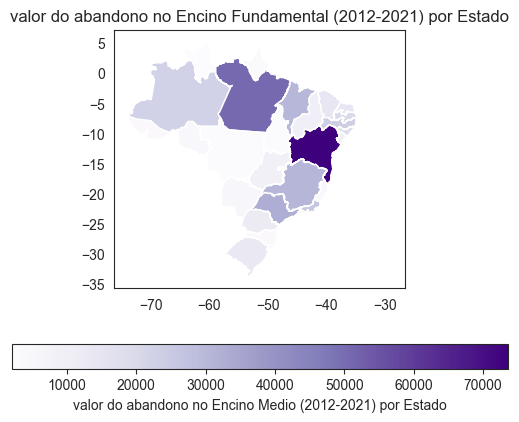

In [ ]:

gdf_merge.plot(column='Abandono_EF', 
               cmap='Purples', 
               legend=True, 
               legend_kwds={'label': "valor do abandono no Encino Medio (2012-2021) por Estado", 'orientation': "horizontal"})


plt.title("valor do abandono no Encino Fundamental (2012-2021) por Estado")
plt.show()